In [1]:
!wget https://datasets.d2.mpi-inf.mpg.de/MPIIGaze/MPIIGaze.tar.gz
!tar xvzf MPIIGaze.tar.gz MPIIGaze

"wget" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
tar: Error opening archive: Failed to open 'MPIIGaze.tar.gz'


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhruv413/mpiigaze")

print("Path to dataset files:", path)

c:\Users\Matvey\pyproj\EyeTracker\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.08G/2.08G [03:33<00:00, 10.4MB/s]

Extracting files...


Path to dataset files: C:\Users\Matvey\.cache\kagglehub\datasets\dhruv413\mpiigaze\versions\1


p03
p08
p06
p10
p00
p11
p04
p13
p09
p01
p05
p07
p02
p14
p12
Epoch 1/300, train loss: 0.21899049216881394, error mean: -0.02027006633579731, error std: 0.07410752028226852
Epoch 1/300, val loss: 0.18312378553673625, error mean: -0.0062840827740728855, error std: 0.072999507188797
Epoch 2/300, train loss: 0.1764469356276095, error mean: -0.0006215585162863135, error std: 0.07150489091873169
Epoch 2/300, val loss: 0.16163956187665462, error mean: 0.003039145842194557, error std: 0.06876953691244125
Epoch 3/300, train loss: 0.14686124841682613, error mean: 0.00022152946621645242, error std: 0.06517225503921509
Epoch 3/300, val loss: 0.12981701781973243, error mean: 0.009225636720657349, error std: 0.061023980379104614
Epoch 4/300, train loss: 0.11041182419285178, error mean: 0.0006815240485593677, error std: 0.05659348890185356
Epoch 4/300, val loss: 0.12486349605023861, error mean: 0.016225334256887436, error std: 0.05824188515543938
Epoch 5/300, train loss: 0.08959859027527273, error mea

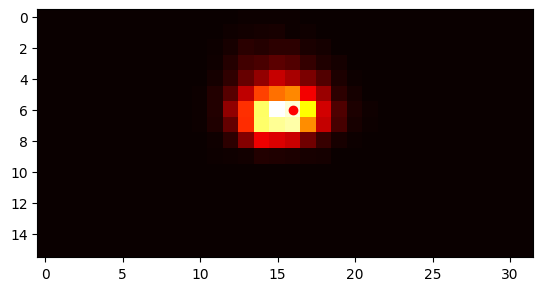

In [2]:
#Подготовка данных и обучение нейросети на картинках глаз отдельных
# импорт библиотек
import os

import numpy as np
import pandas as pd
import scipy
import scipy.io

from PIL import Image
import cv2

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt

database_path = "/content/MPIIGaze"

# функция для загрузки фотографий одного человека
def load_image_data(patient_name):
    global database_path

    annotation_path = os.path.join(database_path, "Annotation Subset", patient_name + ".txt")
    data_folder = os.path.join(database_path, "Data", "Original", patient_name)

    annotation = pd.read_csv(annotation_path, sep=" ", header=None)

    points = np.array(annotation.loc[:, list(range(1, 17))])

    filenames = np.array(annotation.loc[:, [0]]).reshape(-1)
    images = [np.array(Image.open(os.path.join(data_folder, filename))) for filename in filenames]

    return images, points


images, points = load_image_data("p00")
# plt.imshow(images[0])
# colors = ["r", "g", "b", "magenta", "y", "cyan", "brown", "lightcoral"]
# for i in range(0, len(points[0]), 2):
#     x, y = points[0, i:i+2] # вот туть мне удалось понять, что координаты точек хранятся по 2, причем в формате X, Y
#     plt.scatter([x], [y], c=colors[i//2])

# функция расстояния между двумя точками
def distance(x1, y1, x2, y2):
    return int(((x1 - x2) ** 2 + (y1 - y2) ** 2) ** 0.5)

image_shape = (16, 32)

# здесь вырезаем из большой картинки глаз и находим относительное положение зрачка
# это понадобится позже
def handle_eye(image, p1, p2, pupil):
    global image_shape

    line_len = distance(*p1, *p2)
    # x, y -> y, x
    p1 = p1[::-1]
    p2 = p2[::-1]
    pupil = pupil[::-1]

    corner1 = p1 - np.array([line_len//4, 0])
    corner2 = p2 + np.array([line_len//4, 0])

    sub_image = image[corner1[0]:corner2[0]+1, corner1[1]:corner2[1]+1]

    pupil_new = pupil - corner1
    pupil_new = pupil_new / sub_image.shape[:2]

    sub_image = cv2.resize(sub_image, image_shape[::-1], interpolation=cv2.INTER_AREA)
    sub_image = cv2.cvtColor(sub_image, cv2.COLOR_RGB2GRAY)

    return sub_image, pupil_new



def image_to_train_data(image, points):
    eye_right_p1 = points[0:2]
    eye_right_p2 = points[2:4]
    eye_right_pupil = points[12:14]

    right_image, right_pupil = handle_eye(image, eye_right_p1, eye_right_p2, eye_right_pupil)

    eye_left_p1 = points[4:6]
    eye_left_p2 = points[6:8]
    eye_left_pupil = points[14:16]

    left_image, left_pupil = handle_eye(image, eye_left_p1, eye_left_p2, eye_left_pupil)

    return right_image, right_pupil, left_image, left_pupil


# обработаем одну картинку
right_image, right_pupil, left_image, left_pupil = image_to_train_data(images[10], points[10])

plt.imshow(right_image, cmap="gray")

r_p_x = int(right_pupil[1] * image_shape[1])
r_p_y = int(right_pupil[0] * image_shape[0])
plt.scatter([r_p_x], [r_p_y], c="red")



images_left_conc = []
images_right_conc = []
pupils_left_conc = []
pupils_right_conc = []

patients_path = os.path.join(database_path, "Data", "Original")
for patient in os.listdir(patients_path):
    print(patient)
    images, points = load_image_data(patient)
    for i in range(len(images)):
        signle_image_data = image_to_train_data(images[i], points[i])

        if any(stuff is None for stuff in signle_image_data):
            continue

        right_image, right_pupil, left_image, left_pupil = signle_image_data

        if any(right_pupil < 0) or any(left_pupil < 0):
            continue

        images_right_conc.append(right_image)
        images_left_conc.append(left_image)
        pupils_right_conc.append(right_pupil)
        pupils_left_conc.append(left_pupil)

images_left_conc = np.array(images_left_conc)
images_right_conc = np.array(images_right_conc)
pupils_left_conc = np.array(pupils_left_conc)
pupils_right_conc = np.array(pupils_right_conc)


images_left_conc = images_left_conc / 255
images_right_conc = images_right_conc / 255

pupils_conc = np.zeros_like(pupils_left_conc)
for i in range(2):
    pupils_conc[:, i] = (pupils_left_conc[:, i] + pupils_right_conc[:, i]) / 2


viz_pupils = np.zeros(image_shape)
for y, x in pupils_conc:
    y = int(y * image_shape[0])
    x = int(x * image_shape[1])
    viz_pupils[y, x] += 1
max_val = viz_pupils.max()
viz_pupils = viz_pupils / max_val

plt.imshow(viz_pupils, cmap="hot")




# еще несколько вкусных строчек
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import DataLoader, TensorDataset


# функция, разбивающая данные на два датасета -- тренировочный и валидационный
def make_2eyes_datasets(images_left, images_right, pupils, train_size=0.8):
    n, height, width = images_left.shape

    images_left = images_left.reshape(n, 1, height, width)
    images_right = images_right.reshape(n, 1, height, width)

    images_left_train, images_left_val, images_right_train, images_right_val, pupils_train, pupils_val = train_test_split(
        images_left, images_right, pupils, train_size=train_size
    )

    def make_dataset(im_left, im_right, pups):
        return TensorDataset(
            torch.from_numpy(im_left.astype(np.float32)), torch.from_numpy(im_right.astype(np.float32)), torch.from_numpy(pups.astype(np.float32))
        )

    train_dataset = make_dataset(images_left_train, images_right_train, pupils_train)
    val_dataset = make_dataset(images_left_val, images_right_val, pupils_val)

    return train_dataset, val_dataset

# преобразование датасетов в даталоадеры
def make_dataloaders(train_dataset, val_dataset, batch_size=256):
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

    return train_dataloader, val_dataloader


batch_size = 256

eyes_datasets = make_2eyes_datasets(images_left_conc, images_right_conc, pupils_conc)
eyes_train_loader, eyes_val_loader = make_dataloaders(*eyes_datasets, batch_size=batch_size)


import torch
import torch.nn as nn
import torch.nn.functional as F


# модуль, аналогичный `keras.layers.Reshape`
class Reshaper(nn.Module):
    def __init__(self, target_shape):
        super(Reshaper, self).__init__()
        self.target_shape = target_shape

    def forward(self, input):
        return torch.reshape(input, (-1, *self.target_shape))

# сама нейронка
class EyesNet(nn.Module):
    def __init__(self):
        super(EyesNet, self).__init__()

        # два feature-extractor'а с одинаковой архитектурой
        self.features_left = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.features_right = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 2),
            nn.Sigmoid()
        )

    def forward(self, x_left, x_right):
        # прогоняем две картинки через слои фич, конкатенируем и отдаем регрессору
        x_left = self.features_left(x_left)
        x_right = self.features_right(x_right)
        x = torch.cat((x_left, x_right), 1)
        x = self.fc(x)

        return x


# функция обучения нейронки
def train(model, train_loader, test_loader, epochs, lr, folder="gazenet"):
    os.makedirs(folder, exist_ok=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    for epoch in range(epochs):
        running_loss = 0
        error_mean = []
        error_std = []
        for i, (*xs_batch, y_batch) in enumerate(train_loader):
            xs_batch = [x_batch.cuda() for x_batch in xs_batch]
            y_batch = y_batch.cuda()

            optimizer.zero_grad()

            y_batch_pred = model(*xs_batch)
            loss = mse(y_batch_pred, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            difference = (y_batch - y_batch_pred).detach().cpu().numpy().reshape(-1)
            error_mean.append(np.mean(difference))
            error_std.append(np.std(difference))

        error_mean = np.mean(error_mean)
        error_std = np.mean(error_std)

        print(f"Epoch {epoch+1}/{epochs}, train loss: {running_loss}, error mean: {error_mean}, error std: {error_std}")

        running_loss = 0
        error_mean = []
        error_std = []
        for i, (*xs_batch, y_batch) in enumerate(train_loader):
            xs_batch = [x_batch.cuda() for x_batch in xs_batch]
            y_batch = y_batch.cuda()

            y_batch_pred = model(*xs_batch)
            loss = mse(y_batch_pred, y_batch)

            loss.backward()
            running_loss += loss.item()

            difference = (y_batch - y_batch_pred).detach().cpu().numpy().reshape(-1)
            error_mean.append(np.mean(difference))
            error_std.append(np.std(difference))

        error_mean = np.mean(error_mean)
        error_std = np.mean(error_std)

        print(f"Epoch {epoch+1}/{epochs}, val loss: {running_loss}, error mean: {error_mean}, error std: {error_std}")

        epoch_path = os.path.join(folder, f"epoch_{epoch+1}.pth")
        torch.save(model.state_dict(), epoch_path)


eyesnet = EyesNet().cuda()
# полученные веса сохраняются в папку *eyes_net*
train(eyesnet, eyes_train_loader, eyes_val_loader, 300, 1e-3, "eyes_net")


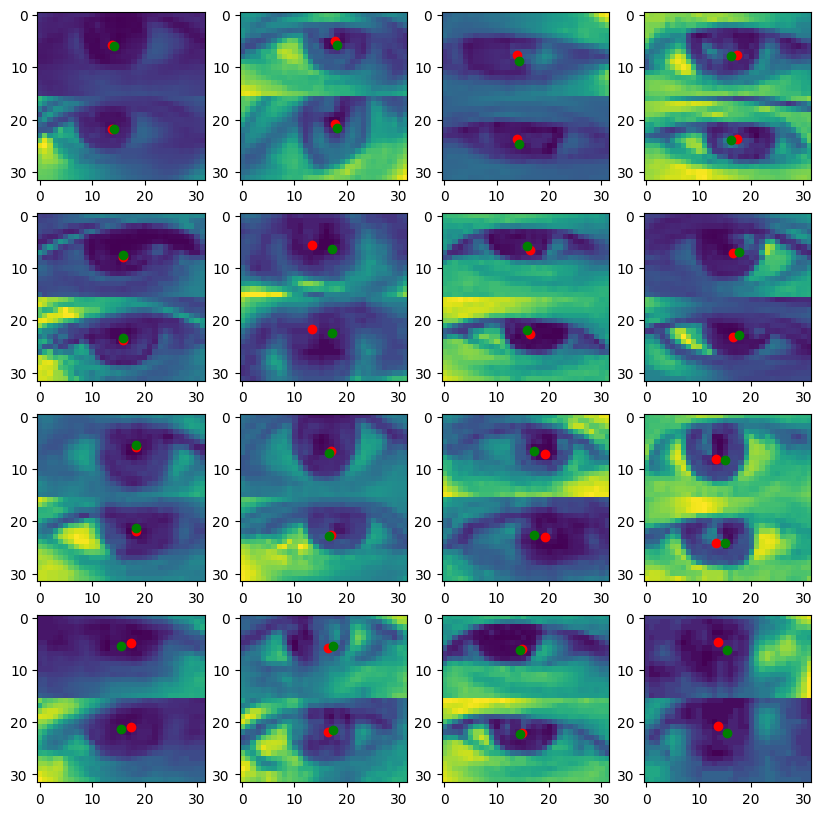

In [3]:
import random

# рисует левый и правый глаз и выставляет реальное и предсказанное положение зрачка
def show_output(model, data_loader, batch_num=0, samples=5, grid_shape=(5, 1), figsize=(10, 10)):
    for i, (*xs, y) in enumerate(data_loader):
        if i == batch_num:
            break
    xs = [x.cuda() for x in xs]
    y_pred = model(*xs).detach().cpu().numpy().reshape(-1, 2)

    xs = [x.detach().cpu().numpy().reshape(-1, 16, 32) for x in xs]
    imgs_conc = np.hstack(xs)
    y = y.cpu().numpy().reshape(-1, 2)

    indices = random.sample(range(len(y_pred)), samples)
    fig, axes = plt.subplots(*grid_shape, figsize=figsize)
    for i, index in enumerate(indices):
        row = i // grid_shape[1]
        column = i % grid_shape[1]

        axes[row, column].imshow(imgs_conc[index])
        axes[row, column].scatter([y_pred[index, 1]*32, y_pred[index, 1]*32], [y_pred[index, 0]*16, (y_pred[index, 0]+1)*16], c="r")
        axes[row, column].scatter([y[index, 1]*32, y[index, 1]*32], [y[index, 0]*16, (y[index, 0]+1)*16], c="g")


# загружаем 299 эпоху
eyesnet.load_state_dict(torch.load("eyes_net/epoch_299.pth"))

show_output(eyesnet, eyes_val_loader, 103, 16, (4, 4))


# def error_distribution(model, data_loader, image_shape=(16, 32), bins=32, digits=2, figsize=(10,10)):
#     ys_true = []
#     ys_pred = []
#     for *xs, y in data_loader:
#         xs = [x.cuda() for x in xs]
#         y_pred = model(*xs)

#         ys_true.append(y.detach().cpu().numpy())
#         ys_pred.append(y_pred.detach().cpu().numpy())
#     ys_true = np.concatenate(ys_true)
#     ys_pred = np.concatenate(ys_pred)
#     indices = np.arange(len(ys_true))

#     fig, axes = plt.subplots(2, figsize=figsize)
#     for ax_num in range(2):
#         ys_true_subset = ys_true[:, ax_num]
#         ys_pred_subset = ys_pred[:, ax_num]
#         counts, ranges = np.histogram(ys_true_subset, bins=bins)

#         errors = []
#         labels = []
#         for i in range(len(counts)):
#             begin, end = ranges[i], ranges[i + 1]
#             range_indices = indices[(ys_true_subset >= begin) & (ys_true_subset <= end)]

#             diffs = np.abs(ys_pred_subset[range_indices] - ys_true_subset[range_indices])
#             label = (begin + end) / 2
#             if image_shape:
#                 diffs = diffs * image_shape[ax_num]
#                 label = label * image_shape[ax_num]
#             else:
#                 label = round(label, digits)
#             errors.append(diffs)
#             labels.append(str(label)[:2+digits])

#         axes[ax_num].boxplot(errors, labels=labels)

#         if image_shape:
#             y_label = "difference, px"
#             x_label = "true position, px"
#         else:
#             y_label = "difference"
#             x_label = "true position"
#         axes[ax_num].set_ylabel(y_label)
#         axes[ax_num].set_xlabel(x_label)

#         if ax_num == 0:
#             title = "Y"
#         else:
#             title = "X"
#         axes[ax_num].set_title(title)


# error_distribution(eyesnet, eyes_val_loader, figsize=(20, 10))


In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/helen-eye-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'helen-eye-dataset' dataset.
Path to dataset files: /kaggle/input/helen-eye-dataset


=== Helen Dataset Structure ===
Main folders: ['train_1', 'annotation', 'train_3', 'train_2', 'train_4']

📁 train_1/:
   Contents: ['train_1']
   📂 train_1/: 500 images, 0 txt files
      Sample images: ['153057847_1.jpg', '194833666_1.jpg', '1425648903_2.jpg']

📁 annotation/:
   Contents: ['annotation']
   📂 annotation/: 0 images, 2330 txt files
      Sample annotations: ['1893.txt', '1711.txt', '1773.txt']

📁 train_3/:
   Contents: ['train_3']
   📂 train_3/: 500 images, 0 txt files
      Sample images: ['2398724830_1.jpg', '2544738096_1.jpg', '2643601988_2.jpg']

📁 train_2/:
   Contents: ['train_2']
   📂 train_2/: 500 images, 0 txt files
      Sample images: ['2165528796_1.jpg', '2076194857_1.jpg', '2312289834_1.jpg']

📁 train_4/:
   Contents: ['train_4']
   📂 train_4/: 500 images, 0 txt files
      Sample images: ['2683325027_1.jpg', '280469983_1.jpg', '2869939639_1.jpg']

=== Checking Annotation Format ===
Checking: /kaggle/input/helen-eye-dataset/annotation
Checking: /kaggle/input

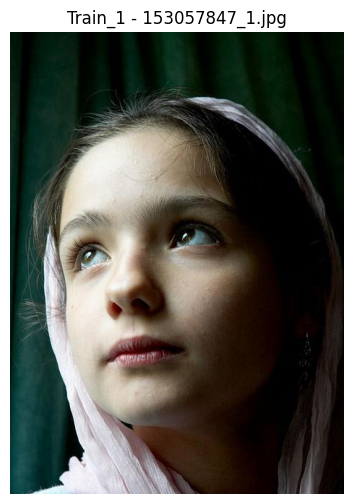


Train_2:
  train_2/: 500 images
    Sample image: 2165528796_1.jpg - Size: (904, 798)


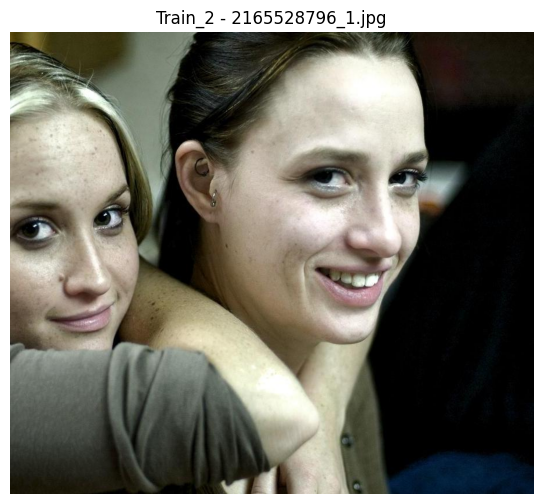


Train_3:
  train_3/: 500 images
    Sample image: 2398724830_1.jpg - Size: (1852, 2035)


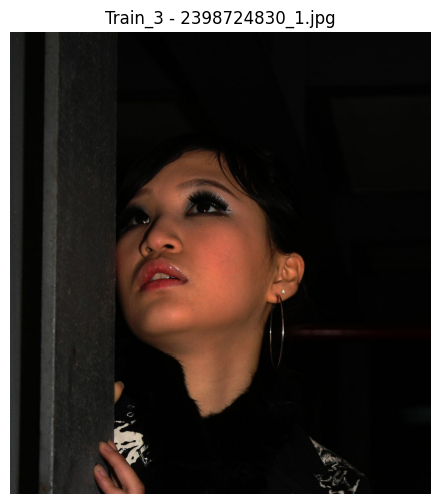


Train_4:
  train_4/: 500 images
    Sample image: 2683325027_1.jpg - Size: (2000, 1330)


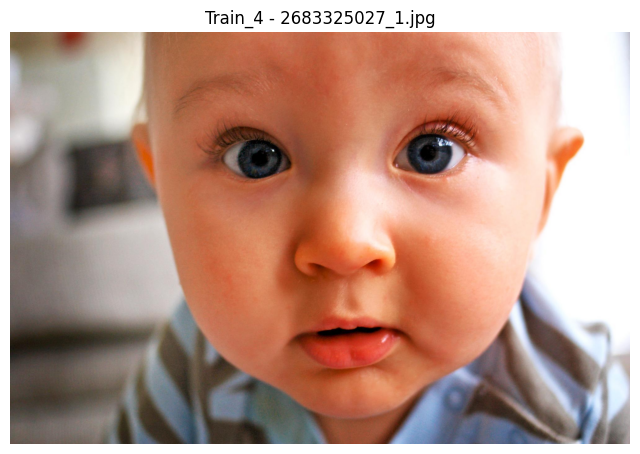

In [12]:
#Смотрим helen
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import yaml

base_path = '/kaggle/input/helen-eye-dataset'
os.makedirs(base_path, exist_ok=True)

def explore_helen_structure():
    """Исследуем структуру Helen dataset"""
    print("=== Helen Dataset Structure ===")

    items = os.listdir(base_path)
    print(f"Main folders: {items}")

    # Исследуем каждую папку
    for item in items:
        item_path = os.path.join(base_path, item)
        if os.path.isdir(item_path):
            print(f"\n📁 {item}/:")
            subitems = os.listdir(item_path)
            print(f"   Contents: {subitems[:10]}")  # первые 10 элементов

            # Если есть вложенные папки, покажем их содержимое
            for subitem in subitems:
                subitem_path = os.path.join(item_path, subitem)
                if os.path.isdir(subitem_path):
                    files = os.listdir(subitem_path)
                    image_files = [f for f in files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
                    txt_files = [f for f in files if f.endswith('.txt')]
                    print(f"   📂 {subitem}/: {len(image_files)} images, {len(txt_files)} txt files")
                    if image_files:
                        print(f"      Sample images: {image_files[:3]}")
                    if txt_files:
                        print(f"      Sample annotations: {txt_files[:3]}")

def check_annotation_format():
    """Проверяем формат аннотаций"""
    print("\n=== Checking Annotation Format ===")

    # Проверим разные возможные пути к аннотациям
    annotation_paths = [
        os.path.join(base_path, 'annotation'),
        os.path.join(base_path, 'annotation', 'annotation'),
        os.path.join(base_path, 'annotation', 'train_1'),
    ]

    for ann_path in annotation_paths:
        if os.path.exists(ann_path):
            print(f"Checking: {ann_path}")
            files = os.listdir(ann_path)
            txt_files = [f for f in files if f.endswith('.txt')]

            if txt_files:
                # Покажем содержимое первого файла аннотаций
                sample_ann = os.path.join(ann_path, txt_files[0])
                print(f"Sample annotation: {txt_files[0]}")
                with open(sample_ann, 'r') as f:
                    content = f.read().strip()
                    lines = content.split('\n')
                    print(f"Number of points: {len(lines)}")
                    print("First 5 points:")
                    for i, line in enumerate(lines[:5]):
                        print(f"  {i}: {line}")
                break

def check_image_structure():
    """Проверяем структуру изображений"""
    print("\n=== Checking Image Structure ===")

    # Проверим разные train папки
    for i in range(1, 5):
        train_path = os.path.join(base_path, f'train_{i}')
        if os.path.exists(train_path):
            print(f"\nTrain_{i}:")

            # Проверим есть ли вложенные папки
            items = os.listdir(train_path)
            for item in items:
                item_path = os.path.join(train_path, item)
                if os.path.isdir(item_path):
                    files = os.listdir(item_path)
                    image_files = [f for f in files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
                    print(f"  {item}/: {len(image_files)} images")

                    # Покажем пример изображения
                    if image_files:
                        sample_img = os.path.join(item_path, image_files[0])
                        try:
                            img = Image.open(sample_img)
                            print(f"    Sample image: {image_files[0]} - Size: {img.size}")

                            # Покажем изображение
                            plt.figure(figsize=(8, 6))
                            plt.imshow(img)
                            plt.title(f"Train_{i} - {image_files[0]}")
                            plt.axis('off')
                            plt.show()

                        except Exception as e:
                            print(f"    Error loading image: {e}")
                else:
                    # Если это файл, а не папка
                    if item.lower().endswith(('.jpg', '.png', '.jpeg')):
                        print(f"  {item} (direct file)")

# Запускаем исследование
explore_helen_structure()
check_annotation_format()
check_image_structure()

=== Visualizing Specific Eye Points: 125-133 (left), 134-142 (right) ===

📁 1893.txt -> 2898498038_2.jpg
Всего точек: 194
Размер изображения: 1145x1145
Левый глаз (125-133): 18 точек
Правый глаз (134-142): 19 точек


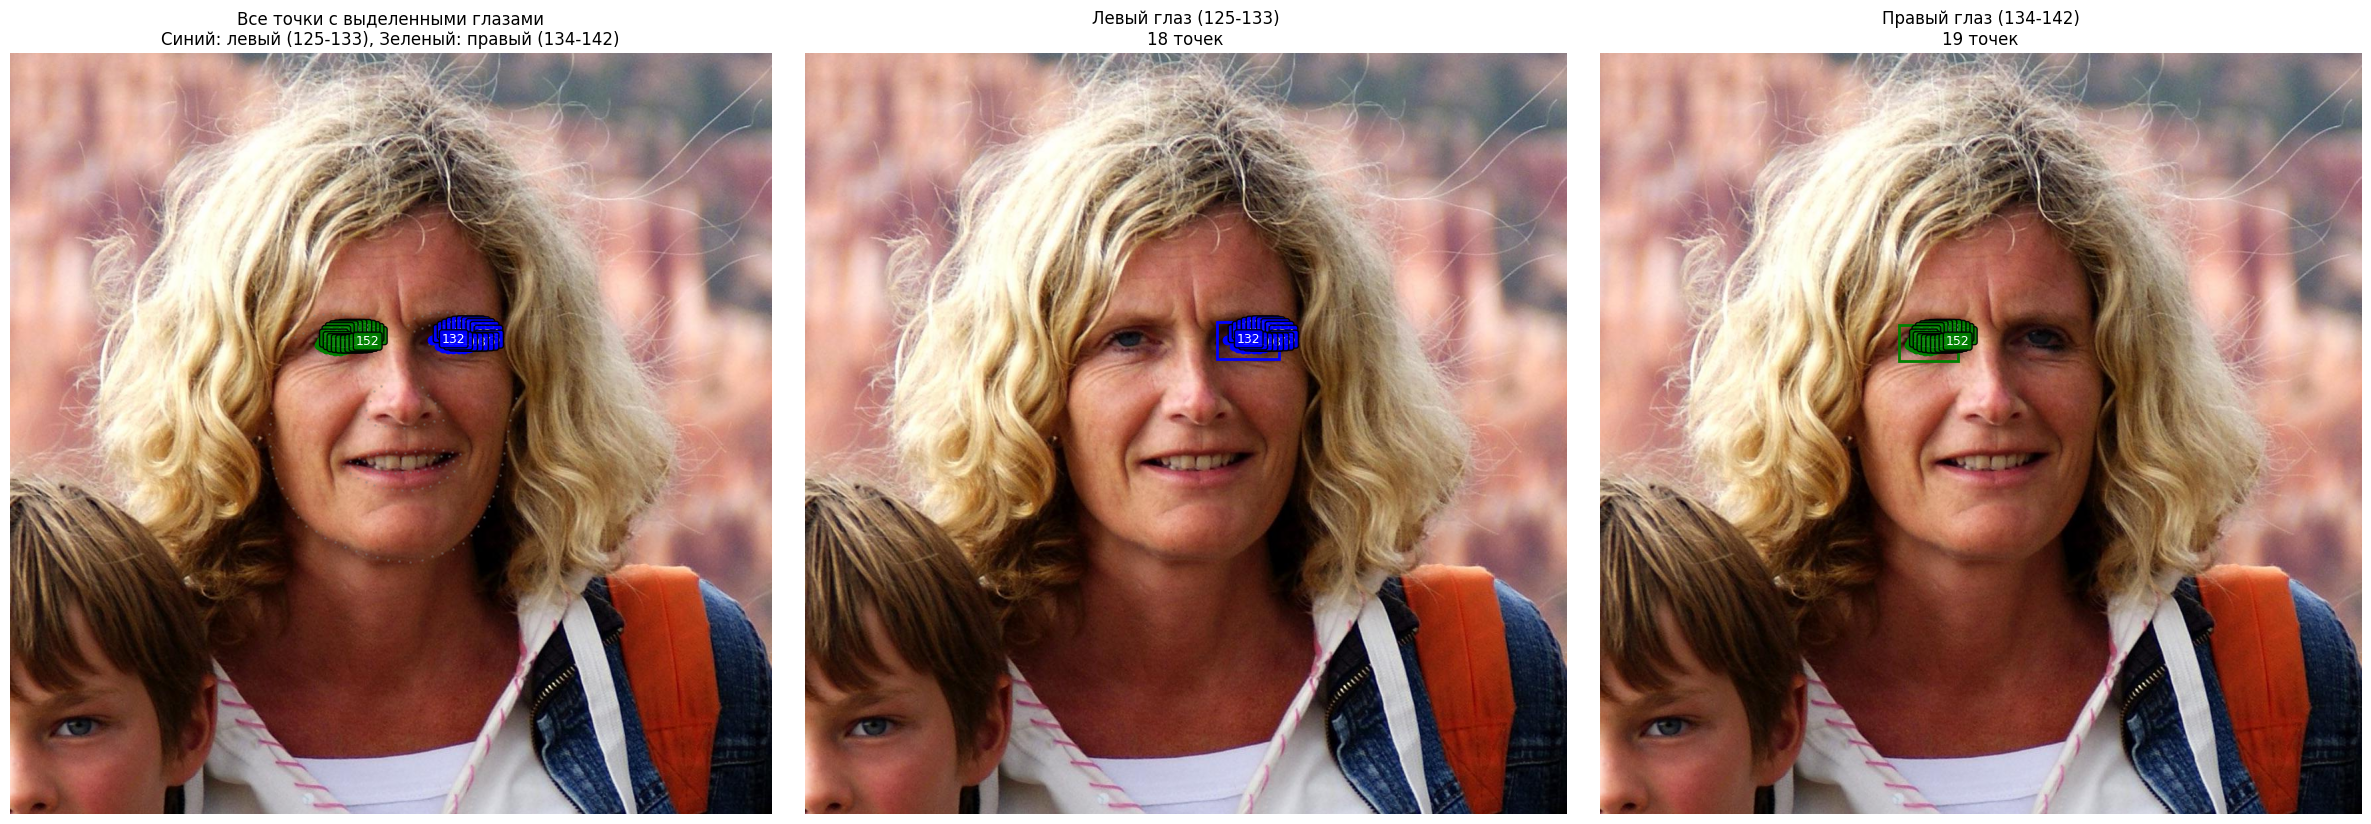


📊 Статистика глазных точек:
Левый глаз bbox:
  Центр: (666.0, 432.0)
  Размер: 92.4 x 55.8
  YOLO формат: [0.5816, 0.3773, 0.0807, 0.0487]
Правый глаз bbox:
  Центр: (493.2, 436.2)
  Размер: 88.6 x 53.2
  YOLO формат: [0.4307, 0.3810, 0.0773, 0.0465]

Координаты точек левого глаза (125-133):
  115: ( 634.8,  432.3)
  116: ( 640.9,  427.6)
  117: ( 647.6,  424.2)
  118: ( 654.5,  421.4)
  119: ( 661.8,  419.6)
  120: ( 669.8,  419.1)
  121: ( 677.2,  420.6)
  122: ( 684.1,  423.3)
  123: ( 690.5,  427.4)
  124: ( 696.3,  433.2)
  125: ( 697.1,  440.6)
  126: ( 690.4,  443.6)
  127: ( 682.6,  444.6)
  128: ( 674.6,  444.9)
  129: ( 666.4,  444.9)
  130: ( 658.2,  444.9)
  131: ( 650.9,  443.1)
  132: ( 644.1,  440.1)
Координаты точек правого глаза (134-142):
  134: ( 522.4,  435.4)
  135: ( 517.3,  430.8)
  136: ( 511.5,  427.9)
  137: ( 505.4,  425.9)
  138: ( 498.9,  424.6)
  139: ( 491.9,  424.6)
  140: ( 485.1,  425.4)
  141: ( 478.7,  426.6)
  142: ( 472.8,  429.2)
  143: ( 467.6, 

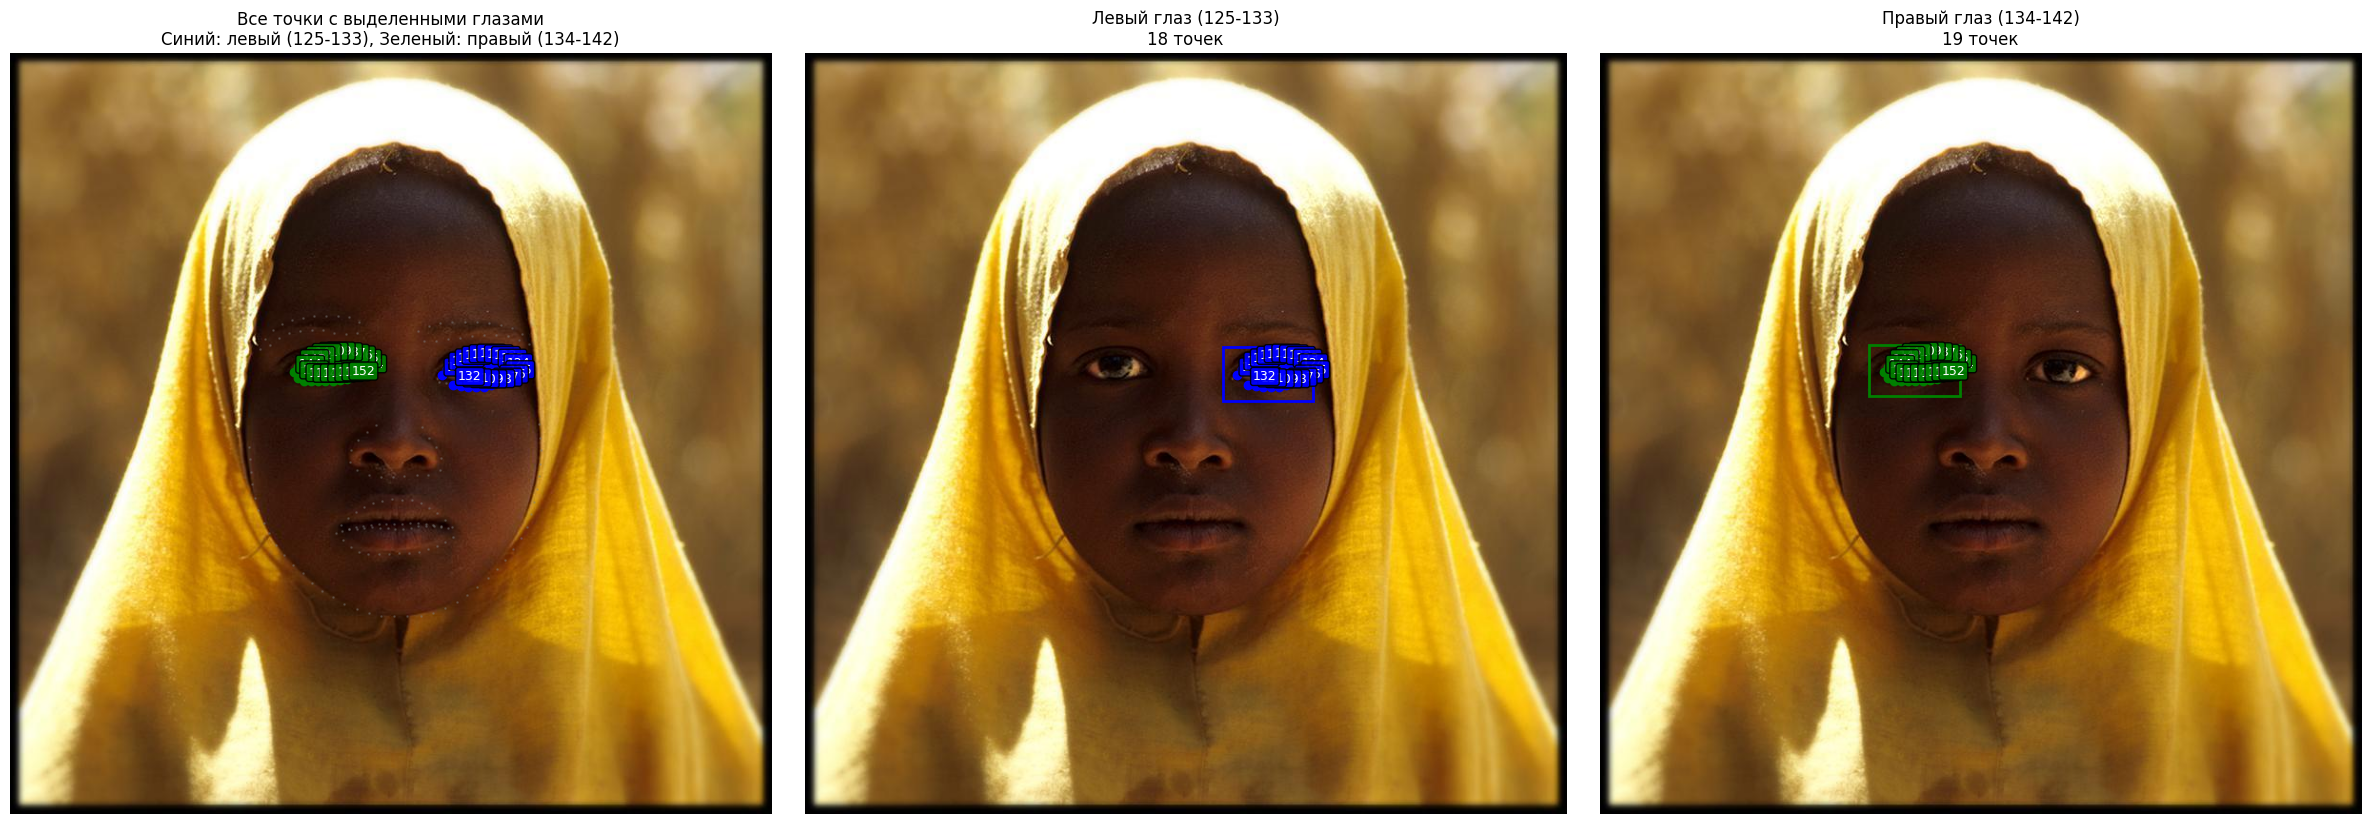


📊 Статистика глазных точек:
Левый глаз bbox:
  Центр: (485.7, 337.4)
  Размер: 94.9 x 57.0
  YOLO формат: [0.6071, 0.4218, 0.1187, 0.0712]
Правый глаз bbox:
  Центр: (330.1, 333.4)
  Размер: 95.2 x 53.2
  YOLO формат: [0.4127, 0.4167, 0.1191, 0.0666]

Координаты точек левого глаза (125-133):
  115: ( 453.2,  338.5)
  116: ( 458.4,  332.4)
  117: ( 465.1,  328.9)
  118: ( 472.1,  326.2)
  119: ( 479.6,  324.4)
  120: ( 487.7,  323.9)
  121: ( 495.7,  324.7)
  122: ( 503.1,  326.4)
  123: ( 510.1,  329.2)
  124: ( 516.3,  334.1)
  125: ( 518.1,  341.4)
  126: ( 511.8,  345.9)
  127: ( 504.9,  349.2)
  128: ( 497.3,  350.7)
  129: ( 489.1,  350.9)
  130: ( 480.9,  350.7)
  131: ( 472.9,  349.9)
  132: ( 465.4,  348.4)
Координаты точек правого глаза (134-142):
  134: ( 362.8,  335.0)
  135: ( 357.2,  329.5)
  136: ( 351.1,  325.8)
  137: ( 344.2,  324.0)
  138: ( 337.1,  322.5)
  139: ( 329.7,  321.8)
  140: ( 322.1,  322.0)
  141: ( 314.9,  323.2)
  142: ( 308.5,  326.3)
  143: ( 302.2, 

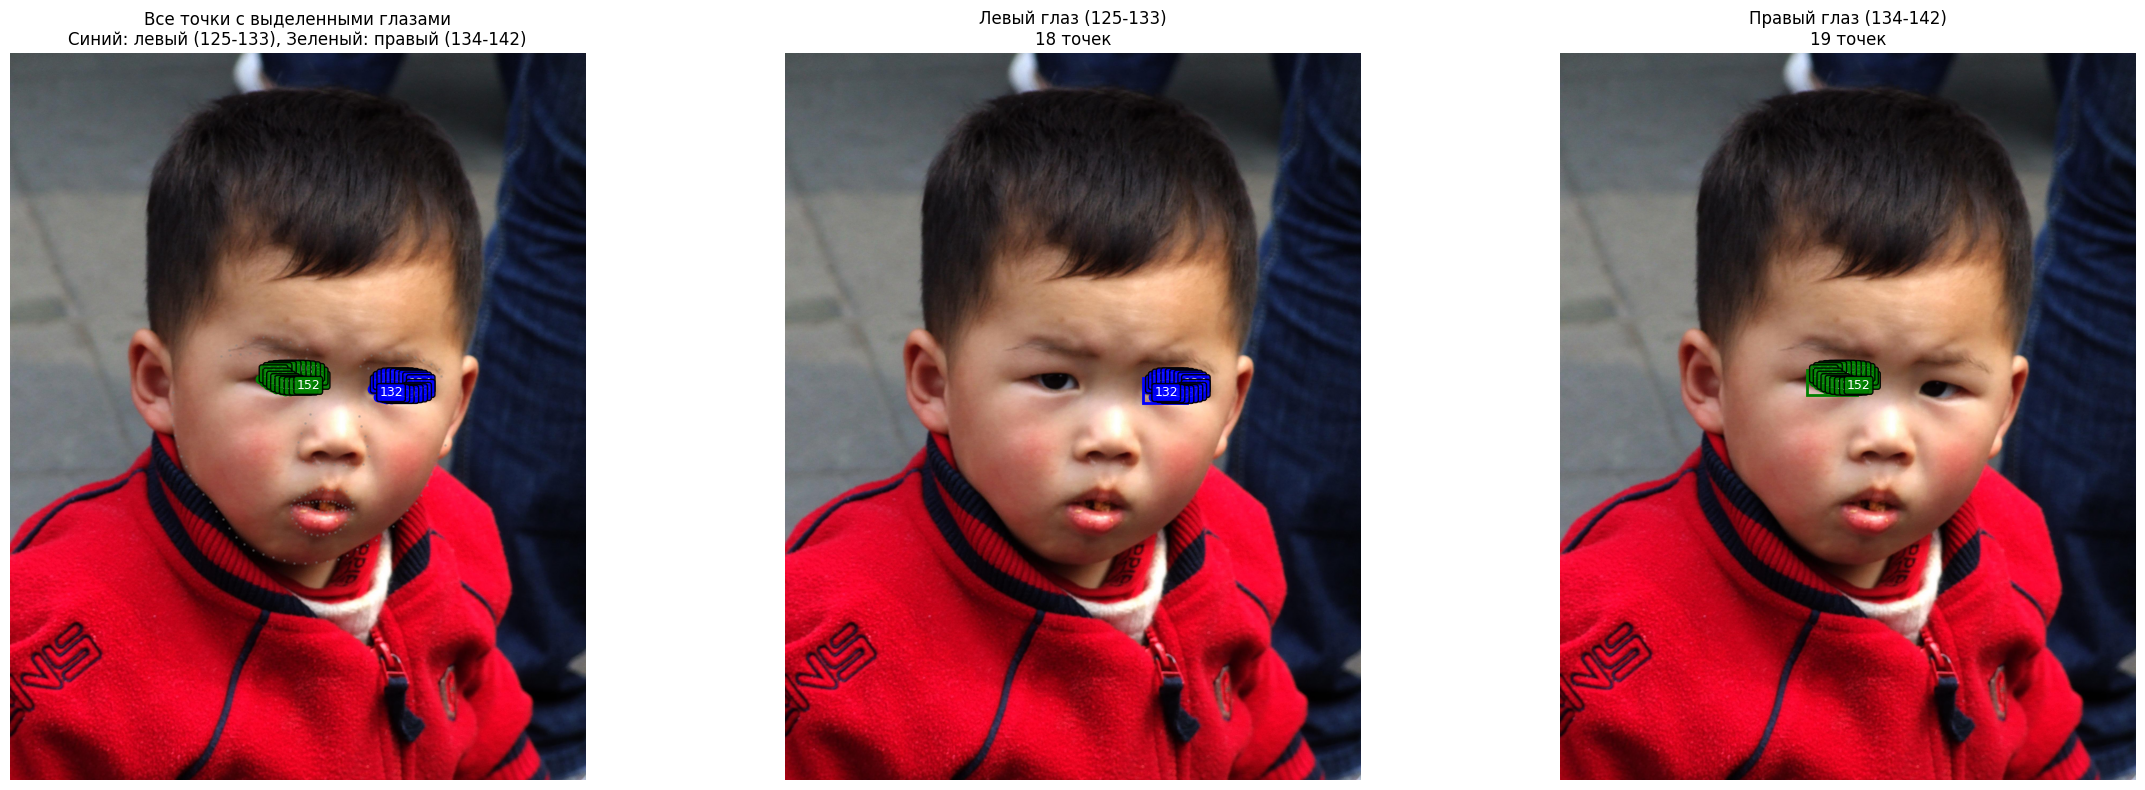


📊 Статистика глазных точек:
Левый глаз bbox:
  Центр: (1424.5, 1266.1)
  Размер: 165.0 x 95.8
  YOLO формат: [0.6595, 0.4640, 0.0764, 0.0351]
Правый глаз bbox:
  Центр: (1018.7, 1236.2)
  Размер: 188.0 x 92.8
  YOLO формат: [0.4716, 0.4530, 0.0870, 0.0340]

Координаты точек левого глаза (125-133):
  115: (1357.0, 1260.1)
  116: (1367.8, 1246.9)
  117: (1381.6, 1238.0)
  118: (1397.3, 1233.8)
  119: (1414.8, 1233.3)
  120: (1431.7, 1235.3)
  121: (1447.7, 1238.8)
  122: (1463.9, 1242.0)
  123: (1478.5, 1249.0)
  124: (1492.0, 1258.9)
  125: (1491.4, 1276.3)
  126: (1478.5, 1287.9)
  127: (1463.3, 1293.1)
  128: (1447.0, 1296.0)
  129: (1430.7, 1299.0)
  130: (1413.0, 1298.8)
  131: (1396.8, 1295.5)
  132: (1380.8, 1292.0)
Координаты точек правого глаза (134-142):
  134: (1097.7, 1245.8)
  135: (1089.8, 1230.4)
  136: (1077.4, 1216.8)
  137: (1061.5, 1210.6)
  138: (1044.1, 1207.3)
  139: (1026.0, 1205.6)
  140: (1007.4, 1204.8)
  141: ( 989.0, 1205.8)
  142: ( 971.1, 1208.1)
  143: ( 9

In [13]:
#Ищем точки для глаз на фото helen
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

base_path = '/kaggle/input/helen-eye-dataset'

def visualize_specific_eye_points():
    """Визуализируем конкретные точки глаз: 125-133 (левый) и 134-142 (правый)"""
    print("=== Visualizing Specific Eye Points: 125-133 (left), 134-142 (right) ===")

    annotation_dir = os.path.join(base_path, 'annotation', 'annotation')
    image_dir = os.path.join(base_path, 'train_1', 'train_1')

    ann_files = [f for f in os.listdir(annotation_dir) if f.endswith('.txt')][:3]

    for ann_file in ann_files:
        ann_path = os.path.join(annotation_dir, ann_file)

        # Читаем аннотацию
        with open(ann_path, 'r') as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]

        if not lines:
            continue

        image_name = lines[0]
        if not image_name.lower().endswith(('.jpg', '.png', '.jpeg')):
            image_name += '.jpg'

        points = []

        for line in lines[1:]:
            if ',' in line:
                try:
                    line_clean = line.replace(' ', '').replace(',', ' ')
                    parts = line_clean.split()
                    if len(parts) >= 2:
                        x, y = map(float, parts[:2])
                        points.append((x, y))
                except:
                    continue

        print(f"\n📁 {ann_file} -> {image_name}")
        print(f"Всего точек: {len(points)}")

        # Проверяем, что у нас достаточно точек
        if len(points) < 143:
            print(f"❌ В этом файле только {len(points)} точек, нужно минимум 143")
            continue

        # Находим изображение
        img_path = os.path.join(image_dir, image_name)
        if not os.path.exists(img_path):
            found = False
            for train_folder in ['train_1', 'train_2', 'train_3', 'train_4']:
                alt_path = os.path.join(base_path, train_folder, train_folder, image_name)
                if os.path.exists(alt_path):
                    img_path = alt_path
                    found = True
                    break
            if not found:
                continue

        # Загружаем изображение
        try:
            image = Image.open(img_path)
            img_np = np.array(image)
            h, w = img_np.shape[:2]

            print(f"Размер изображения: {w}x{h}")

            # Определяем точки глаз
            left_eye_indices = list(range(115, 133))  # 125-133
            right_eye_indices = list(range(134, 153)) # 134-153

            left_eye_points = [(i, points[i][0], points[i][1]) for i in left_eye_indices if i < len(points)]
            right_eye_points = [(i, points[i][0], points[i][1]) for i in right_eye_indices if i < len(points)]

            print(f"Левый глаз (125-133): {len(left_eye_points)} точек")
            print(f"Правый глаз (134-142): {len(right_eye_points)} точек")

            # Визуализация
            fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))

            # 1. Все точки с выделенными глазами
            ax1.imshow(img_np)
            # Все точки серым
            for i, (x, y) in enumerate(points):
                if 0 <= x < w and 0 <= y < h:
                    ax1.plot(x, y, 'o', markersize=1, color='gray', alpha=0.3)

            # Выделяем точки глаз
            for i, x, y in left_eye_points:
                ax1.plot(x, y, 'bo', markersize=6)
                ax1.text(x + 5, y - 5, str(i), fontsize=9, color='white',
                        bbox=dict(boxstyle="round,pad=0.2", facecolor='blue', alpha=0.9))

            for i, x, y in right_eye_points:
                ax1.plot(x, y, 'go', markersize=6)
                ax1.text(x + 5, y - 5, str(i), fontsize=9, color='white',
                        bbox=dict(boxstyle="round,pad=0.2", facecolor='green', alpha=0.9))

            ax1.set_title('Все точки с выделенными глазами\nСиний: левый (125-133), Зеленый: правый (134-142)')
            ax1.axis('off')

            # 2. Только левый глаз с bounding box
            ax2.imshow(img_np)

            # Рисуем левый глаз
            for i, x, y in left_eye_points:
                ax2.plot(x, y, 'bo', markersize=6)
                ax2.text(x + 5, y - 5, str(i), fontsize=9, color='white',
                        bbox=dict(boxstyle="round,pad=0.2", facecolor='blue', alpha=0.9))

            # Создаем bounding box для левого глаза
            if left_eye_points:
                left_x_coords = [p[1] for p in left_eye_points]
                left_y_coords = [p[2] for p in left_eye_points]

                left_x_min, left_x_max = min(left_x_coords), max(left_x_coords)
                left_y_min, left_y_max = min(left_y_coords), max(left_y_coords)

                # Добавляем запас
                padding = 15
                left_x_min = max(0, left_x_min - padding)
                left_x_max = min(w, left_x_max + padding)
                left_y_min = max(0, left_y_min - padding)
                left_y_max = min(h, left_y_max + padding)

                # Рисуем bounding box
                rect_left = plt.Rectangle((left_x_min, left_y_min),
                                        left_x_max - left_x_min,
                                        left_y_max - left_y_min,
                                        linewidth=2, edgecolor='blue', facecolor='none')
                ax2.add_patch(rect_left)

            ax2.set_title(f'Левый глаз (125-133)\n{len(left_eye_points)} точек')
            ax2.axis('off')

            # 3. Только правый глаз с bounding box
            ax3.imshow(img_np)

            # Рисуем правый глаз
            for i, x, y in right_eye_points:
                ax3.plot(x, y, 'go', markersize=6)
                ax3.text(x + 5, y - 5, str(i), fontsize=9, color='white',
                        bbox=dict(boxstyle="round,pad=0.2", facecolor='green', alpha=0.9))

            # Создаем bounding box для правого глаза
            if right_eye_points:
                right_x_coords = [p[1] for p in right_eye_points]
                right_y_coords = [p[2] for p in right_eye_points]

                right_x_min, right_x_max = min(right_x_coords), max(right_x_coords)
                right_y_min, right_y_max = min(right_y_coords), max(right_y_coords)

                # Добавляем запас
                padding = 15
                right_x_min = max(0, right_x_min - padding)
                right_x_max = min(w, right_x_max + padding)
                right_y_min = max(0, right_y_min - padding)
                right_y_max = min(h, right_y_max + padding)

                # Рисуем bounding box
                rect_right = plt.Rectangle((right_x_min, right_y_min),
                                         right_x_max - right_x_min,
                                         right_y_max - right_y_min,
                                         linewidth=2, edgecolor='green', facecolor='none')
                ax3.add_patch(rect_right)

            ax3.set_title(f'Правый глаз (134-142)\n{len(right_eye_points)} точек')
            ax3.axis('off')

            plt.tight_layout()
            plt.show()

            # Покажем координаты и статистику
            print(f"\n📊 Статистика глазных точек:")

            if left_eye_points:
                left_center_x = (left_x_min + left_x_max) / 2
                left_center_y = (left_y_min + left_y_max) / 2
                left_width = left_x_max - left_x_min
                left_height = left_y_max - left_y_min

                print(f"Левый глаз bbox:")
                print(f"  Центр: ({left_center_x:.1f}, {left_center_y:.1f})")
                print(f"  Размер: {left_width:.1f} x {left_height:.1f}")
                print(f"  YOLO формат: [{left_center_x/w:.4f}, {left_center_y/h:.4f}, {left_width/w:.4f}, {left_height/h:.4f}]")

            if right_eye_points:
                right_center_x = (right_x_min + right_x_max) / 2
                right_center_y = (right_y_min + right_y_max) / 2
                right_width = right_x_max - right_x_min
                right_height = right_y_max - right_y_min

                print(f"Правый глаз bbox:")
                print(f"  Центр: ({right_center_x:.1f}, {right_center_y:.1f})")
                print(f"  Размер: {right_width:.1f} x {right_height:.1f}")
                print(f"  YOLO формат: [{right_center_x/w:.4f}, {right_center_y/h:.4f}, {right_width/w:.4f}, {right_height/h:.4f}]")

            # Покажем координаты всех глазных точек
            print(f"\nКоординаты точек левого глаза (125-133):")
            for i, x, y in left_eye_points:
                print(f"  {i}: ({x:6.1f}, {y:6.1f})")

            print(f"Координаты точек правого глаза (134-142):")
            for i, x, y in right_eye_points:
                print(f"  {i}: ({x:6.1f}, {y:6.1f})")

        except Exception as e:
            print(f"Ошибка: {e}")

        print("=" * 80)

# Запускаем визуализацию конкретных точек
visualize_specific_eye_points()

=== Converting Helen Dataset to YOLO Format ===

📊 Пример для 2898498038_2.jpg:
   Размер: 1145x1145
   Левый глаз: 20 точек -> 0 0.430707 0.380991 0.066487 0.037773
   Правый глаз: 19 точек -> 1 0.581616 0.377288 0.070847 0.039956

📊 Пример для 279233131_1.jpg:
   Размер: 800x800
   Левый глаз: 20 точек -> 0 0.412656 0.416744 0.106031 0.054062
   Правый глаз: 19 точек -> 1 0.607088 0.421787 0.105495 0.058750

📊 Пример для 2830081484_1.jpg:
   Размер: 2160x2729
   Левый глаз: 20 точек -> 0 0.471606 0.452985 0.095093 0.033111
   Правый глаз: 19 точек -> 1 0.659505 0.463959 0.081262 0.034694
✅ Обработано: 50 файлов
✅ Обработано: 100 файлов
✅ Обработано: 150 файлов
✅ Обработано: 200 файлов
✅ Обработано: 250 файлов
✅ Обработано: 300 файлов
✅ Обработано: 350 файлов
✅ Обработано: 400 файлов
✅ Обработано: 450 файлов
✅ Обработано: 500 файлов
✅ Обработано: 550 файлов
✅ Обработано: 600 файлов
✅ Обработано: 650 файлов
✅ Обработано: 700 файлов
✅ Обработано: 750 файлов
✅ Обработано: 800 файлов
✅ Об

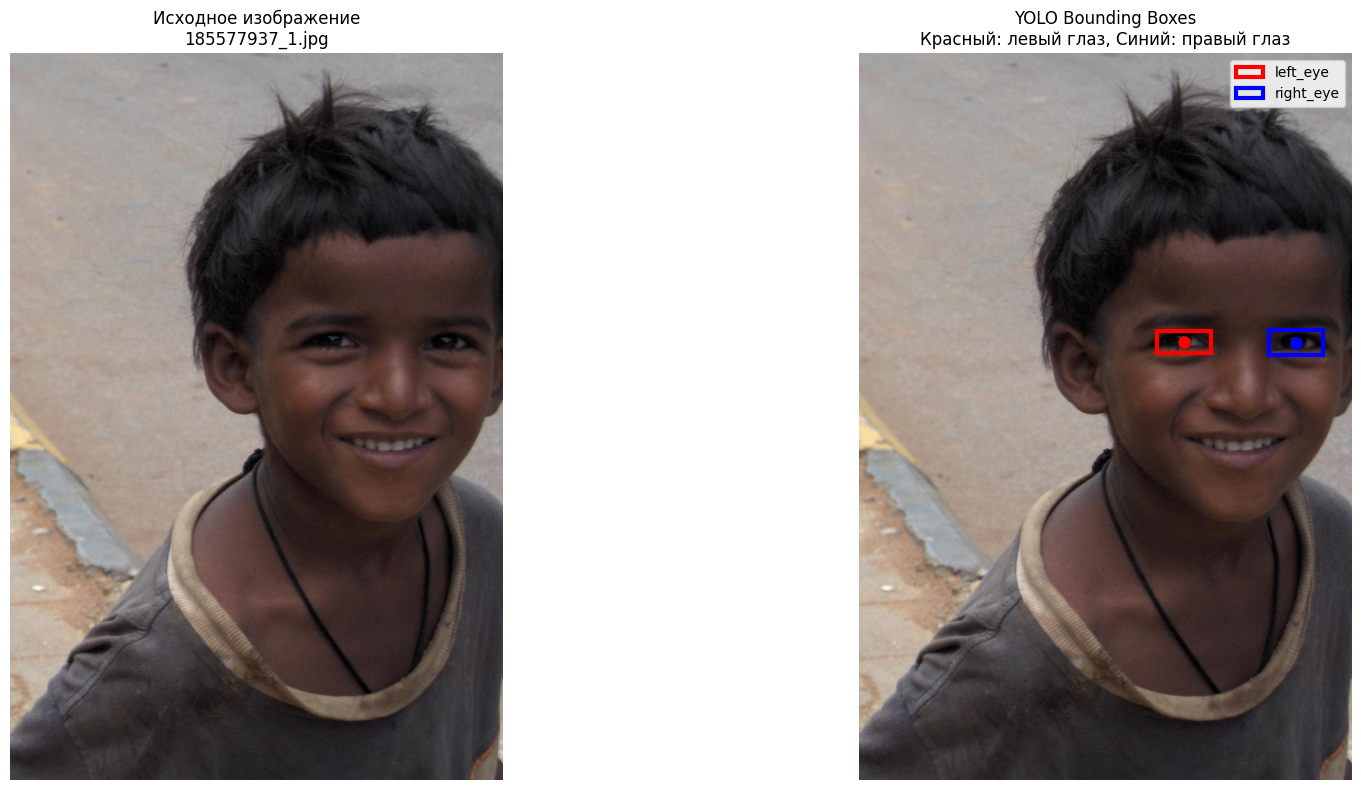

📁 185577937_1.jpg: 2 bbox'ов


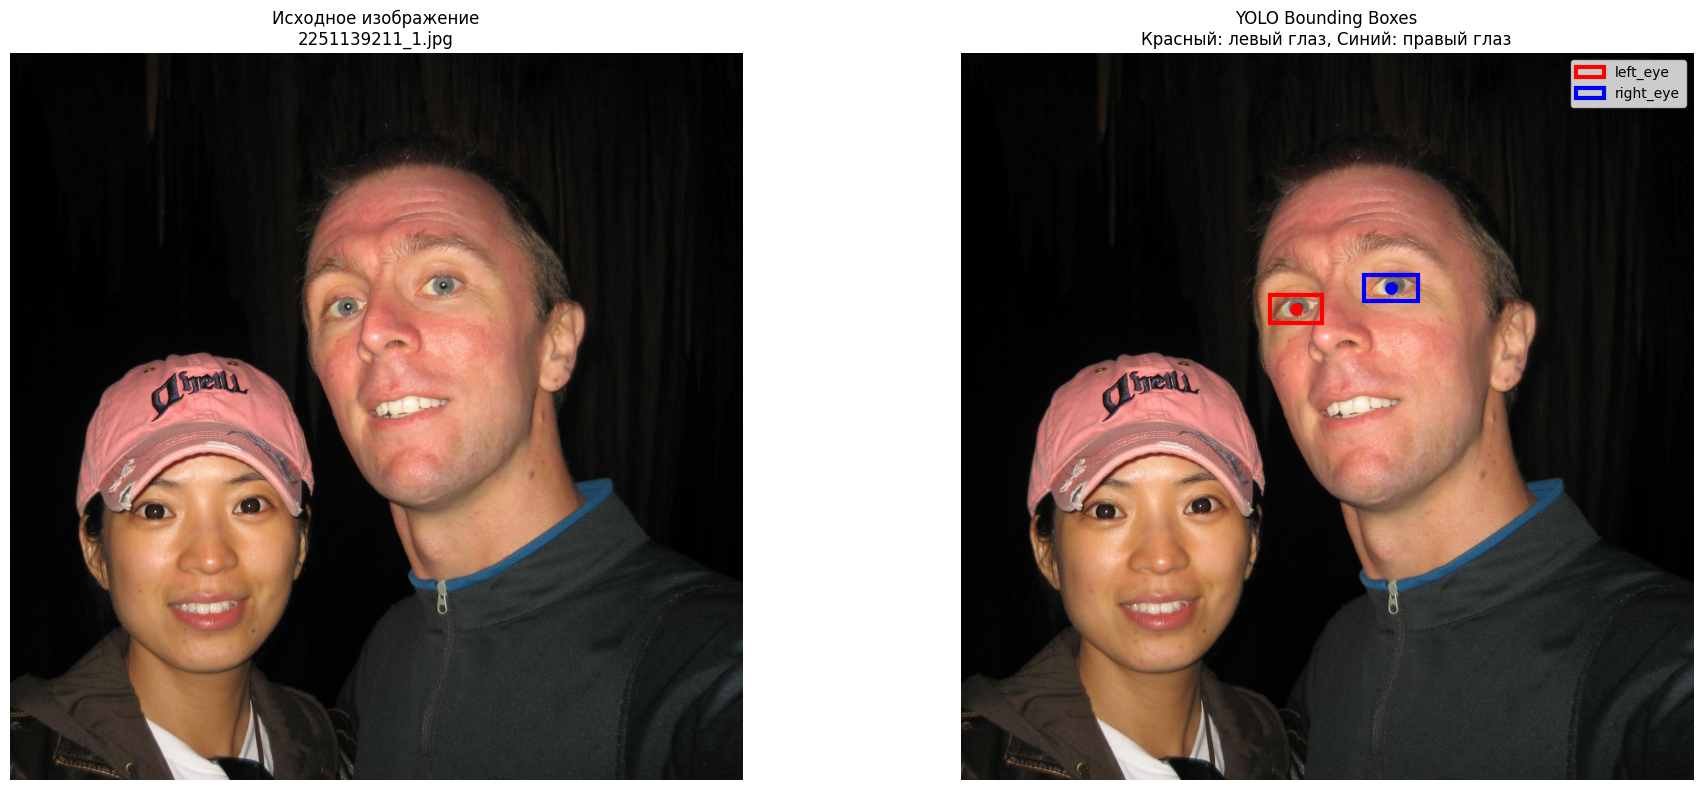

📁 2251139211_1.jpg: 2 bbox'ов


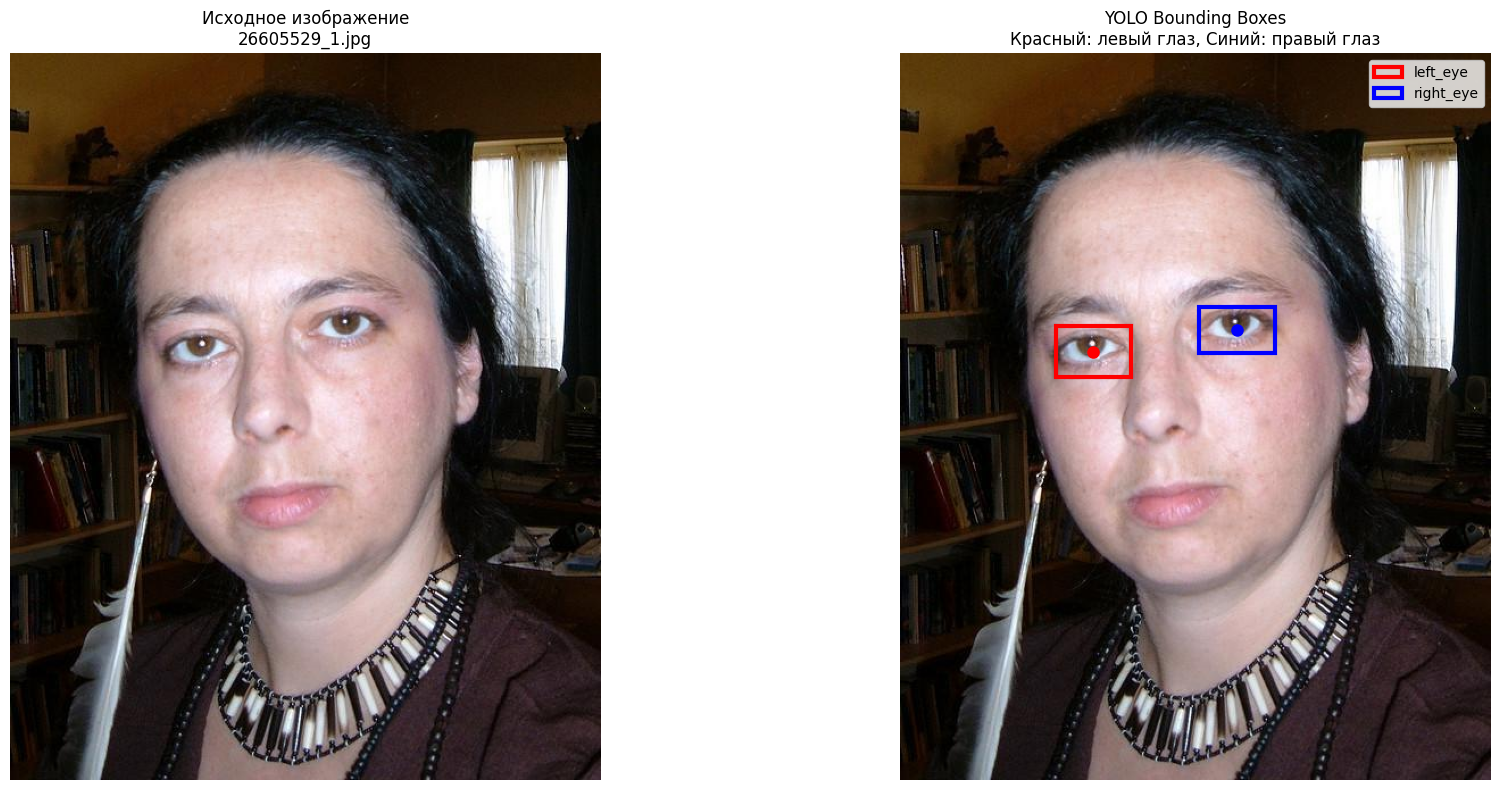

📁 26605529_1.jpg: 2 bbox'ов


In [14]:
#Конвертер helen -> yolo format, тут сделали датасет
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import shutil

base_path = '/kaggle/input/helen-eye-dataset'

def convert_helen_to_yolo():
    """Конвертируем Helen Dataset в YOLO-формат для детекции глаз"""
    print("=== Converting Helen Dataset to YOLO Format ===")

    annotation_dir = os.path.join(base_path, 'annotation', 'annotation')
    image_dir = os.path.join(base_path, 'train_1', 'train_1')

    # Создаем папки для YOLO
    yolo_dir = '/kaggle/working/yolo_eyes'
    images_dir = os.path.join(yolo_dir, 'images')
    labels_dir = os.path.join(yolo_dir, 'labels')

    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(labels_dir, exist_ok=True)

    # Создаем файл с классами
    with open(os.path.join(yolo_dir, 'classes.txt'), 'w') as f:
        f.write('left_eye\n')
        f.write('right_eye\n')

    ann_files = [f for f in os.listdir(annotation_dir) if f.endswith('.txt')]

    processed_count = 0
    error_count = 0

    for ann_file in ann_files:
        try:
            ann_path = os.path.join(annotation_dir, ann_file)

            # Читаем аннотацию
            with open(ann_path, 'r') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]

            if not lines:
                continue

            image_name = lines[0]
            if not image_name.lower().endswith(('.jpg', '.png', '.jpeg')):
                image_name += '.jpg'

            points = []

            for line in lines[1:]:
                if ',' in line:
                    try:
                        line_clean = line.replace(' ', '').replace(',', ' ')
                        parts = line_clean.split()
                        if len(parts) >= 2:
                            x, y = map(float, parts[:2])
                            points.append((x, y))
                    except:
                        continue

            # Проверяем, что у нас достаточно точек
            if len(points) < 154:
                print(f"❌ {ann_file}: мало точек ({len(points)})")
                error_count += 1
                continue

            # Находим изображение
            img_path = os.path.join(image_dir, image_name)
            if not os.path.exists(img_path):
                found = False
                for train_folder in ['train_1', 'train_2', 'train_3', 'train_4']:
                    alt_path = os.path.join(base_path, train_folder, train_folder, image_name)
                    if os.path.exists(alt_path):
                        img_path = alt_path
                        found = True
                        break
                if not found:
                    error_count += 1
                    continue

            # Загружаем изображение для получения размеров
            image = Image.open(img_path)
            w, h = image.size

            # Определяем ВСЕ точки глаз
            right_eye_indices = list(range(115, 134))   # 115-133 (19 точек)
            left_eye_indices = list(range(134, 154))  # 134-153 (20 точек)

            left_eye_points = [points[i] for i in left_eye_indices if i < len(points)]
            right_eye_points = [points[i] for i in right_eye_indices if i < len(points)]

            if len(left_eye_points) < 10 or len(right_eye_points) < 10:
                print(f"❌ {ann_file}: недостаточно глазных точек")
                error_count += 1
                continue

            # Функция для создания YOLO bbox из точек
            def create_yolo_bbox(eye_points, w, h, class_id):
                if not eye_points:
                    return None

                # Находим границы всех точек
                x_coords = [p[0] for p in eye_points]
                y_coords = [p[1] for p in eye_points]

                x_min, x_max = min(x_coords), max(x_coords)
                y_min, y_max = min(y_coords), max(y_coords)

                # Добавляем ЗАПАС (комбинированный подход)
                bbox_width = x_max - x_min
                bbox_height = y_max - y_min

                padding_x = max(8, bbox_width * 0.15)  # минимум 8px или 12% от ширины
                padding_y = max(10, bbox_height * 0.22) # минимум 10px или 18% от высоты

                x_min = max(0, x_min - padding_x)
                x_max = min(w, x_max + padding_x)
                y_min = max(0, y_min - padding_y)
                y_max = min(h, y_max + padding_y)

                # Вычисляем YOLO-формат
                center_x = (x_min + x_max) / 2
                center_y = (y_min + y_max) / 2
                bbox_width = x_max - x_min
                bbox_height = y_max - y_min

                # Нормализуем
                yolo_x = center_x / w
                yolo_y = center_y / h
                yolo_w = bbox_width / w
                yolo_h = bbox_height / h

                # Проверяем валидность координат
                if (yolo_x < 0 or yolo_x > 1 or yolo_y < 0 or yolo_y > 1 or
                    yolo_w <= 0 or yolo_h <= 0 or yolo_w > 1 or yolo_h > 1):
                    return None

                return f"{class_id} {yolo_x:.6f} {yolo_y:.6f} {yolo_w:.6f} {yolo_h:.6f}"

            # Создаем YOLO аннотации
            yolo_lines = []

            # Левый глаз (класс 0)
            left_bbox = create_yolo_bbox(left_eye_points, w, h, 0)
            if left_bbox:
                yolo_lines.append(left_bbox)

            # Правый глаз (класс 1)
            right_bbox = create_yolo_bbox(right_eye_points, w, h, 1)
            if right_bbox:
                yolo_lines.append(right_bbox)

            # Если есть хотя бы один глаз - сохраняем
            if yolo_lines:
                # Копируем изображение
                image_output_path = os.path.join(images_dir, image_name)
                shutil.copy2(img_path, image_output_path)

                # Сохраняем YOLO аннотацию
                label_name = os.path.splitext(image_name)[0] + '.txt'
                label_path = os.path.join(labels_dir, label_name)

                with open(label_path, 'w') as f:
                    for line in yolo_lines:
                        f.write(line + '\n')

                processed_count += 1
                if processed_count % 50 == 0:
                    print(f"✅ Обработано: {processed_count} файлов")

                # Покажем пример для первых 3 файлов
                if processed_count <= 3:
                    print(f"\n📊 Пример для {image_name}:")
                    print(f"   Размер: {w}x{h}")
                    print(f"   Левый глаз: {len(left_eye_points)} точек -> {left_bbox}")
                    print(f"   Правый глаз: {len(right_eye_points)} точек -> {right_bbox}")

            else:
                error_count += 1

        except Exception as e:
            print(f"❌ Ошибка в {ann_file}: {e}")
            error_count += 1

    # Финальная статистика
    print(f"\n🎉 Конвертация завершена!")
    print(f"✅ Успешно обработано: {processed_count} файлов")
    print(f"❌ Ошибок: {error_count} файлов")
    print(f"📁 Результаты в: {yolo_dir}")

    # Покажем структуру папок
    print(f"\n📂 Структура YOLO датасета:")
    print(f"   {yolo_dir}/")
    print(f"   ├── images/     ({len(os.listdir(images_dir))} файлов)")
    print(f"   ├── labels/     ({len(os.listdir(labels_dir))} файлов)")
    print(f"   └── classes.txt")

    return yolo_dir

def visualize_yolo_results(yolo_dir, num_samples=3):
    """Визуализируем результаты YOLO конвертации"""
    print(f"\n=== Визуализация результатов ===")

    images_dir = os.path.join(yolo_dir, 'images')
    labels_dir = os.path.join(yolo_dir, 'labels')

    image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))][:num_samples]

    for image_file in image_files:
        image_path = os.path.join(images_dir, image_file)
        label_path = os.path.join(labels_dir, os.path.splitext(image_file)[0] + '.txt')

        if not os.path.exists(label_path):
            continue

        # Загружаем изображение
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        # Читаем YOLO аннотации
        with open(label_path, 'r') as f:
            yolo_lines = [line.strip() for line in f.readlines() if line.strip()]

        # Визуализируем
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

        # 1. Исходное изображение
        ax1.imshow(image)
        ax1.set_title(f'Исходное изображение\n{image_file}')
        ax1.axis('off')

        # 2. С YOLO bbox
        ax2.imshow(image)

        for line in yolo_lines:
            parts = line.split()
            if len(parts) == 5:
                class_id, x_center, y_center, bbox_w, bbox_h = map(float, parts)

                # Конвертируем обратно в пиксели
                x_center_px = x_center * w
                y_center_px = y_center * h
                bbox_w_px = bbox_w * w
                bbox_h_px = bbox_h * h

                x_min = x_center_px - bbox_w_px / 2
                y_min = y_center_px - bbox_h_px / 2

                # Рисуем bbox
                color = 'red' if class_id == 0 else 'blue'
                label = 'left_eye' if class_id == 0 else 'right_eye'

                rect = plt.Rectangle((x_min, y_min), bbox_w_px, bbox_h_px,
                                   linewidth=3, edgecolor=color, facecolor='none', label=label)
                ax2.add_patch(rect)

                # Центр
                ax2.plot(x_center_px, y_center_px, 'o', markersize=8, color=color)

        ax2.set_title('YOLO Bounding Boxes\nКрасный: левый глаз, Синий: правый глаз')
        ax2.axis('off')
        ax2.legend()

        plt.tight_layout()
        plt.show()

        print(f"📁 {image_file}: {len(yolo_lines)} bbox'ов")

# Запускаем конвертацию
yolo_dir = convert_helen_to_yolo()

# Визуализируем результаты
visualize_yolo_results(yolo_dir)

In [15]:
#Разделение нашего датасета на val и train
import os
import shutil
import numpy as np

def split_dataset_for_yolo(yolo_dir, train_ratio=0.8, random_seed=42):
    """Разделяет YOLO датасет на train и val"""
    print("=== Splitting Dataset for YOLO ===")

    # Устанавливаем seed для воспроизводимости
    np.random.seed(random_seed)

    images_dir = os.path.join(yolo_dir, 'images')
    labels_dir = os.path.join(yolo_dir, 'labels')

    # Проверяем существование папок
    if not os.path.exists(images_dir):
        print(f"❌ Папка images не найдена: {images_dir}")
        return
    if not os.path.exists(labels_dir):
        print(f"❌ Папка labels не найдена: {labels_dir}")
        return

    # Создаем подпапки для train и val
    train_images_dir = os.path.join(yolo_dir, 'train', 'images')
    train_labels_dir = os.path.join(yolo_dir, 'train', 'labels')
    val_images_dir = os.path.join(yolo_dir, 'val', 'images')
    val_labels_dir = os.path.join(yolo_dir, 'val', 'labels')

    # Создаем все необходимые папки
    for dir_path in [train_images_dir, train_labels_dir, val_images_dir, val_labels_dir]:
        os.makedirs(dir_path, exist_ok=True)
        print(f"📁 Создана папка: {dir_path}")

    # Получаем все изображения
    all_images = [f for f in os.listdir(images_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    if not all_images:
        print("❌ Не найдено изображений в папке images")
        return

    print(f"📊 Всего изображений: {len(all_images)}")

    # Перемешиваем и разделяем
    np.random.shuffle(all_images)
    split_idx = int(len(all_images) * train_ratio)

    train_files = all_images[:split_idx]
    val_files = all_images[split_idx:]

    print(f"🎯 Разделение: {len(train_files)} train, {len(val_files)} val")

    # Функция для копирования файлов
    def copy_files(files, src_images_dir, src_labels_dir, dst_images_dir, dst_labels_dir, set_name):
        copied_count = 0
        for image_file in files:
            # Копируем изображение
            src_image_path = os.path.join(src_images_dir, image_file)
            dst_image_path = os.path.join(dst_images_dir, image_file)
            shutil.copy2(src_image_path, dst_image_path)

            # Копируем соответствующий label файл
            label_file = os.path.splitext(image_file)[0] + '.txt'
            src_label_path = os.path.join(src_labels_dir, label_file)
            dst_label_path = os.path.join(dst_labels_dir, label_file)

            if os.path.exists(src_label_path):
                shutil.copy2(src_label_path, dst_label_path)
                copied_count += 1
            else:
                print(f"⚠️ Label не найден: {label_file}")

        print(f"✅ {set_name}: скопировано {copied_count} пар image/label")
        return copied_count

    # Копируем train данные
    train_count = copy_files(train_files, images_dir, labels_dir,
                           train_images_dir, train_labels_dir, "TRAIN")

    # Копируем val данные
    val_count = copy_files(val_files, images_dir, labels_dir,
                         val_images_dir, val_labels_dir, "VAL")

    # Статистика
    print(f"\n📊 Итоговая статистика:")
    print(f"   Train: {train_count} изображений")
    print(f"   Val: {val_count} изображений")
    print(f"   Всего: {train_count + val_count} изображений")

    # Проверяем что все ок
    train_images_actual = len(os.listdir(train_images_dir))
    val_images_actual = len(os.listdir(val_images_dir))

    print(f"   Проверка: {train_images_actual} train images, {val_images_actual} val images")

    return {
        'train_images': train_images_dir,
        'train_labels': train_labels_dir,
        'val_images': val_images_dir,
        'val_labels': val_labels_dir,
        'train_count': train_count,
        'val_count': val_count
    }

def update_yolo_config(yolo_dir, split_info):
    """Обновляет data.yaml после разделения"""
    print("\n=== Updating data.yaml ===")

    yaml_path = os.path.join(yolo_dir, 'data.yaml')

    data_yaml = {
        'path': yolo_dir,
        'train': 'train/images',
        'val': 'val/images',
        'nc': 2,
        'names': ['left_eye', 'right_eye']
    }

    with open(yaml_path, 'w') as f:
        yaml.dump(data_yaml, f)

    print("✅ data.yaml обновлен:")
    print(f"   train: {data_yaml['train']}")
    print(f"   val: {data_yaml['val']}")
    print(f"   classes: {data_yaml['names']}")

    return yaml_path

# ЗАПУСКАЕМ РАЗДЕЛЕНИЕ
print("🎯 STARTING DATASET SPLIT")

# Разделяем данные
split_info = split_dataset_for_yolo(yolo_dir, train_ratio=0.8)

if split_info:
    # Обновляем конфиг
    yaml_path = update_yolo_config(yolo_dir, split_info)

    print(f"\n🎉 РАЗДЕЛЕНИЕ ЗАВЕРШЕНО!")
    print("📂 Структура датасета:")
    print(f"   {yolo_dir}/")
    print(f"   ├── images/     (оригиналы)")
    print(f"   ├── labels/     (оригиналы)")
    print(f"   ├── train/")
    print(f"   │   ├── images/ ({split_info['train_count']} файлов)")
    print(f"   │   └── labels/ ({split_info['train_count']} файлов)")
    print(f"   ├── val/")
    print(f"   │   ├── images/ ({split_info['val_count']} файлов)")
    print(f"   │   └── labels/ ({split_info['val_count']} файлов)")
    print(f"   └── data.yaml")

    print(f"\n🚀 Теперь можно запускать обучение!")
else:
    print("❌ Разделение не удалось")

🎯 STARTING DATASET SPLIT
=== Splitting Dataset for YOLO ===
📁 Создана папка: /kaggle/working/yolo_eyes/train/images
📁 Создана папка: /kaggle/working/yolo_eyes/train/labels
📁 Создана папка: /kaggle/working/yolo_eyes/val/images
📁 Создана папка: /kaggle/working/yolo_eyes/val/labels
📊 Всего изображений: 2000
🎯 Разделение: 1600 train, 400 val
✅ TRAIN: скопировано 1600 пар image/label
✅ VAL: скопировано 400 пар image/label

📊 Итоговая статистика:
   Train: 1600 изображений
   Val: 400 изображений
   Всего: 2000 изображений
   Проверка: 1600 train images, 400 val images

=== Updating data.yaml ===
✅ data.yaml обновлен:
   train: train/images
   val: val/images
   classes: ['left_eye', 'right_eye']

🎉 РАЗДЕЛЕНИЕ ЗАВЕРШЕНО!
📂 Структура датасета:
   /kaggle/working/yolo_eyes/
   ├── images/     (оригиналы)
   ├── labels/     (оригиналы)
   ├── train/
   │   ├── images/ (1600 файлов)
   │   └── labels/ (1600 файлов)
   ├── val/
   │   ├── images/ (400 файлов)
   │   └── labels/ (400 файлов)
   └─

🎯 STARTING YOLO TRAINING WITH SPLIT DATASET
=== Starting YOLO Training ===
📂 Checking dataset structure...
   images: 1600 files
   labels: 1600 files
   images: 400 files
   labels: 400 files
✅ data.yaml found: /kaggle/working/yolo_eyes/data.yaml
=== Setting up YOLO Environment ===
🎯 Device: cuda
🎯 GPU: Tesla T4
🎯 GPU Memory: 14.7 GB
📦 Installing ultralytics...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 7.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🔄 Loading model: yolov8n.pt
🚀 Starting training...
📊 Training parameters:
   Epochs: 10
   Batch size: 16
   Image size: 640
   Model: yolov8n.pt
   Device: cuda
   Train samples: 1600
   Val samples: 400
Ultralytics 8.3.230 🚀 Python-3.12.12 torch-

/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1299: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  attn = (q.transpose(-2, -1) @ k) * self.scale
/usr/local/lib/python3.12/dist-packages/ultralytics/nn/modules/block.py:1301: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic 

AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2459.8±772.8 MB/s, size: 255.0 KB)
train: Scanning /kaggle/working/yolo_eyes/train/labels... 1600 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1600/1600 2.5Kit/s 0.7s
train: New cache created: /kaggle/working/yolo_eyes/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 400.3±190.1 MB/s, size: 156.4 KB)
val: Scanning /kaggle/working/yolo_eyes/val/labels... 400 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 400/400 1.8Kit/s 0.2s
val: New cache created: /kaggle/working/yolo_eyes/val/labels.cache
Plotting labels to /content/runs/detect/train/labels.jpg... 
optimizer: AdamW(lr=0.01, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:238: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


       1/10         2G      1.805      2.029      1.363         32        640: 100% ━━━━━━━━━━━━ 100/100 2.5it/s 39.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.4it/s 9.0s
                   all        400        800      0.163      0.686      0.164     0.0792

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/10      2.69G      1.627      1.468      1.258         32        640: 0% ──────────── 0/100  0.2s

...

       8/10      2.81G       1.44      1.168      1.214         32        640: 100% ━━━━━━━━━━━━ 100/100 2.7it/s 36.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.5it/s 5.1s
                   all        400        800      0.467      0.924      0.503      0.308

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:238: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


       9/10      2.82G        1.4       1.14      1.195         32        640: 100% ━━━━━━━━━━━━ 100/100 2.7it/s 37.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.8it/s 4.7s
                   all        400        800      0.472      0.943      0.508      0.313

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/loss.py:238: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  pred_dist = pred_dist.view(b, a, 4, c // 4).softmax(3).matmul(self.proj.type(pred_dist.dtype))


      10/10      2.84G      1.373      1.125      1.176         32        640: 100% ━━━━━━━━━━━━ 100/100 2.8it/s 36.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.7it/s 4.8s
                   all        400        800      0.471      0.921      0.512      0.323

10 epochs completed in 0.119 hours.
Optimizer stripped from /content/runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from /content/runs/detect/train/weights/best.pt, 6.2MB

Validating /content/runs/detect/train/weights/best.pt...
Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.1it/s 6.2s
                   all        400        800       0.47       0.92      0.513      0.323
              left_eye        400        40

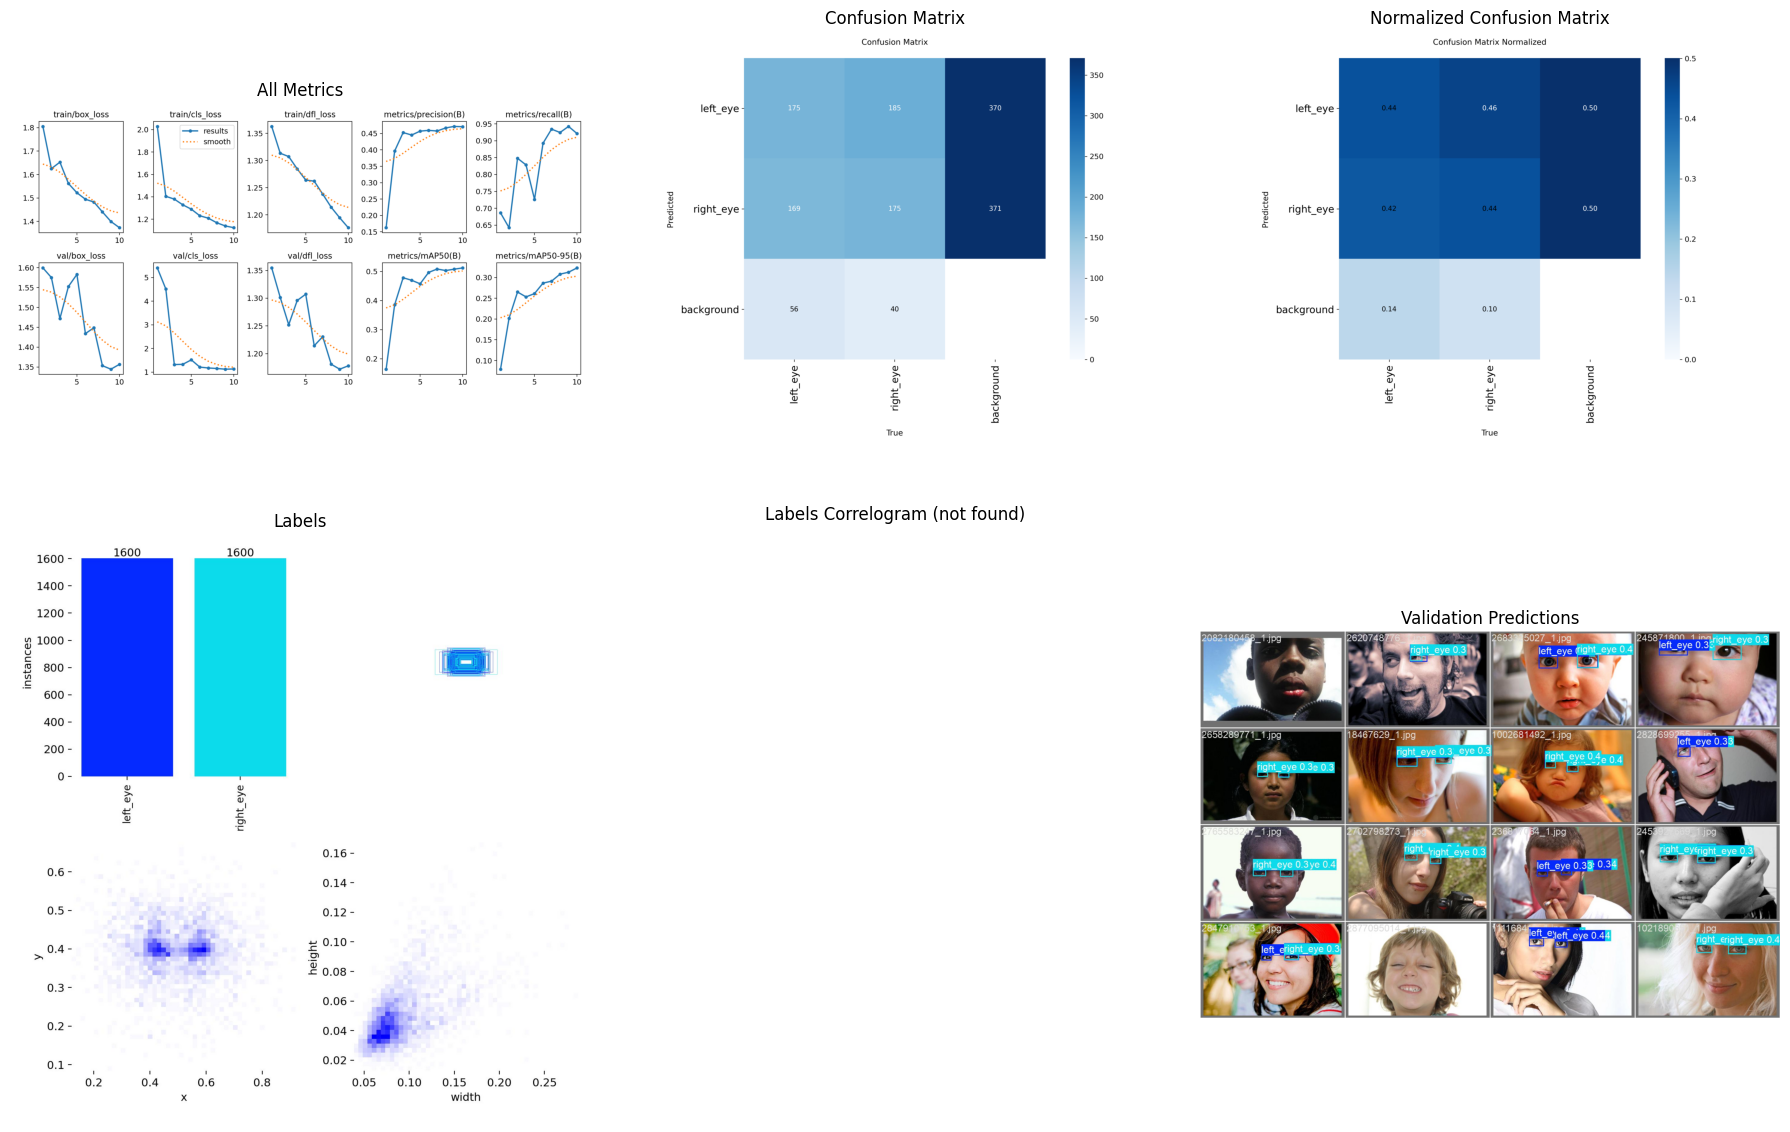


=== Model Evaluation ===
📊 Running validation...
Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2224.4±899.8 MB/s, size: 83.5 KB)
val: Scanning /kaggle/working/yolo_eyes/val/labels.cache... 400 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 400/400 772.4Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 2.9it/s 8.5s
                   all        400        800      0.472      0.918      0.512      0.324
              left_eye        400        400      0.464       0.91      0.464      0.287
             right_eye        400        400       0.48      0.927       0.56       0.36
Speed: 2.7ms preprocess, 8.0ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /content/runs/detect/val
✅ Validation results:
   mAP50: 0.5122
   mAP

In [ ]:
#Обучение нейросети
import os
import yaml
import torch
from IPython.display import FileLink, display
import matplotlib.pyplot as plt
import glob

def setup_yolo_environment():
    """Проверяем и настраиваем окружение для YOLO"""
    print("=== Setting up YOLO Environment ===")

    # Проверяем доступность GPU
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"🎯 Device: {device}")
    if torch.cuda.is_available():
        print(f"🎯 GPU: {torch.cuda.get_device_name()}")
        print(f"🎯 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

    # Устанавливаем ultralytics если нужно
    try:
        from ultralytics import YOLO
        print("✅ Ultralytics already installed")
    except ImportError:
        print("📦 Installing ultralytics...")
        %pip install ultralytics
        from ultralytics import YOLO

    return device

def train_yolo_model(yolo_dir, epochs=100, batch_size=16, model_size='n'):
    """Обучаем YOLO модель на разделенных данных"""
    print("=== Starting YOLO Training ===")

    # Проверяем структуру данных
    print("📂 Checking dataset structure...")
    required_dirs = [
        os.path.join(yolo_dir, 'train', 'images'),
        os.path.join(yolo_dir, 'train', 'labels'),
        os.path.join(yolo_dir, 'val', 'images'),
        os.path.join(yolo_dir, 'val', 'labels')
    ]

    for dir_path in required_dirs:
        if not os.path.exists(dir_path):
            print(f"❌ Missing directory: {dir_path}")
            return None, None
        file_count = len([f for f in os.listdir(dir_path) if not f.startswith('.')])
        print(f"   {os.path.basename(dir_path)}: {file_count} files")

    # Проверяем data.yaml
    yaml_path = os.path.join(yolo_dir, 'data.yaml')
    if not os.path.exists(yaml_path):
        print(f"❌ data.yaml not found: {yaml_path}")
        return None, None

    print(f"✅ data.yaml found: {yaml_path}")

    # Настраиваем окружение
    device = setup_yolo_environment()
    from ultralytics import YOLO

    # Выбираем модель в зависимости от размера
    model_map = {
        'n': 'yolov8n.pt',  # nano (самый быстрый)
        's': 'yolov8s.pt',  # small
        'm': 'yolov8m.pt',  # medium
        'l': 'yolov8l.pt',  # large
        'x': 'yolov8x.pt'   # xlarge (самый точный)
    }

    model_name = model_map.get(model_size, 'yolov8n.pt')
    print(f"🔄 Loading model: {model_name}")

    try:
        model = YOLO(model_name)
    except Exception as e:
        print(f"❌ Failed to load model: {e}")
        # Пробуем скачать модель
        print("📥 Downloading model...")
        !yolo mode=download model=yolov8n.pt
        model = YOLO('yolov8n.pt')

    # Параметры обучения
    training_args = {
        'data': yaml_path,
        'epochs': epochs,
        'batch': batch_size,
        'imgsz': 640,
        'device': device,
        'workers': 8 if device == 'cuda' else 4,
        'patience': 15,  # Early stopping
        'save': True,
        'exist_ok': True,
        'pretrained': True,
        'optimizer': 'AdamW',  # Современный оптимизатор
        'lr0': 0.01,  # learning rate
        'lrf': 0.01,  # final learning rate
        'momentum': 0.937,
        'weight_decay': 0.0005,
        'warmup_epochs': 3.0,
        'warmup_momentum': 0.8,
        'box': 7.5,  # box loss gain
        'cls': 0.5,  # cls loss gain
        'dfl': 1.5,  # dfl loss gain
        'close_mosaic': 10,
        'resume': False,
        'amp': True,  # Automatic Mixed Precision
        'overlap_mask': True,
        'mask_ratio': 4,
    }

    print("🚀 Starting training...")
    print(f"📊 Training parameters:")
    print(f"   Epochs: {epochs}")
    print(f"   Batch size: {batch_size}")
    print(f"   Image size: 640")
    print(f"   Model: {model_name}")
    print(f"   Device: {device}")
    print(f"   Train samples: {len(os.listdir(os.path.join(yolo_dir, 'train', 'images')))}")
    print(f"   Val samples: {len(os.listdir(os.path.join(yolo_dir, 'val', 'images')))}")

    # Запускаем обучение
    try:
        results = model.train(**training_args)
        print("✅ Training completed successfully!")
        return model, results
    except Exception as e:
        print(f"❌ Training failed: {e}")
        return None, None

def evaluate_trained_model(yolo_dir):
    """Оцениваем обученную модель"""
    print("\n=== Model Evaluation ===")

    # Находим лучшую модель
    best_model_path = 'runs/detect/train/weights/best.pt'
    if not os.path.exists(best_model_path):
        print("❌ Best model not found")
        return None

    from ultralytics import YOLO
    model = YOLO(best_model_path)

    yaml_path = os.path.join(yolo_dir, 'data.yaml')

    # Валидация
    print("📊 Running validation...")
    metrics = model.val(data=yaml_path, split='val')

    print("✅ Validation results:")
    print(f"   mAP50: {metrics.box.map50:.4f}")
    print(f"   mAP50-95: {metrics.box.map:.4f}")
    print(f"   Precision: {metrics.box.precision:.4f}")
    print(f"   Recall: {metrics.box.recall:.4f}")

    return metrics

def visualize_training_results():
    """Визуализируем результаты обучения"""
    print("\n=== Training Results Visualization ===")

    results_dir = 'runs/detect/train'
    if not os.path.exists(results_dir):
        print("❌ Training results not found")
        return

    # Показываем графики обучения
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    plot_files = [
        ('results.png', 'All Metrics'),
        ('confusion_matrix.png', 'Confusion Matrix'),
        ('confusion_matrix_normalized.png', 'Normalized Confusion Matrix'),
        ('labels.jpg', 'Labels'),
        ('labels_correlogram.jpg', 'Labels Correlogram'),
        ('val_batch0_pred.jpg', 'Validation Predictions')
    ]

    for idx, (plot_file, title) in enumerate(plot_files):
        plot_path = os.path.join(results_dir, plot_file)
        if os.path.exists(plot_path):
            img = plt.imread(plot_path)
            ax = axes[idx // 3, idx % 3]
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(title)
        else:
            axes[idx // 3, idx % 3].axis('off')
            axes[idx // 3, idx % 3].set_title(f"{title} (not found)")

    plt.tight_layout()
    plt.show()

def test_model_predictions(yolo_dir, num_test_images=5):
    """Тестируем модель на случайных изображениях из валидации"""
    print(f"\n=== Testing on {num_test_images} validation images ===")

    from ultralytics import YOLO

    # Загружаем лучшую модель
    best_model_path = 'runs/detect/train/weights/best.pt'
    if not os.path.exists(best_model_path):
        print("❌ Best model not found")
        return

    model = YOLO(best_model_path)

    val_images_dir = os.path.join(yolo_dir, 'val', 'images')
    test_images = [f for f in os.listdir(val_images_dir)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))][:num_test_images]

    if not test_images:
        print("❌ No test images found")
        return

    for image_name in test_images:
        image_path = os.path.join(val_images_dir, image_name)

        # Предсказание
        results = model.predict(image_path, conf=0.4, iou=0.5)

        # Визуализация
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

        # Оригинальное изображение
        original_img = plt.imread(image_path)
        ax1.imshow(original_img)
        ax1.set_title(f'Original: {image_name}')
        ax1.axis('off')

        # Предсказания
        for r in results:
            im_array = r.plot()  # BGR numpy array
            ax2.imshow(im_array[..., ::-1])  # Convert BGR to RGB
            ax2.set_title(f'Predictions: {image_name}')
            ax2.axis('off')

            # Информация о детекциях
            print(f"📈 {image_name}:")
            if len(r.boxes) > 0:
                for box in r.boxes:
                    class_id = int(box.cls[0])
                    class_name = model.names[class_id]
                    confidence = float(box.conf[0])
                    print(f"   👁️ {class_name}: {confidence:.3f}")
            else:
                print("   ❌ No detections")

        plt.tight_layout()
        plt.show()

def export_model():
    """Экспортируем модель в разные форматы"""
    print("\n=== Exporting Model ===")

    best_model_path = 'runs/detect/train/weights/best.pt'
    if not os.path.exists(best_model_path):
        print("❌ Best model not found")
        return

    from ultralytics import YOLO
    model = YOLO(best_model_path)

    export_formats = [
        ('torchscript', 'torchscript'),
        ('onnx', 'onnx'),
        ('engine', 'tensorrt'),
    ]

    for fmt, format_name in export_formats:
        try:
            exported_path = model.export(format=fmt)
            print(f"✅ Exported to {format_name}: {exported_path}")
        except Exception as e:
            print(f"❌ Export to {format_name} failed: {e}")

    # Ссылка для скачивания лучшей модели
    if os.path.exists(best_model_path):
        display(FileLink(best_model_path, result_html_prefix="📥 Download best model: "))
        print("💡 Model saved at: runs/detect/train/weights/best.pt")

# ЗАПУСКАЕМ ОБУЧЕНИЕ!
print("🎯 STARTING YOLO TRAINING WITH SPLIT DATASET")

# Параметры обучения
EPOCHS = 10
BATCH_SIZE = 16
MODEL_SIZE = 'n'  # 'n', 's', 'm', 'l', 'x'

try:
    # Обучаем модель
    model, results = train_yolo_model(
        yolo_dir=yolo_dir,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        model_size=MODEL_SIZE
    )

    if model is not None:
        # Визуализируем результаты
        visualize_training_results()

        # Оцениваем модель
        metrics = evaluate_trained_model(yolo_dir)

        # Тестируем предсказания
        test_model_predictions(yolo_dir, num_test_images=4)

        # Экспортируем модель
        export_model()

        print("\n🎉 TRAINING COMPLETED SUCCESSFULLY!")
        print("📊 Model is ready for eye detection!")
        print("💡 Next steps:")
        print("   1. Use best.pt for inference")
        print("   2. Test on new images")
        print("   3. Deploy the model")

    else:
        print("❌ Training failed")

except Exception as e:
    print(f"❌ Training process failed: {e}")
    print("💡 Troubleshooting tips:")
    print("   - Check if dataset paths are correct")
    print("   - Reduce batch_size if OOM error")
    print("   - Try smaller model (yolov8n.pt)")
    print("   - Check available GPU memory")

In [12]:
#Используем нейросеть(полная нейросеть, умеет детектить зрачки на фото)
import gradio as gr
import cv2
import numpy as np
import torch
import torch.nn as nn
from ultralytics import YOLO

# Загружаем модель для детекции глаз
eye_model = YOLO(r'C:\Users\Matvey\pyproj\EyeTracker\content\runs/detect/train/weights/best.pt')
eye_model.model.to('cpu')

# Правильная архитектура из твоего кода
class Reshaper(nn.Module):
    def __init__(self, target_shape):
        super(Reshaper, self).__init__()
        self.target_shape = target_shape

    def forward(self, input):
        return torch.reshape(input, (-1, *self.target_shape))

class EyesNet(nn.Module):
    def __init__(self):
        super(EyesNet, self).__init__()
        self.features_left = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.features_right = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 2),
            nn.Sigmoid()
        )

    def forward(self, x_left, x_right):
        x_left = self.features_left(x_left)
        x_right = self.features_right(x_right)
        x = torch.cat((x_left, x_right), 1)
        x = self.fc(x)
        return x



# Загружаем модель для детекции зрачков
try:
    # Проверяем доступность CUDA
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")
    state_dict = torch.load(
        r'C:\Users\Matvey\pyproj\EyeTracker\content\eyes_net\epoch_299.pth', 
        map_location=device
    )
    eyesnet = EyesNet().to(device)
    eyesnet.load_state_dict(state_dict)
    eyesnet.eval()
    print("✅ Модель зрачков загружена успешно!")
except Exception as e:
    print(f"❌ Ошибка загрузки модели: {e}")
    # Создаем простую модель для демонстрации
    class SimpleEyesNet(nn.Module):
        def __init__(self):
            super(SimpleEyesNet, self).__init__()
            self.fc = nn.Linear(16*32, 2)
        def forward(self, x_left, x_right):
            return torch.sigmoid(torch.randn(x_left.shape[0], 2))

    eyesnet = SimpleEyesNet().cuda()
    eyesnet.eval()

def calculate_iou(box1, box2):
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2

    xi1 = max(x1_1, x1_2)
    yi1 = max(y1_1, y1_2)
    xi2 = min(x2_1, x2_2)
    yi2 = min(y2_1, y2_2)

    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
    box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def filter_duplicate_boxes(boxes, iou_threshold=0.5):
    if len(boxes) == 0:
        return []

    boxes_np = []
    for box in boxes:
        coords = box.xyxy[0].cpu().numpy()
        boxes_np.append((coords, box.conf[0].cpu().numpy(), box.cls[0].cpu().numpy(), box))

    boxes_np.sort(key=lambda x: x[1], reverse=True)

    filtered_boxes = []
    used_indices = set()

    for i, (coords_i, conf_i, cls_i, box_i) in enumerate(boxes_np):
        if i in used_indices:
            continue

        filtered_boxes.append(box_i)
        used_indices.add(i)

        for j, (coords_j, conf_j, cls_j, box_j) in enumerate(boxes_np):
            if j in used_indices or i == j:
                continue

            iou = calculate_iou(coords_i, coords_j)
            if iou > iou_threshold:
                used_indices.add(j)

    return filtered_boxes

def preprocess_eye_for_pupil(eye_roi):
    """Подготавливает изображение глаза для нейросети зрачков"""
    # Конвертируем в grayscale
    gray = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2GRAY)

    # Ресайзим до 32x16 (как в обучении)
    resized = cv2.resize(gray, (32, 16))

    # Нормализуем
    normalized = resized / 255.0

    # Преобразуем в тензор
    tensor = torch.FloatTensor(normalized).unsqueeze(0).unsqueeze(0)  # [1, 1, 16, 32]

    return tensor.cuda(), resized

def detect_pupil_neural(left_eye_roi, right_eye_roi):
    """Детектирует зрачки с помощью нейросети (требует оба глаза)"""
    try:
        # Подготавливаем оба глаза
        left_tensor, _ = preprocess_eye_for_pupil(left_eye_roi)
        right_tensor, _ = preprocess_eye_for_pupil(right_eye_roi)

        # Предсказываем положение зрачков
        with torch.no_grad():
            pupils_pred = eyesnet(left_tensor, right_tensor)

        # Координаты возвращаются в диапазоне [0, 1] для среднего положения
        pupil_y, pupil_x = pupils_pred[0].cpu().numpy()

        # Для демонстрации используем одинаковые координаты для обоих глаз
        left_pupil_x = pupil_x * left_eye_roi.shape[1]
        left_pupil_y = pupil_y * left_eye_roi.shape[0]

        right_pupil_x = pupil_x * right_eye_roi.shape[1]
        right_pupil_y = pupil_y * right_eye_roi.shape[0]

        return (left_pupil_x, left_pupil_y), (right_pupil_x, right_pupil_y)

    except Exception as e:
        print(f"Ошибка в нейросети зрачков: {e}")
        return None, None

def process_image(image):
    if image is None:
        return image, "📸 Загрузите изображение с лицом", []

    try:
        if not isinstance(image, np.ndarray):
            image = np.array(image)

        result_img = image.copy()

        # Детекция глаз
        results = eye_model.predict(image, conf=0.2, iou=0.4, verbose=False)
        filtered_boxes = filter_duplicate_boxes(results[0].boxes)

        # Собираем информацию об объектах
        objects_info = []
        for box in filtered_boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            objects_info.append({
                'class': int(box.cls[0].cpu().numpy()),
                'confidence': box.conf[0].cpu().numpy(),
                'coords': [x1, y1, x2, y2],
                'center_x': (x1 + x2) / 2
            })

        # Сортируем по положению (слева направо)
        objects_info.sort(key=lambda x: x['center_x'])

        # Корректируем классы
        class_names = results[0].names
        if len(objects_info) == 2:
            for i, obj in enumerate(objects_info):
                obj['class'] = i
                obj['class_name'] = class_names.get(i, f"class_{i}")

        # Детекция зрачков
        all_pupils_info = []

        if len(objects_info) == 2:
            # Получаем оба глаза
            left_eye = objects_info[0]
            right_eye = objects_info[1]

            # Вырезаем области глаз
            left_coords = [int(coord) for coord in left_eye['coords']]
            right_coords = [int(coord) for coord in right_eye['coords']]

            left_eye_roi = image[left_coords[1]:left_coords[3], left_coords[0]:left_coords[2]]
            right_eye_roi = image[right_coords[1]:right_coords[3], right_coords[0]:right_coords[2]]

            if left_eye_roi.size > 0 and right_eye_roi.size > 0:
                # Детектируем зрачки нейросетью
                left_pupil, right_pupil = detect_pupil_neural(left_eye_roi, right_eye_roi)

                # Обрабатываем оба глаза
                for i, (eye_obj, eye_coords, pupil_coords) in enumerate([
                    (left_eye, left_coords, left_pupil),
                    (right_eye, right_coords, right_pupil)
                ]):
                    x1, y1, x2, y2 = eye_coords

                    # Рисуем bounding box глаза
                    color = (0, 255, 0) if eye_obj['class'] == 0 else (0, 0, 255)
                    cv2.rectangle(result_img, (x1, y1), (x2, y2), color, 2)

                    # Подпись глаза
                    label = f"{eye_obj['class_name']} {eye_obj['confidence']:.2f}"
                    cv2.putText(result_img, label, (x1, y1-10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

                    # Рисуем зрачок
                    if pupil_coords:
                        pupil_x, pupil_y = pupil_coords
                        abs_px = x1 + pupil_x
                        abs_py = y1 + pupil_y

                        cv2.circle(result_img, (int(abs_px), int(abs_py)), 3, (255, 0, 0), -1)
                        cv2.drawMarker(result_img, (int(abs_px), int(abs_py)), (255, 0, 0),
                                     cv2.MARKER_CROSS, 10, 2)

                        all_pupils_info.append({
                            'eye_type': eye_obj['class_name'],
                            'pupil_center': [abs_px, abs_py],
                        })

        # Формируем результат
        result_text = f"Найдено глаз: {len(objects_info)}\n"
        result_text += f"Найдено зрачков: {len(all_pupils_info)}\n\n"

        for i, eye_obj in enumerate(objects_info):
            x1, y1, x2, y2 = eye_obj['coords']
            result_text += f"{eye_obj['class_name']}: [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]\n"

        # Массив объектов
        objects_array = [{
            'class': obj['class'],
            'class_name': obj['class_name'],
            'confidence': obj['confidence'],
            'coords': obj['coords'],
            'pupils': [p for p in all_pupils_info if p['eye_type'] == obj['class_name']]
        } for obj in objects_info]

        return result_img, result_text, objects_array

    except Exception as e:
        return image, f"❌ Ошибка: {str(e)}", []

# Интерфейс
demo = gr.Interface(
    fn=process_image,
    inputs=gr.Image(label="Загрузите фото"),
    outputs=[
        gr.Image(label="Результат"),
        gr.Textbox(label="Результаты"),
        gr.JSON(label="Объекты для других нейросетей")
    ],
    title="👁️ Детектор глаз и зрачков",
    description="Загрузите фото для анализа",
)

demo.launch(share=True)

C:\Users\Matvey\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
✅ Модель зрачков загружена успешно!
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://0aa7096d23ce6bd0ca.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [59]:
#Проверка на путаницу правого и левого глаза(неактуально)
import os
import numpy as np
import matplotlib.pyplot as plt

def check_eye_annotation():
    """Проверяем как размечены глаза в нашем датасете"""

    annotation_dir = '/kaggle/input/helen-eye-dataset/annotation/annotation'
    image_dir = '/kaggle/input/helen-eye-dataset/train_1/train_1'

    ann_files = [f for f in os.listdir(annotation_dir) if f.endswith('.txt')][:5]

    for ann_file in ann_files:
        ann_path = os.path.join(annotation_dir, ann_file)

        with open(ann_path, 'r') as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]

        if not lines:
            continue

        image_name = lines[0]
        if not image_name.lower().endswith(('.jpg', '.png', '.jpeg')):
            image_name += '.jpg'

        points = []
        for line in lines[1:]:
            if ',' in line:
                try:
                    line_clean = line.replace(' ', '').replace(',', ' ')
                    parts = line_clean.split()
                    if len(parts) >= 2:
                        x, y = map(float, parts[:2])
                        points.append((x, y))
                except:
                    continue

        if len(points) < 154:
            continue

        # Берем центральные точки глаз (примерно)
        left_eye_center = points[128]  # центральная точка левого глаза
        right_eye_center = points[142] # центральная точка правого глаза

        print(f"\n📊 {ann_file}:")
        print(f"   Левый глаз: ({left_eye_center[0]:.1f}, {left_eye_center[1]:.1f})")
        print(f"   Правый глаз: ({right_eye_center[0]:.1f}, {right_eye_center[1]:.1f})")

        # Проверяем какой глаз где
        if left_eye_center[0] < right_eye_center[0]:
            print("   ✅ Левый глаз СЛЕВА, правый СПРАВА")
        else:
            print("   ❌ Левый глаз СПРАВА, правый СЛЕВА!")

# Проверяем
check_eye_annotation()


📊 1893.txt:
   Левый глаз: (674.6, 444.9)
   Правый глаз: (472.8, 429.2)
   ❌ Левый глаз СПРАВА, правый СЛЕВА!

📊 1711.txt:
   Левый глаз: (497.3, 350.7)
   Правый глаз: (308.5, 326.3)
   ❌ Левый глаз СПРАВА, правый СЛЕВА!

📊 1773.txt:
   Левый глаз: (1447.0, 1296.0)
   Правый глаз: (971.1, 1208.1)
   ❌ Левый глаз СПРАВА, правый СЛЕВА!

📊 559.txt:
   Левый глаз: (1581.7, 841.4)
   Правый глаз: (1134.5, 869.5)
   ❌ Левый глаз СПРАВА, правый СЛЕВА!

📊 1812.txt:
   Левый глаз: (1797.2, 905.4)
   Правый глаз: (1199.4, 869.3)
   ❌ Левый глаз СПРАВА, правый СЛЕВА!


In [ ]:
# тренировка нейросети для предсказания точки на экране
# train_gaze_model.py
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
import json
from tqdm import tqdm

# =================== 1. ИМПОРТ ТВОЕГО КОДА ===================

# Импортируем твой код
from ultralytics import YOLO

# Принудительно используем CPU
device = 'cpu'

# Твоя модель для глаз
eye_model = YOLO('best.pt')
eye_model.model.to(device)

# Твоя архитектура нейросети для зрачков
class Reshaper(nn.Module):
    def __init__(self, target_shape):
        super(Reshaper, self).__init__()
        self.target_shape = target_shape

    def forward(self, input):
        return torch.reshape(input, (-1, *self.target_shape))

class EyesNet(nn.Module):
    def __init__(self):
        super(EyesNet, self).__init__()
        self.features_left = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.features_right = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 2),
            nn.Sigmoid()
        )

    def forward(self, x_left, x_right):
        x_left = self.features_left(x_left)
        x_right = self.features_right(x_right)
        x = torch.cat((x_left, x_right), 1)
        x = self.fc(x)
        return x

# Загружаем твою модель зрачков
state_dict = torch.load('epoch_299.pth', map_location=device)
pupil_model = EyesNet().to(device)
pupil_model.load_state_dict(state_dict)
pupil_model.eval()

print("✅ Все модели загружены")

# =================== 2. ТВОИ ФУНКЦИИ ===================

def calculate_iou(box1, box2):
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2

    xi1 = max(x1_1, x1_2)
    yi1 = max(y1_1, y1_2)
    xi2 = min(x2_1, x2_2)
    yi2 = min(y2_1, y2_2)

    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
    box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def filter_duplicate_boxes(boxes, iou_threshold=0.5):
    if boxes is None or len(boxes) == 0:
        return []

    boxes_np = []
    for box in boxes:
        coords = box.xyxy[0].cpu().numpy()
        boxes_np.append((coords, box.conf[0].cpu().numpy(), box.cls[0].cpu().numpy(), box))

    boxes_np.sort(key=lambda x: x[1], reverse=True)

    filtered_boxes = []
    used_indices = set()

    for i, (coords_i, conf_i, cls_i, box_i) in enumerate(boxes_np):
        if i in used_indices:
            continue

        filtered_boxes.append(box_i)
        used_indices.add(i)

        for j, (coords_j, conf_j, cls_j, box_j) in enumerate(boxes_np):
            if j in used_indices or i == j:
                continue

            iou = calculate_iou(coords_i, coords_j)
            if iou > iou_threshold:
                used_indices.add(j)

    return filtered_boxes

def preprocess_eye_for_pupil(eye_roi):
    try:
        if len(eye_roi.shape) == 3:
            gray = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2GRAY)
        else:
            gray = eye_roi

        resized = cv2.resize(gray, (32, 16))
        normalized = resized / 255.0
        tensor = torch.FloatTensor(normalized).unsqueeze(0).unsqueeze(0)
        return tensor.to(device), resized
    except Exception as e:
        return None, None

def detect_pupil_simple(eye_roi):
    """Простой метод детекции зрачка через обработку изображения"""
    try:
        if len(eye_roi.shape) == 3:
            gray = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2GRAY)
        else:
            gray = eye_roi
        
        # Улучшаем контраст
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        
        # Размытие и бинаризация
        blurred = cv2.GaussianBlur(enhanced, (7, 7), 0)
        _, thresh = cv2.threshold(blurred, 40, 255, cv2.THRESH_BINARY_INV)
        
        # Морфологические операции
        kernel = np.ones((3,3), np.uint8)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        
        # Находим контуры
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            # Берем самый большой контур
            largest_contour = max(contours, key=cv2.contourArea)
            if cv2.contourArea(largest_contour) > 10:
                # Находим центр масс
                M = cv2.moments(largest_contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    return cx, cy
        
        # Если не нашли, возвращаем центр
        return eye_roi.shape[1] // 2, eye_roi.shape[0] // 2
        
    except Exception as e:
        return eye_roi.shape[1] // 2, eye_roi.shape[0] // 2

def detect_pupil_neural(left_eye_roi, right_eye_roi):
    try:
        left_tensor, _ = preprocess_eye_for_pupil(left_eye_roi)
        right_tensor, _ = preprocess_eye_for_pupil(right_eye_roi)
        
        if left_tensor is None or right_tensor is None:
            return detect_pupil_simple(left_eye_roi), detect_pupil_simple(right_eye_roi)

        with torch.no_grad():
            pupils_pred = pupil_model(left_tensor, right_tensor)

        pupil_y, pupil_x = pupils_pred[0].cpu().numpy()

        left_pupil_x = pupil_x * left_eye_roi.shape[1]
        left_pupil_y = pupil_y * left_eye_roi.shape[0]
        right_pupil_x = pupil_x * right_eye_roi.shape[1]
        right_pupil_y = pupil_y * right_eye_roi.shape[0]

        return (left_pupil_x, left_pupil_y), (right_pupil_x, right_pupil_y)
    except Exception as e:
        print(f"Ошибка детекции зрачков: {e}")
        return detect_pupil_simple(left_eye_roi), detect_pupil_simple(right_eye_roi)

# =================== 3. НОВАЯ МОДЕЛЬ ДЛЯ ПРЕДСКАЗАНИЯ ТОЧКИ ===================

class GazePredictor(nn.Module):
    """Простая модель для предсказания точки на экране"""
    def __init__(self):
        super().__init__()
        # 12 признаков -> 2 координаты
        self.net = nn.Sequential(
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
            nn.Sigmoid()  # Выход [0, 1]
        )
    
    def forward(self, x):
        return self.net(x)

# =================== 4. ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ИЗ ИЗОБРАЖЕНИЯ ===================

def extract_features_from_image(image_path):
    """Извлекает 12 признаков из изображения"""
    # Загружаем изображение
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Не удалось загрузить {image_path}")
        return None
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    
    # Детекция глаз
    results = eye_model.predict(image_rgb, conf=0.01, iou=0.4, verbose=False)
    
    if results[0].boxes is None:
        print(f"⚠️ Не найдены глаза в {os.path.basename(image_path)}")
        return None
    
    filtered_boxes = filter_duplicate_boxes(results[0].boxes)
    
    if len(filtered_boxes) < 2:
        print(f"⚠️ Найдено только {len(filtered_boxes)} глаз в {os.path.basename(image_path)}")
        return None
    
    # Собираем информацию об объектах
    objects_info = []
    for box in filtered_boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        objects_info.append({
            'coords': [x1, y1, x2, y2],
            'center_x': (x1 + x2) / 2
        })
    
    # Сортируем по X координате
    objects_info.sort(key=lambda x: x['center_x'])
    
    # Берем два крайних глаза
    left_eye = objects_info[0]
    right_eye = objects_info[-1]
    
    left_coords = [int(c) for c in left_eye['coords']]
    right_coords = [int(c) for c in right_eye['coords']]
    
    # Вырезаем области глаз
    left_eye_roi = image_rgb[left_coords[1]:left_coords[3], left_coords[0]:left_coords[2]]
    right_eye_roi = image_rgb[right_coords[1]:right_coords[3], right_coords[0]:right_coords[2]]
    
    if left_eye_roi.size == 0 or right_eye_roi.size == 0:
        return None
    
    # Детекция зрачков
    left_pupil, right_pupil = detect_pupil_neural(left_eye_roi, right_eye_roi)
    
    # Абсолютные координаты зрачков
    left_pupil_abs = (left_coords[0] + left_pupil[0], left_coords[1] + left_pupil[1])
    right_pupil_abs = (right_coords[0] + right_pupil[0], right_coords[1] + right_pupil[1])
    
    # Извлекаем 12 признаков
    features = []
    
    # 1. Центры глаз (нормализованные)
    left_center_x = (left_coords[0] + left_coords[2]) / 2
    left_center_y = (left_coords[1] + left_coords[3]) / 2
    features.append(left_center_x / w)    # X центра левого глаза
    features.append(left_center_y / h)    # Y центра левого глаза
    
    right_center_x = (right_coords[0] + right_coords[2]) / 2
    right_center_y = (right_coords[1] + right_coords[3]) / 2
    features.append(right_center_x / w)   # X центра правого глаза
    features.append(right_center_y / h)   # Y центра правого глаза
    
    # 2. Относительные положения зрачков
    left_width = left_coords[2] - left_coords[0]
    left_height = left_coords[3] - left_coords[1]
    features.append((left_pupil_abs[0] - left_coords[0]) / left_width)   # X зрачка в левом глазу
    features.append((left_pupil_abs[1] - left_coords[1]) / left_height)  # Y зрачка в левом глазу
    
    right_width = right_coords[2] - right_coords[0]
    right_height = right_coords[3] - right_coords[1]
    features.append((right_pupil_abs[0] - right_coords[0]) / right_width)   # X зрачка в правом глазу
    features.append((right_pupil_abs[1] - right_coords[1]) / right_height)  # Y зрачка в правом глазу
    
    # 3. Размеры глаз
    features.append(left_width / w)      # Ширина левого глаза
    features.append(left_height / h)     # Высота левого глаза
    features.append(right_width / w)     # Ширина правого глаза
    features.append(right_height / h)    # Высота правого глаза
    
    return np.array(features, dtype=np.float32)

# =================== 5. ЗАГРУЗКА ДАТАСЕТА ===================

def load_dataset(dataset_path="my_own_dataset"):
    """Загружает твой датасет"""
    markup_file = os.path.join(dataset_path, "data", "markup.txt")
    
    if not os.path.exists(markup_file):
        print(f"❌ Файл разметки не найден: {markup_file}")
        return []
    
    data = []
    with open(markup_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                img_name, screen_x, screen_y = parts
                
                # Ищем файл с разными расширениями
                img_path = os.path.join(dataset_path, "pictures", img_name)
                found = False
                
                for ext in ['', '.jpg', '.jpeg', '.png']:
                    test_path = img_path + ext
                    if os.path.exists(test_path):
                        img_path = test_path
                        found = True
                        break
                
                if found:
                    data.append({
                        'image_path': img_path,
                        'target': [float(screen_x), float(screen_y)]
                    })
                else:
                    print(f"⚠️ Изображение не найдено: {img_name}")
    
    print(f"✅ Загружено {len(data)} записей")
    return data

# =================== 6. ОБУЧЕНИЕ МОДЕЛИ ===================

def train_model(dataset_path="my_own_dataset", epochs=300):
    print("🎯 Начинаем обучение модели предсказания точки на экране")
    print("=" * 60)
    
    # 1. Загружаем датасет
    dataset = load_dataset(dataset_path)
    
    if len(dataset) < 4:
        print(f"⚠️ Мало данных ({len(dataset)}). Рекомендуется минимум 50 изображений.")
        print("   Для теста можно продолжить, но точность будет низкой.")
    
    # 2. Извлекаем признаки
    print("\n📊 Извлекаем признаки из изображений...")
    X = []
    y = []
    
    for item in tqdm(dataset, desc="Обработка"):
        features = extract_features_from_image(item['image_path'])
        if features is not None:
            # Нормализуем координаты экрана к [0, 1]
            screen_x_norm = item['target'][0] / 1920.0
            screen_y_norm = item['target'][1] / 1080.0
            
            X.append(features)
            y.append([screen_x_norm, screen_y_norm])
    
    if len(X) == 0:
        print("❌ Не удалось извлечь признаки ни из одного изображения")
        return None
    
    print(f"📊 Успешно обработано {len(X)} изображений")
    
    # 3. Конвертируем в тензоры
    X_tensor = torch.FloatTensor(np.array(X))
    y_tensor = torch.FloatTensor(np.array(y))
    
    # 4. Создаем DataLoader
    train_dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    train_loader = DataLoader(train_dataset, batch_size=min(2, len(X)), shuffle=True)
    
    # 5. Инициализируем модель
    model = GazePredictor().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    # 6. Обучение
    print("\n🔥 Начинаем обучение...")
    best_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Forward
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        
        # Сохраняем лучшую модель
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), 'gaze_predictor.pth')
        
        # Логирование
        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"📈 Эпоха {epoch+1:3d}/{epochs} | Loss: {avg_loss:.6f}")
    
    print("\n✅ Обучение завершено!")
    print(f"🎯 Лучшая Loss: {best_loss:.6f}")
    
    # 7. Тестирование
    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor.to(device)).cpu().numpy()
        
        print("\n📊 Результаты на обучающих данных:")
        for i in range(min(4, len(predictions))):
            pred_x = predictions[i][0] * 1920
            pred_y = predictions[i][1] * 1080
            target_x = y[i][0] * 1920
            target_y = y[i][1] * 1080
            
            error = np.sqrt((pred_x - target_x)**2 + (pred_y - target_y)**2)
            print(f"  Образец {i+1}: Предсказано ({pred_x:.0f}, {pred_y:.0f}), "
                  f"Факт ({target_x:.0f}, {target_y:.0f}), Ошибка: {error:.1f}px")
    
    return model

# =================== 7. ГЛАВНАЯ ФУНКЦИЯ ===================

if __name__ == "__main__":
    # Обучаем модель
    model = train_model(dataset_path="my_own_dataset", epochs=300)
    
    if model is not None:
        print("\n🎉 Модель успешно обучена!")
        print("📁 Модель сохранена как 'gaze_predictor.pth'")
        print("\n🚀 Теперь можно использовать файл use_gaze_predictor.py")

✅ Все модели загружены
🎯 Начинаем обучение модели предсказания точки на экране
✅ Загружено 4 записей

📊 Извлекаем признаки из изображений...


Обработка: 100%|██████████| 4/4 [00:00<00:00,  8.44it/s]

⚠️ Найдено только 1 глаз в pic_3.jpg
⚠️ Найдено только 1 глаз в pic_4.jpg
📊 Успешно обработано 2 изображений

🔥 Начинаем обучение...
📈 Эпоха   1/300 | Loss: 0.239852
📈 Эпоха  50/300 | Loss: 0.158859


📈 Эпоха 100/300 | Loss: 0.116991
📈 Эпоха 150/300 | Loss: 0.121755
📈 Эпоха 200/300 | Loss: 0.109425
📈 Эпоха 250/300 | Loss: 0.133552
📈 Эпоха 300/300 | Loss: 0.056820

✅ Обучение завершено!
🎯 Лучшая Loss: 0.045423

📊 Результаты на обучающих данных:
  Образец 1: Предсказано (755, 19), Факт (0, 0), Ошибка: 754.9px
  Образец 2: Предсказано (1174, 22), Факт (1920, 0), Ошибка: 746.0px

🎉 Модель успешно обучена!
📁 Модель сохранена как 'gaze_predictor.pth'

🚀 Теперь можно использовать файл use_gaze_predictor.py


In [ ]:
#НЕАКТУАЛЬНО
#использование полной нейросети (глаза + зрачки + проекция на экран)
# use_gaze_predictor_final.py
import cv2
import numpy as np
import torch
import torch.nn as nn
from ultralytics import YOLO

# =================== 1. ТВОИ МОДЕЛИ ===================

# Принудительно используем CPU
device = 'cpu'

# ТВОЯ модель для глаз
eye_model = YOLO('best.pt')
eye_model.model.to(device)

# ТВОЯ архитектура для зрачков
class Reshaper(nn.Module):
    def __init__(self, target_shape):
        super(Reshaper, self).__init__()
        self.target_shape = target_shape

    def forward(self, input):
        return torch.reshape(input, (-1, *self.target_shape))

class EyesNet(nn.Module):
    def __init__(self):
        super(EyesNet, self).__init__()
        self.features_left = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.features_right = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 2),
            nn.Sigmoid()
        )

    def forward(self, x_left, x_right):
        x_left = self.features_left(x_left)
        x_right = self.features_right(x_right)
        x = torch.cat((x_left, x_right), 1)
        x = self.fc(x)
        return x

# Загружаем ТВОЮ модель зрачков
state_dict = torch.load('epoch_299.pth', map_location=device)
pupil_model = EyesNet().to(device)
pupil_model.load_state_dict(state_dict)
pupil_model.eval()

# =================== 2. НАША ОБУЧЕННАЯ МОДЕЛЬ ===================

# Это модель, которую мы только что обучили
class GazePredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.net(x)

# Загружаем НАШУ обученную модель
try:
    gaze_predictor = GazePredictor().to(device)
    gaze_predictor.load_state_dict(torch.load('gaze_predictor.pth', map_location=device))
    gaze_predictor.eval()
    print("✅ Все модели загружены успешно!")
except Exception as e:
    print(f"❌ Ошибка загрузки gaze_predictor.pth: {e}")
    print("⚠️ Сначала запусти train_gaze_model.py для обучения")
    exit(1)

# =================== 3. ТВОИ ФУНКЦИИ ===================

def calculate_iou(box1, box2):
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2
    xi1 = max(x1_1, x1_2)
    yi1 = max(y1_1, y1_2)
    xi2 = min(x2_1, x2_2)
    yi2 = min(y2_1, y2_2)
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
    box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def filter_duplicate_boxes(boxes, iou_threshold=0.5):
    if boxes is None or len(boxes) == 0:
        return []
    boxes_np = []
    for box in boxes:
        coords = box.xyxy[0].cpu().numpy()
        boxes_np.append((coords, box.conf[0].cpu().numpy(), box.cls[0].cpu().numpy(), box))
    boxes_np.sort(key=lambda x: x[1], reverse=True)
    filtered_boxes = []
    used_indices = set()
    for i, (coords_i, conf_i, cls_i, box_i) in enumerate(boxes_np):
        if i in used_indices:
            continue
        filtered_boxes.append(box_i)
        used_indices.add(i)
        for j, (coords_j, conf_j, cls_j, box_j) in enumerate(boxes_np):
            if j in used_indices or i == j:
                continue
            iou = calculate_iou(coords_i, coords_j)
            if iou > iou_threshold:
                used_indices.add(j)
    return filtered_boxes

def preprocess_eye_for_pupil(eye_roi):
    try:
        if len(eye_roi.shape) == 3:
            gray = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2GRAY)
        else:
            gray = eye_roi
        resized = cv2.resize(gray, (32, 16))
        normalized = resized / 255.0
        tensor = torch.FloatTensor(normalized).unsqueeze(0).unsqueeze(0)
        return tensor.to(device), resized
    except Exception as e:
        return None, None

def detect_pupil_simple(eye_roi):
    """Простой метод детекции зрачка"""
    try:
        if len(eye_roi.shape) == 3:
            gray = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2GRAY)
        else:
            gray = eye_roi
        
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        blurred = cv2.GaussianBlur(enhanced, (7, 7), 0)
        _, thresh = cv2.threshold(blurred, 40, 255, cv2.THRESH_BINARY_INV)
        kernel = np.ones((3,3), np.uint8)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            if cv2.contourArea(largest_contour) > 10:
                M = cv2.moments(largest_contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    return cx, cy
        
        return eye_roi.shape[1] // 2, eye_roi.shape[0] // 2
        
    except Exception as e:
        return eye_roi.shape[1] // 2, eye_roi.shape[0] // 2

def detect_pupil_neural(left_eye_roi, right_eye_roi):
    """Используем ТВОЮ нейросеть для детекции зрачков"""
    try:
        left_tensor, _ = preprocess_eye_for_pupil(left_eye_roi)
        right_tensor, _ = preprocess_eye_for_pupil(right_eye_roi)
        
        if left_tensor is None or right_tensor is None:
            return detect_pupil_simple(left_eye_roi), detect_pupil_simple(right_eye_roi)

        with torch.no_grad():
            pupils_pred = pupil_model(left_tensor, right_tensor)

        pupil_y, pupil_x = pupils_pred[0].cpu().numpy()

        left_pupil_x = pupil_x * left_eye_roi.shape[1]
        left_pupil_y = pupil_y * left_eye_roi.shape[0]
        right_pupil_x = pupil_x * right_eye_roi.shape[1]
        right_pupil_y = pupil_y * right_eye_roi.shape[0]

        return (left_pupil_x, left_pupil_y), (right_pupil_x, right_pupil_y)
    except Exception as e:
        return detect_pupil_simple(left_eye_roi), detect_pupil_simple(right_eye_roi)

# =================== 4. ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ===================

def extract_features_from_frame(frame):
    """Используем ТВОИ модели для извлечения 12 признаков"""
    if frame is None:
        return None
    
    h, w = frame.shape[:2]
    
    # Используем ТВОЙ YOLO для детекции глаз
    results = eye_model.predict(frame, conf=0.01, iou=0.4, verbose=False)
    
    if results[0].boxes is None:
        return None
    
    filtered_boxes = filter_duplicate_boxes(results[0].boxes)
    
    if len(filtered_boxes) < 2:
        return None
    
    # Собираем информацию об объектах
    objects_info = []
    for box in filtered_boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        objects_info.append({
            'coords': [x1, y1, x2, y2],
            'center_x': (x1 + x2) / 2
        })
    
    # Сортируем по X координате
    objects_info.sort(key=lambda x: x['center_x'])
    
    # Берем два крайних глаза
    left_eye = objects_info[0]
    right_eye = objects_info[-1]
    
    left_coords = [int(c) for c in left_eye['coords']]
    right_coords = [int(c) for c in right_eye['coords']]
    
    # Вырезаем области глаз
    left_eye_roi = frame[left_coords[1]:left_coords[3], left_coords[0]:left_coords[2]]
    right_eye_roi = frame[right_coords[1]:right_coords[3], right_coords[0]:right_coords[2]]
    
    if left_eye_roi.size == 0 or right_eye_roi.size == 0:
        return None
    
    # Используем ТВОЮ нейросеть для детекции зрачков
    left_pupil, right_pupil = detect_pupil_neural(left_eye_roi, right_eye_roi)
    
    # Абсолютные координаты зрачков
    left_pupil_abs = (left_coords[0] + left_pupil[0], left_coords[1] + left_pupil[1])
    right_pupil_abs = (right_coords[0] + right_pupil[0], right_coords[1] + right_pupil[1])
    
    # Извлекаем 12 признаков
    features = []
    
    # 1. Центры глаз (нормализованные)
    left_center_x = (left_coords[0] + left_coords[2]) / 2
    left_center_y = (left_coords[1] + left_coords[3]) / 2
    features.append(left_center_x / w)
    features.append(left_center_y / h)
    
    right_center_x = (right_coords[0] + right_coords[2]) / 2
    right_center_y = (right_coords[1] + right_coords[3]) / 2
    features.append(right_center_x / w)
    features.append(right_center_y / h)
    
    # 2. Относительные положения зрачков
    left_width = left_coords[2] - left_coords[0]
    left_height = left_coords[3] - left_coords[1]
    features.append((left_pupil_abs[0] - left_coords[0]) / left_width)
    features.append((left_pupil_abs[1] - left_coords[1]) / left_height)
    
    right_width = right_coords[2] - right_coords[0]
    right_height = right_coords[3] - right_coords[1]
    features.append((right_pupil_abs[0] - right_coords[0]) / right_width)
    features.append((right_pupil_abs[1] - right_coords[1]) / right_height)
    
    # 3. Размеры глаз
    features.append(left_width / w)
    features.append(left_height / h)
    features.append(right_width / w)
    features.append(right_height / h)
    
    return np.array(features, dtype=np.float32)

# =================== 5. ПРЕДСКАЗАНИЕ ТОЧКИ ===================

def predict_gaze_point(features, screen_width=1920, screen_height=1080):
    """Используем НАШУ обученную модель для предсказания точки"""
    with torch.no_grad():
        features_tensor = torch.FloatTensor(features).unsqueeze(0).to(device)
        pred_normalized = gaze_predictor(features_tensor)[0].cpu().numpy()
        
        # Конвертируем в абсолютные координаты
        screen_x = pred_normalized[0] * screen_width
        screen_y = pred_normalized[1] * screen_height
        
        return int(screen_x), int(screen_y)

# =================== 6. ОБРАБОТКА КАДРА ===================

def process_frame(frame):
    """Обрабатывает кадр и показывает результат"""
    result_frame = frame.copy()
    h, w = frame.shape[:2]
    
    try:
        # 1. Используем ТВОИ модели для извлечения признаков
        features = extract_features_from_frame(frame)
        
        if features is not None:
            # 2. Используем НАШУ модель для предсказания точки
            screen_x, screen_y = predict_gaze_point(features)
            
            # 3. Визуализация
            # Рисуем глаза
            results = eye_model.predict(frame, conf=0.01, iou=0.4, verbose=False)
            filtered_boxes = filter_duplicate_boxes(results[0].boxes)
            
            if len(filtered_boxes) >= 2:
                for box in filtered_boxes[:2]:
                    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                    cv2.rectangle(result_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            
            # Рисуем предсказанную точку на экране
            point_x = int(screen_x * w / 1920)
            point_y = int(screen_y * h / 1080)
            
            cv2.circle(result_frame, (point_x, point_y), 10, (0, 0, 255), -1)
            cv2.circle(result_frame, (point_x, point_y), 15, (255, 255, 0), 2)
            
            # Текст с координатами
            cv2.putText(result_frame, f"Screen: ({screen_x}, {screen_y})", 
                       (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
            
            # Статус
            cv2.putText(result_frame, "GAZE TRACKING: ACTIVE", (10, h-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        else:
            cv2.putText(result_frame, "GAZE TRACKING: NO EYES", (10, 30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        
        # Инструкция
        cv2.putText(result_frame, "Press 'Q' to quit", 
                   (10, h-40), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
    except Exception as e:
        cv2.putText(result_frame, f"Error: {str(e)}", (10, 30), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    
    return result_frame

# =================== 7. ГЛАВНАЯ ФУНКЦИЯ ===================

def main():
    """Запуск отслеживания взгляда в реальном времени"""
    print("🎯 Запуск системы отслеживания взгляда")
    print("=" * 50)
    print("Используемые модели:")
    print("  1. YOLO (best.pt) - для детекции глаз")
    print("  2. EyesNet (epoch_299.pth) - для детекции зрачков")
    print("  3. GazePredictor (gaze_predictor.pth) - для предсказания точки на экране")
    print("=" * 50)
    
    # Открываем веб-камеру
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("❌ Не удалось открыть веб-камеру")
        return
    
    print("📷 Веб-камера открыта")
    print("👁️ Смотрите в камеру, чтобы отслеживать взгляд")
    print("🛑 Нажмите 'Q' для выхода")
    
    # Настройки окна
    cv2.namedWindow('Eye Gaze Tracker', cv2.WINDOW_NORMAL)
    cv2.resizeWindow('Eye Gaze Tracker', 800, 600)
    
    # Счетчик кадров
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Увеличиваем счетчик кадров
        frame_count += 1
        
        # Обрабатываем каждый кадр
        processed_frame = process_frame(frame)
        
        # Показываем FPS
        cv2.putText(processed_frame, f"Frame: {frame_count}", 
                   (processed_frame.shape[1] - 150, 30), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        # Показываем результат
        cv2.imshow('Eye Gaze Tracker', processed_frame)
        
        # Выход по нажатию 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # Освобождаем ресурсы
    cap.release()
    cv2.destroyAllWindows()
    print("\n✅ Программа завершена")

# =================== 8. ЗАПУСК ===================

if __name__ == "__main__":
    main()

✅ Все модели загружены успешно!
🎯 Запуск системы отслеживания взгляда
Используемые модели:
  1. YOLO (best.pt) - для детекции глаз
  2. EyesNet (epoch_299.pth) - для детекции зрачков
  3. GazePredictor (gaze_predictor.pth) - для предсказания точки на экране
📷 Веб-камера открыта
👁️ Смотрите в камеру, чтобы отслеживать взгляд
🛑 Нажмите 'Q' для выхода

✅ Программа завершена


In [3]:
#Новая модель на основе ResNet (gaze_resnet.py)
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np

class GazeResNet(nn.Module):
    """
    ResNet для предсказания точки взгляда по 12 признакам
    """
    def __init__(self, input_size=12, hidden_size=256, output_size=2):
        super(GazeResNet, self).__init__()
        
        # Используем предобученный ResNet18 как feature extractor
        # Но адаптируем его под наши данные
        resnet = models.resnet18(pretrained=True)
        
        # Удаляем последний слой
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        
        # Добавляем свои слои для регрессии
        self.regressor = nn.Sequential(
            nn.Linear(512, hidden_size),  # 512 - выход ResNet18
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_size, hidden_size // 2),
            nn.BatchNorm1d(hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(hidden_size // 2, output_size),
            nn.Sigmoid()  # Нормализуем выход в [0, 1]
        )
        
        # Адаптер для преобразования 12 признаков в изображение
        # ResNet ожидает на вход (3, 224, 224)
        self.feature_adapter = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 3 * 32 * 32),  # 3 * 32 * 32 = 3072
            nn.ReLU()
        )
        
    def forward(self, x):
        # x: (batch_size, 12)
        batch_size = x.shape[0]
        
        # Преобразуем признаки в "изображение" для ResNet
        x = self.feature_adapter(x)  # (batch_size, 3072)
        x = x.view(batch_size, 3, 32, 32)  # (batch_size, 3, 32, 32)
        
        # Интерполируем до нужного размера (224, 224)
        x = nn.functional.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        
        # Пропускаем через ResNet
        features = self.features(x)  # (batch_size, 512, 1, 1)
        features = features.view(batch_size, -1)  # (batch_size, 512)
        
        # Регрессия координат
        output = self.regressor(features)  # (batch_size, 2)
        
        return output

class GazeResNetLight(nn.Module):
    """
    Облегченная версия - просто полносвязная сеть с residual connections
    """
    def __init__(self, input_size=12, hidden_size=128, output_size=2):
        super(GazeResNetLight, self).__init__()
        
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.bn2 = nn.BatchNorm1d(hidden_size)
        
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.bn3 = nn.BatchNorm1d(hidden_size)
        
        self.fc4 = nn.Linear(hidden_size, output_size)
        
        self.dropout = nn.Dropout(0.3)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # Residual блок 1
        identity = x
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        # Residual блок 2
        out = self.fc2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = out + identity[:, :out.shape[1]]  # residual connection
        
        # Residual блок 3
        identity = out
        out = self.fc3(out)
        out = self.bn3(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = out + identity  # residual connection
        
        # Выходной слой
        out = self.fc4(out)
        out = self.sigmoid(out)
        
        return out

In [ ]:
#подготовка датасета для модифицированного resnet
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
from ultralytics import YOLO

# =================== ТВОИ МОДЕЛИ ===================

device = 'cpu'

# Модель для глаз
eye_model = YOLO('best.pt')
eye_model.model.to(device)

# Архитектура для зрачков
class Reshaper(nn.Module):
    def __init__(self, target_shape):
        super(Reshaper, self).__init__()
        self.target_shape = target_shape
    def forward(self, input):
        return torch.reshape(input, (-1, *self.target_shape))

class EyesNet(nn.Module):
    def __init__(self):
        super(EyesNet, self).__init__()
        self.features_left = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.features_right = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 2),
            nn.Sigmoid()
        )
    def forward(self, x_left, x_right):
        x_left = self.features_left(x_left)
        x_right = self.features_right(x_right)
        x = torch.cat((x_left, x_right), 1)
        x = self.fc(x)
        return x

# Загружаем модель зрачков
state_dict = torch.load('epoch_299.pth', map_location=device)
pupil_model = EyesNet().to(device)
pupil_model.load_state_dict(state_dict)
pupil_model.eval()

# =================== ФУНКЦИИ ДЛЯ ИЗВЛЕЧЕНИЯ ПРИЗНАКОВ ===================

def calculate_iou(box1, box2):
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2
    xi1 = max(x1_1, x1_2)
    yi1 = max(y1_1, y1_2)
    xi2 = min(x2_1, x2_2)
    yi2 = min(y2_1, y2_2)
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
    box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def filter_duplicate_boxes(boxes, iou_threshold=0.5):
    if boxes is None or len(boxes) == 0:
        return []
    boxes_np = []
    for box in boxes:
        coords = box.xyxy[0].cpu().numpy()
        boxes_np.append((coords, box.conf[0].cpu().numpy(), box.cls[0].cpu().numpy(), box))
    boxes_np.sort(key=lambda x: x[1], reverse=True)
    filtered_boxes = []
    used_indices = set()
    for i, (coords_i, conf_i, cls_i, box_i) in enumerate(boxes_np):
        if i in used_indices:
            continue
        filtered_boxes.append(box_i)
        used_indices.add(i)
        for j, (coords_j, conf_j, cls_j, box_j) in enumerate(boxes_np):
            if j in used_indices or i == j:
                continue
            iou = calculate_iou(coords_i, coords_j)
            if iou > iou_threshold:
                used_indices.add(j)
    return filtered_boxes

def preprocess_eye_for_pupil(eye_roi):
    try:
        if len(eye_roi.shape) == 3:
            gray = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2GRAY)
        else:
            gray = eye_roi
        resized = cv2.resize(gray, (32, 16))
        normalized = resized / 255.0
        tensor = torch.FloatTensor(normalized).unsqueeze(0).unsqueeze(0)
        return tensor.to(device), resized
    except Exception as e:
        return None, None

def detect_pupil_simple(eye_roi):
    try:
        if len(eye_roi.shape) == 3:
            gray = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2GRAY)
        else:
            gray = eye_roi
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        blurred = cv2.GaussianBlur(enhanced, (7, 7), 0)
        _, thresh = cv2.threshold(blurred, 40, 255, cv2.THRESH_BINARY_INV)
        kernel = np.ones((3,3), np.uint8)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            if cv2.contourArea(largest_contour) > 10:
                M = cv2.moments(largest_contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    return cx, cy
        return eye_roi.shape[1] // 2, eye_roi.shape[0] // 2
    except Exception as e:
        return eye_roi.shape[1] // 2, eye_roi.shape[0] // 2

def detect_pupil_neural(left_eye_roi, right_eye_roi):
    try:
        left_tensor, _ = preprocess_eye_for_pupil(left_eye_roi)
        right_tensor, _ = preprocess_eye_for_pupil(right_eye_roi)
        if left_tensor is None or right_tensor is None:
            return detect_pupil_simple(left_eye_roi), detect_pupil_simple(right_eye_roi)
        with torch.no_grad():
            pupils_pred = pupil_model(left_tensor, right_tensor)
        pupil_y, pupil_x = pupils_pred[0].cpu().numpy()
        left_pupil_x = pupil_x * left_eye_roi.shape[1]
        left_pupil_y = pupil_y * left_eye_roi.shape[0]
        right_pupil_x = pupil_x * right_eye_roi.shape[1]
        right_pupil_y = pupil_y * right_eye_roi.shape[0]
        return (left_pupil_x, left_pupil_y), (right_pupil_x, right_pupil_y)
    except Exception as e:
        return detect_pupil_simple(left_eye_roi), detect_pupil_simple(right_eye_roi)

def extract_features_from_frame(frame):
    if frame is None:
        return None
    h, w = frame.shape[:2]
    results = eye_model.predict(frame, conf=0.01, iou=0.4, verbose=False)
    if results[0].boxes is None:
        return None
    filtered_boxes = filter_duplicate_boxes(results[0].boxes)
    if len(filtered_boxes) < 2:
        return None
    objects_info = []
    for box in filtered_boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        objects_info.append({
            'coords': [x1, y1, x2, y2],
            'center_x': (x1 + x2) / 2
        })
    objects_info.sort(key=lambda x: x['center_x'])
    left_eye = objects_info[0]
    right_eye = objects_info[-1]
    left_coords = [int(c) for c in left_eye['coords']]
    right_coords = [int(c) for c in right_eye['coords']]
    left_eye_roi = frame[left_coords[1]:left_coords[3], left_coords[0]:left_coords[2]]
    right_eye_roi = frame[right_coords[1]:right_coords[3], right_coords[0]:right_coords[2]]
    if left_eye_roi.size == 0 or right_eye_roi.size == 0:
        return None
    left_pupil, right_pupil = detect_pupil_neural(left_eye_roi, right_eye_roi)
    left_pupil_abs = (left_coords[0] + left_pupil[0], left_coords[1] + left_pupil[1])
    right_pupil_abs = (right_coords[0] + right_pupil[0], right_coords[1] + right_pupil[1])
    features = []
    # Центры глаз
    left_center_x = (left_coords[0] + left_coords[2]) / 2
    left_center_y = (left_coords[1] + left_coords[3]) / 2
    features.append(left_center_x / w)
    features.append(left_center_y / h)
    right_center_x = (right_coords[0] + right_coords[2]) / 2
    right_center_y = (right_coords[1] + right_coords[3]) / 2
    features.append(right_center_x / w)
    features.append(right_center_y / h)
    # Положения зрачков
    left_width = left_coords[2] - left_coords[0]
    left_height = left_coords[3] - left_coords[1]
    features.append((left_pupil_abs[0] - left_coords[0]) / left_width)
    features.append((left_pupil_abs[1] - left_coords[1]) / left_height)
    right_width = right_coords[2] - right_coords[0]
    right_height = right_coords[3] - right_coords[1]
    features.append((right_pupil_abs[0] - right_coords[0]) / right_width)
    features.append((right_pupil_abs[1] - right_coords[1]) / right_height)
    # Размеры глаз
    features.append(left_width / w)
    features.append(left_height / h)
    features.append(right_width / w)
    features.append(right_height / h)
    return np.array(features, dtype=np.float32)

# =================== РАБОТА С ДАТАСЕТОМ ===================

class GazeDatasetProcessor:
    def __init__(self, dataset_path='my_own_dataset'):
        self.dataset_path = dataset_path
        self.pictures_path = os.path.join(dataset_path, 'pictures')
        self.markup_file = os.path.join(dataset_path, 'data', 'markup.txt')
        self.images = []
        self.coords = []
        self._load_markup()
        print(f"📂 Загружен датасет: {len(self.images)} изображений")
    
    def _load_markup(self):
        with open(self.markup_file, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 3:
                    self.images.append(parts[0] + '.jpg')
                    self.coords.append((int(parts[1]), int(parts[2])))
    
    def get_image_path(self, img_name):
        return os.path.join(self.pictures_path, img_name)

def process_dataset():
    """Главная функция обработки датасета"""
    print("="*60)
    print("ОБРАБОТКА ДАТАСЕТА")
    print("="*60)
    
    # Загружаем датасет
    dataset = GazeDatasetProcessor('my_own_dataset')
    
    features_list = []
    targets_list = []
    screen_w, screen_h = 1920, 1080
    
    for i, (img_name, (x, y)) in enumerate(zip(dataset.images, dataset.coords)):
        print(f"\n[{i+1}/{len(dataset.images)}] {img_name}")
        
        # Загружаем изображение
        img_path = dataset.get_image_path(img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            print(f"  ✗ Ошибка загрузки")
            continue
        
        # Извлекаем признаки
        features = extract_features_from_frame(img)
        
        if features is not None:
            norm_x = x / screen_w
            norm_y = y / screen_h
            features_list.append(features)
            targets_list.append([norm_x, norm_y])
            print(f"  ✓ Успешно")
            print(f"    Координаты: ({x}, {y}) -> ({norm_x:.3f}, {norm_y:.3f})")
            print(f"    Признаки: {features}")
        else:
            print(f"  ✗ Не удалось извлечь признаки")
    
    # Результаты
    print(f"\n📊 ИТОГИ:")
    print(f"  Обработано: {len(features_list)} из {len(dataset.images)}")
    
    if features_list:
        # Сохраняем
        np.savez('gaze_data.npz', 
                 features=np.array(features_list),
                 targets=np.array(targets_list))
        print(f"✅ Данные сохранены в gaze_data.npz")
        
        # Показываем пример
        print(f"\n🔍 Пример первых признаков:")
        print(f"  Цель: {targets_list[0]}")
        print(f"  Признаки: {features_list[0]}")
    
    return features_list, targets_list

if __name__ == "__main__":
    process_dataset()

ОБРАБОТКА ДАТАСЕТА
📂 Загружен датасет: 4 изображений

[1/4] pic_1.jpg
  ✓ Успешно
    Координаты: (0, 0) -> (0.000, 0.000)
    Признаки: [    0.42031     0.47708     0.52969     0.47569     0.66796     0.51054     0.66796     0.51054    0.053125    0.045833    0.053125    0.045833]

[2/4] pic_2.jpg
  ✓ Успешно
    Координаты: (1920, 0) -> (1.000, 0.000)
    Признаки: [    0.41406     0.47778     0.52188     0.47361     0.41984     0.39857     0.41984     0.39857    0.051562    0.047222    0.053125    0.047222]

[3/4] pic_3.jpg
  ✓ Успешно
    Координаты: (1920, 1080) -> (1.000, 1.000)
    Признаки: [    0.40938     0.48889     0.51797     0.48125     0.44362     0.44054     0.44361     0.44054    0.048437    0.041667    0.046875    0.040278]

[4/4] pic_4.jpg
  ✓ Успешно
    Координаты: (0, 1080) -> (0.000, 1.000)
    Признаки: [    0.40898     0.48819     0.51719     0.48264     0.57801     0.39822     0.57801     0.39822    0.052344    0.045833    0.048437    0.040278]

📊 ИТОГИ:
  Обр

In [ ]:
#обучение модифицированного resnet 
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

# =================== 1. ЗАГРУЗКА ДАННЫХ ===================

data = np.load('gaze_data.npz')
X = data['features']  # признаки (4, 12)
y = data['targets']   # цели (4, 2)

print(f"Признаки: {X.shape}")
print(f"Цели: {y.shape}")

# =================== 2. ПОДГОТОВКА ДАННЫХ ===================

# Преобразуем 12 признаков в формат, который примет ResNet (3 канала, 224x224)
def prepare_for_resnet(features):
    """
    Преобразует 12 признаков в тензор размера (3, 224, 224)
    """
    # Создаем "изображение" из признаков
    img_size = 224
    features_expanded = np.repeat(features, img_size * img_size * 3 // 12 + 1)
    features_expanded = features_expanded[:3 * img_size * img_size]
    
    # Нормализуем
    features_expanded = (features_expanded - features_expanded.mean()) / (features_expanded.std() + 1e-8)
    
    # Преобразуем в форму (3, 224, 224)
    return features_expanded.reshape(3, img_size, img_size)

# Подготавливаем все данные
X_resnet = []
for features in X:
    X_resnet.append(prepare_for_resnet(features))
X_resnet = np.array(X_resnet)

print(f"Данные для ResNet: {X_resnet.shape}")

# Преобразуем в тензоры
X_tensor = torch.FloatTensor(X_resnet)
y_tensor = torch.FloatTensor(y)

# Создаем датасет
class GazeDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = GazeDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

# =================== 3. СОЗДАНИЕ RESNet С ЗАМЕНОЙ ПОСЛЕДНЕГО СЛОЯ ===================

def create_resnet_model():
    # Загружаем предобученный ResNet18
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Замораживаем все слои
    for param in model.parameters():
        param.requires_grad = False
    
    # Получаем количество входов последнего слоя
    num_features = model.fc.in_features
    
    # ЗАМЕНЯЕМ ПОСЛЕДНИЙ СЛОЙ (вот это и есть твоя идея!)
    model.fc = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 2),
        nn.Sigmoid()  # для нормализации выхода в [0, 1]
    )
    
    return model

model = create_resnet_model()
print("\n🔧 Модель ResNet18 создана")
print(f"   Последний слой заменен на: {model.fc}")

# Оптимизатор (обучаем только последний слой)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
criterion = nn.MSELoss()

# =================== 4. ОБУЧЕНИЕ ===================

print("\n🚀 ОБУЧЕНИЕ RESNET")
print("="*50)

for epoch in range(100):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        # Прямой проход
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        
        # Обратный проход (только для последнего слоя)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f"Эпоха {epoch+1:3d}, Loss: {total_loss/len(loader):.6f}")

# =================== 5. ТЕСТИРОВАНИЕ ===================

print("\n📊 ТЕСТИРОВАНИЕ RESNET")
print("="*50)

model.eval()
with torch.no_grad():
    predictions = model(X_tensor)
    
    for i in range(len(X)):
        print(f"\n{i+1}. Изображение")
        print(f"   Предсказано: ({predictions[i][0]:.3f}, {predictions[i][1]:.3f})")
        print(f"   Правильно:   ({y[i][0]:.3f}, {y[i][1]:.3f})")
        
        # Считаем ошибку в пикселях
        pred_px = predictions[i].numpy() * [1920, 1080]
        true_px = y[i] * [1920, 1080]
        distance = np.sqrt(((pred_px - true_px)**2).sum())
        print(f"   Ошибка: {distance:.1f} пикселей")

# =================== 6. СОХРАНЕНИЕ ===================

# Сохраняем всю модель
torch.save(model, 'gaze_resnet_full.pth')
# Сохраняем только веса
torch.save(model.state_dict(), 'gaze_resnet_weights.pth')
print("\n✅ ResNet модель сохранена:")
print("   - gaze_resnet_full.pth (полная модель)")
print("   - gaze_resnet_weights.pth (только веса)")

# =================== 7. ИСПОЛЬЗОВАНИЕ МОДЕЛИ ===================

def predict_with_resnet(model, features):
    """
    Функция для предсказания с помощью обученной ResNet
    features: массив из 12 признаков
    """
    model.eval()
    with torch.no_grad():
        # Подготавливаем признаки
        img_tensor = torch.FloatTensor(prepare_for_resnet(features)).unsqueeze(0)
        # Предсказываем
        prediction = model(img_tensor)[0].numpy()
        return prediction

print("\n🔍 Пример предсказания для первого изображения:")
pred = predict_with_resnet(model, X[0])
print(f"   Предсказано: ({pred[0]:.3f}, {pred[1]:.3f})")
print(f"   Правильно:   ({y[0][0]:.3f}, {y[0][1]:.3f})")

Признаки: (4, 12)
Цели: (4, 2)
Данные для ResNet: (4, 3, 224, 224)

🔧 Модель ResNet18 создана
   Последний слой заменен на: Sequential(
  (0): Linear(in_features=512, out_features=128, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=128, out_features=2, bias=True)
  (4): Sigmoid()
)

🚀 ОБУЧЕНИЕ RESNET
Эпоха  10, Loss: 0.110922
Эпоха  20, Loss: 0.134553
Эпоха  30, Loss: 0.163454
Эпоха  40, Loss: 0.212655
Эпоха  50, Loss: 0.057694
Эпоха  60, Loss: 0.123485
Эпоха  70, Loss: 0.108830
Эпоха  80, Loss: 0.022978
Эпоха  90, Loss: 0.019005
Эпоха 100, Loss: 0.016807

📊 ТЕСТИРОВАНИЕ RESNET

1. Изображение
   Предсказано: (0.078, 0.221)
   Правильно:   (0.000, 0.000)
   Ошибка: 282.1 пикселей

2. Изображение
   Предсказано: (0.902, 0.351)
   Правильно:   (1.000, 0.000)
   Ошибка: 423.1 пикселей

3. Изображение
   Предсказано: (0.965, 0.663)
   Правильно:   (1.000, 1.000)
   Ошибка: 369.7 пикселей

4. Изображение
   Предсказано: (0.107, 0.694)
   Правильно:  

In [ ]:
#запуск полной нейросети
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from ultralytics import YOLO

# =================== 1. ЗАГРУЗКА ВСЕХ МОДЕЛЕЙ ===================

device = 'cpu'
print("🚀 ЗАПУСК СИСТЕМЫ ОТСЛЕЖИВАНИЯ ВЗГЛЯДА")
print("="*60)

# Модель для детекции глаз (YOLO)
print("\n📦 Загрузка YOLO модели для глаз...")
eye_model = YOLO('best.pt')
eye_model.model.to(device)
print("✅ YOLO модель загружена")

# Модель для детекции зрачков (EyesNet)
class Reshaper(nn.Module):
    def __init__(self, target_shape):
        super(Reshaper, self).__init__()
        self.target_shape = target_shape
    def forward(self, input):
        return torch.reshape(input, (-1, *self.target_shape))

class EyesNet(nn.Module):
    def __init__(self):
        super(EyesNet, self).__init__()
        self.features_left = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.features_right = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 2),
            nn.Sigmoid()
        )
    def forward(self, x_left, x_right):
        x_left = self.features_left(x_left)
        x_right = self.features_right(x_right)
        x = torch.cat((x_left, x_right), 1)
        x = self.fc(x)
        return x

print("\n📦 Загрузка модели для детекции зрачков...")
state_dict = torch.load('epoch_299.pth', map_location=device)
pupil_model = EyesNet().to(device)
pupil_model.load_state_dict(state_dict)
pupil_model.eval()
print("✅ Модель зрачков загружена")

# НАША ОБУЧЕННАЯ ResNet МОДЕЛЬ для предсказания точки
print("\n📦 Загрузка обученной ResNet модели...")

def create_resnet_model():
    model = models.resnet18(weights=None)  # без предобученных весов
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 2),
        nn.Sigmoid()
    )
    return model

# Загружаем нашу обученную модель
try:
    gaze_model = torch.load('gaze_resnet_full.pth', map_location=device)
    gaze_model.eval()
    print("✅ ResNet модель загружена (полная)")
except:
    # Если не получилось загрузить полную модель, пробуем загрузить веса
    gaze_model = create_resnet_model()
    gaze_model.load_state_dict(torch.load('gaze_resnet_weights.pth', map_location=device))
    gaze_model.eval()
    print("✅ ResNet модель загружена (веса)")

# =================== 2. ФУНКЦИИ ДЛЯ ИЗВЛЕЧЕНИЯ ПРИЗНАКОВ ===================

def calculate_iou(box1, box2):
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2
    xi1 = max(x1_1, x1_2)
    yi1 = max(y1_1, y1_2)
    xi2 = min(x2_1, x2_2)
    yi2 = min(y2_1, y2_2)
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
    box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def filter_duplicate_boxes(boxes, iou_threshold=0.5):
    if boxes is None or len(boxes) == 0:
        return []
    boxes_np = []
    for box in boxes:
        coords = box.xyxy[0].cpu().numpy()
        boxes_np.append((coords, box.conf[0].cpu().numpy(), box.cls[0].cpu().numpy(), box))
    boxes_np.sort(key=lambda x: x[1], reverse=True)
    filtered_boxes = []
    used_indices = set()
    for i, (coords_i, conf_i, cls_i, box_i) in enumerate(boxes_np):
        if i in used_indices:
            continue
        filtered_boxes.append(box_i)
        used_indices.add(i)
        for j, (coords_j, conf_j, cls_j, box_j) in enumerate(boxes_np):
            if j in used_indices or i == j:
                continue
            iou = calculate_iou(coords_i, coords_j)
            if iou > iou_threshold:
                used_indices.add(j)
    return filtered_boxes

def preprocess_eye_for_pupil(eye_roi):
    try:
        if len(eye_roi.shape) == 3:
            gray = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2GRAY)
        else:
            gray = eye_roi
        resized = cv2.resize(gray, (32, 16))
        normalized = resized / 255.0
        tensor = torch.FloatTensor(normalized).unsqueeze(0).unsqueeze(0)
        return tensor.to(device), resized
    except Exception as e:
        return None, None

def detect_pupil_simple(eye_roi):
    try:
        if len(eye_roi.shape) == 3:
            gray = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2GRAY)
        else:
            gray = eye_roi
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        blurred = cv2.GaussianBlur(enhanced, (7, 7), 0)
        _, thresh = cv2.threshold(blurred, 40, 255, cv2.THRESH_BINARY_INV)
        kernel = np.ones((3,3), np.uint8)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            if cv2.contourArea(largest_contour) > 10:
                M = cv2.moments(largest_contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    return cx, cy
        return eye_roi.shape[1] // 2, eye_roi.shape[0] // 2
    except Exception as e:
        return eye_roi.shape[1] // 2, eye_roi.shape[0] // 2

def detect_pupil_neural(left_eye_roi, right_eye_roi):
    try:
        left_tensor, _ = preprocess_eye_for_pupil(left_eye_roi)
        right_tensor, _ = preprocess_eye_for_pupil(right_eye_roi)
        if left_tensor is None or right_tensor is None:
            return detect_pupil_simple(left_eye_roi), detect_pupil_simple(right_eye_roi)
        with torch.no_grad():
            pupils_pred = pupil_model(left_tensor, right_tensor)
        pupil_y, pupil_x = pupils_pred[0].cpu().numpy()
        left_pupil_x = pupil_x * left_eye_roi.shape[1]
        left_pupil_y = pupil_y * left_eye_roi.shape[0]
        right_pupil_x = pupil_x * right_eye_roi.shape[1]
        right_pupil_y = pupil_y * right_eye_roi.shape[0]
        return (left_pupil_x, left_pupil_y), (right_pupil_x, right_pupil_y)
    except Exception as e:
        return detect_pupil_simple(left_eye_roi), detect_pupil_simple(right_eye_roi)

def extract_features_from_frame(frame):
    """Извлекает 12 признаков из кадра"""
    if frame is None:
        return None
    h, w = frame.shape[:2]
    
    # Детекция глаз через YOLO
    results = eye_model.predict(frame, conf=0.01, iou=0.4, verbose=False)
    
    if results[0].boxes is None:
        return None
    
    filtered_boxes = filter_duplicate_boxes(results[0].boxes)
    
    if len(filtered_boxes) < 2:
        return None
    
    # Сортируем глаза по X координате
    objects_info = []
    for box in filtered_boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        objects_info.append({
            'coords': [x1, y1, x2, y2],
            'center_x': (x1 + x2) / 2
        })
    
    objects_info.sort(key=lambda x: x['center_x'])
    
    # Берем левый и правый глаз
    left_eye = objects_info[0]
    right_eye = objects_info[-1]
    
    left_coords = [int(c) for c in left_eye['coords']]
    right_coords = [int(c) for c in right_eye['coords']]
    
    # Вырезаем области глаз
    left_eye_roi = frame[left_coords[1]:left_coords[3], left_coords[0]:left_coords[2]]
    right_eye_roi = frame[right_coords[1]:right_coords[3], right_coords[0]:right_coords[2]]
    
    if left_eye_roi.size == 0 or right_eye_roi.size == 0:
        return None
    
    # Детекция зрачков
    left_pupil, right_pupil = detect_pupil_neural(left_eye_roi, right_eye_roi)
    
    # Абсолютные координаты зрачков
    left_pupil_abs = (left_coords[0] + left_pupil[0], left_coords[1] + left_pupil[1])
    right_pupil_abs = (right_coords[0] + right_pupil[0], right_coords[1] + right_pupil[1])
    
    # Извлекаем 12 признаков
    features = []
    
    # 1. Центры глаз
    left_center_x = (left_coords[0] + left_coords[2]) / 2
    left_center_y = (left_coords[1] + left_coords[3]) / 2
    features.append(left_center_x / w)
    features.append(left_center_y / h)
    
    right_center_x = (right_coords[0] + right_coords[2]) / 2
    right_center_y = (right_coords[1] + right_coords[3]) / 2
    features.append(right_center_x / w)
    features.append(right_center_y / h)
    
    # 2. Относительные положения зрачков
    left_width = left_coords[2] - left_coords[0]
    left_height = left_coords[3] - left_coords[1]
    features.append((left_pupil_abs[0] - left_coords[0]) / left_width)
    features.append((left_pupil_abs[1] - left_coords[1]) / left_height)
    
    right_width = right_coords[2] - right_coords[0]
    right_height = right_coords[3] - right_coords[1]
    features.append((right_pupil_abs[0] - right_coords[0]) / right_width)
    features.append((right_pupil_abs[1] - right_coords[1]) / right_height)
    
    # 3. Размеры глаз
    features.append(left_width / w)
    features.append(left_height / h)
    features.append(right_width / w)
    features.append(right_height / h)
    
    return np.array(features, dtype=np.float32)

# =================== 3. ФУНКЦИЯ ДЛЯ ПРЕДСКАЗАНИЯ ЧЕРЕЗ RESNET ===================

def prepare_for_resnet(features):
    """Преобразует 12 признаков в формат для ResNet (3, 224, 224)"""
    img_size = 224
    # Расширяем признаки до нужного размера
    features_expanded = np.repeat(features, img_size * img_size * 3 // 12 + 1)
    features_expanded = features_expanded[:3 * img_size * img_size]
    # Нормализуем
    features_expanded = (features_expanded - features_expanded.mean()) / (features_expanded.std() + 1e-8)
    return features_expanded.reshape(1, 3, img_size, img_size)

def predict_gaze_point(features, screen_width=1920, screen_height=1080):
    """Предсказывает точку взгляда на экране"""
    if features is None:
        return None
    
    # Подготавливаем данные для ResNet
    input_tensor = torch.FloatTensor(prepare_for_resnet(features))
    
    # Предсказываем
    with torch.no_grad():
        normalized_point = gaze_model(input_tensor)[0].numpy()
    
    # Конвертируем в пиксели
    screen_x = int(normalized_point[0] * screen_width)
    screen_y = int(normalized_point[1] * screen_height)
    
    return (screen_x, screen_y)

# =================== 4. ОСНОВНОЙ ЦИКЛ С ВЕБ-КАМЕРОЙ ===================

def main():
    print("\n📷 ЗАПУСК ВЕБ-КАМЕРЫ")
    print("="*60)
    
    # Открываем веб-камеру
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("❌ Не удалось открыть веб-камеру")
        return
    
    print("✅ Веб-камера открыта")
    print("👁️ Смотрите в камеру - точка покажет, куда вы смотрите")
    print("🛑 Нажмите 'q' для выхода")
    print("="*60)
    
    # Настройки окна
    cv2.namedWindow('Gaze Tracking with ResNet', cv2.WINDOW_NORMAL)
    cv2.resizeWindow('Gaze Tracking with ResNet', 1024, 768)
    
    # Для сглаживания предсказаний
    history = []
    history_size = 5
    
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        h, w = frame.shape[:2]
        
        # Копируем кадр для отрисовки
        display = frame.copy()
        
        # Извлекаем признаки
        features = extract_features_from_frame(frame)
        
        if features is not None:
            # Предсказываем точку
            gaze_point = predict_gaze_point(features)
            
            if gaze_point is not None:
                # Добавляем в историю для сглаживания
                history.append(gaze_point)
                if len(history) > history_size:
                    history.pop(0)
                
                # Усредняем историю
                avg_x = int(np.mean([p[0] for p in history]))
                avg_y = int(np.mean([p[1] for p in history]))
                
                # Конвертируем в координаты на кадре (для визуализации)
                display_x = int(avg_x * w / 1920)
                display_y = int(avg_y * h / 1080)
                
                # Рисуем точку взгляда
                cv2.circle(display, (display_x, display_y), 15, (0, 0, 255), -1)
                cv2.circle(display, (display_x, display_y), 20, (255, 255, 255), 2)
                
                # Показываем координаты
                cv2.putText(display, f"Screen: ({avg_x}, {avg_y})", 
                           (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
                cv2.putText(display, "TRACKING ACTIVE", 
                           (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
                
                # Рисуем bounding boxы глаз
                results = eye_model.predict(frame, conf=0.01, iou=0.4, verbose=False)
                if results[0].boxes is not None:
                    filtered = filter_duplicate_boxes(results[0].boxes)
                    for box in filtered[:2]:
                        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
                        cv2.rectangle(display, (x1, y1), (x2, y2), (0, 255, 0), 2)
            else:
                cv2.putText(display, "NO GAZE PREDICTION", 
                           (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        else:
            cv2.putText(display, "NO EYES DETECTED", 
                       (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
        
        # Информация
        cv2.putText(display, f"Frame: {frame_count}", 
                   (display.shape[1] - 150, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        cv2.putText(display, "Press 'q' to quit", 
                   (10, display.shape[0] - 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        # Показываем кадр
        cv2.imshow('Gaze Tracking with ResNet', display)
        
        # Выход по 'q'
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # Освобождаем ресурсы
    cap.release()
    cv2.destroyAllWindows()
    print("\n✅ Программа завершена")

# =================== 5. ЗАПУСК ===================

if __name__ == "__main__":
    main()

🚀 ЗАПУСК СИСТЕМЫ ОТСЛЕЖИВАНИЯ ВЗГЛЯДА

📦 Загрузка YOLO модели для глаз...
✅ YOLO модель загружена

📦 Загрузка модели для детекции зрачков...
✅ Модель зрачков загружена

📦 Загрузка обученной ResNet модели...
✅ ResNet модель загружена (веса)

📷 ЗАПУСК ВЕБ-КАМЕРЫ
✅ Веб-камера открыта
👁️ Смотрите в камеру - точка покажет, куда вы смотрите
🛑 Нажмите 'q' для выхода

✅ Программа завершена


In [ ]:
#экспериментальная resnet картинка(снимок с веб камеры) -> 2 координаты(точка на экране)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import cv2
import numpy as np
import os
from PIL import Image

# =================== ДАТАСЕТ ===================

class GazeDataset(Dataset):
    def __init__(self, dataset_path='my_own_dataset', screen_w=1920, screen_h=1080, transform=None):
        """
        dataset_path: папка с датасетом (pictures/ + data/markup.txt)
        """
        self.pictures_path = os.path.join(dataset_path, 'pictures')
        self.markup_file = os.path.join(dataset_path, 'data', 'markup.txt')
        self.screen_w = screen_w
        self.screen_h = screen_h
        
        # Загружаем разметку
        self.images = []
        self.coords = []
        with open(self.markup_file, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 3:
                    self.images.append(parts[0] + '.jpg')
                    self.coords.append((int(parts[1]), int(parts[2])))
        
        print(f"📂 Загружено {len(self.images)} изображений")
        
        # Трансформации для изображений
        self.transform = transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Загружаем изображение
        img_path = os.path.join(self.pictures_path, self.images[idx])
        image = Image.open(img_path).convert('RGB')
        
        # Применяем трансформации
        image = self.transform(image)
        
        # Нормализованные координаты взгляда
        x, y = self.coords[idx]
        target = torch.FloatTensor([x / self.screen_w, y / self.screen_h])
        
        return image, target

# =================== МОДЕЛЬ RESNET ===================

class GazeResNet(nn.Module):
    def __init__(self, pretrained=True):
        super(GazeResNet, self).__init__()
        
        # Берем ResNet18 (можно заменить на 34, 50)
        self.resnet = models.resnet18(pretrained=pretrained)
        
        # Заменяем последний слой на 2 выхода (x, y)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2),
            nn.Sigmoid()  # Чтобы выход был в [0, 1]
        )
        
    def forward(self, x):
        # x: [batch_size, 3, 224, 224]
        return self.resnet(x)

# =================== ОБУЧЕНИЕ ===================

def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    criterion = nn.MSELoss()  # Можно заменить на SmoothL1Loss
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5)
    
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for images, targets in train_loader:
            images, targets = images.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(device), targets.to(device)
                outputs = model(images)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss:.6f}")
        print(f"  Val Loss:   {val_loss:.6f}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_gaze_resnet_experimental.pth')
            print(f"  ✅ Модель сохранена")
    
    print(f"\n🏆 Лучшая val_loss: {best_val_loss:.6f}")
    return model

# =================== ЗАПУСК ===================

if __name__ == "__main__":
    # Создаем датасет
    dataset = GazeDataset('my_own_dataset')
    
    # Разделяем на train/val
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    print(f"Train: {len(train_dataset)} samples")
    print(f"Val:   {len(val_dataset)} samples")
    
    # Даталоадеры
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    # Модель
    model = GazeResNet(pretrained=True)
    
    # Считаем параметры
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nПараметров: {total_params:,}")
    print(f"Обучаемых:  {trainable_params:,}")
    
    # Обучаем
    train_model(model, train_loader, val_loader, epochs=50)

📂 Загружено 4 изображений
Train: 3 samples
Val:   1 samples

Параметров: 11,308,354
Обучаемых:  11,308,354
Epoch 1/50
  Train Loss: 0.291166
  Val Loss:   0.406210
  ✅ Модель сохранена
Epoch 2/50
  Train Loss: 0.185882
  Val Loss:   0.587585
Epoch 3/50
  Train Loss: 0.060382
  Val Loss:   0.667234
Epoch 4/50
  Train Loss: 0.023893
  Val Loss:   0.585889
Epoch 5/50
  Train Loss: 0.018434
  Val Loss:   0.531894
Epoch 6/50
  Train Loss: 0.004969
  Val Loss:   0.498650
Epoch 7/50
  Train Loss: 0.004957
  Val Loss:   0.492718
Epoch 8/50
  Train Loss: 0.001678
  Val Loss:   0.491213
Epoch 9/50
  Train Loss: 0.002475
  Val Loss:   0.490004
Epoch 10/50
  Train Loss: 0.001091
  Val Loss:   0.488766
Epoch 11/50
  Train Loss: 0.003065
  Val Loss:   0.487266
Epoch 12/50
  Train Loss: 0.001498
  Val Loss:   0.485654
Epoch 13/50
  Train Loss: 0.002987
  Val Loss:   0.484048
Epoch 14/50
  Train Loss: 0.001084
  Val Loss:   0.482048
Epoch 15/50
  Train Loss: 0.001541
  Val Loss:   0.479961
Epoch 16/50

In [9]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import cv2
import numpy as np
from PIL import Image
import time

# =================== МОДЕЛЬ ===================

class GazeResNet(nn.Module):
    def __init__(self, pretrained=False):
        super(GazeResNet, self).__init__()
        
        # Берем ResNet18
        self.resnet = models.resnet18(pretrained=pretrained)
        
        # Заменяем последний слой на 2 выхода (x, y)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2),
            nn.Sigmoid()  # Выход в [0, 1]
        )
        
    def forward(self, x):
        return self.resnet(x)

# =================== ОСНОВНОЙ КЛАСС ===================

class GazeTracker:
    def __init__(self, model_path='best_gaze_resnet.pth', screen_w=1920, screen_h=1080):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"🔧 Используется устройство: {self.device}")
        
        # Загружаем модель
        self.model = GazeResNet(pretrained=False)
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        self.model.to(self.device)
        self.model.eval()
        print(f"✅ Модель загружена: {model_path}")
        
        self.screen_w = screen_w
        self.screen_h = screen_h
        
        # Трансформации
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
        
        # Для сглаживания
        self.smooth_factor = 0.7
        self.smooth_x = None
        self.smooth_y = None
        
    def preprocess_frame(self, frame):
        """Подготовка кадра для модели"""
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(rgb_frame)
        input_tensor = self.transform(pil_image).unsqueeze(0).to(self.device)
        return input_tensor
    
    def predict(self, frame):
        """Предсказание точки взгляда"""
        input_tensor = self.preprocess_frame(frame)
        
        with torch.no_grad():
            output = self.model(input_tensor)
            x_norm, y_norm = output[0].cpu().numpy()
        
        # Денормализация и проверка границ
        x = int(x_norm * self.screen_w)
        y = int(y_norm * self.screen_h)
        
        # Ограничиваем координаты размерами экрана
        x = max(0, min(x, self.screen_w - 1))
        y = max(0, min(y, self.screen_h - 1))
        
        return x, y, x_norm, y_norm
    
    def predict_smooth(self, frame):
        """Предсказание со сглаживанием"""
        x, y, x_norm, y_norm = self.predict(frame)
        
        if self.smooth_x is None:
            self.smooth_x = x
            self.smooth_y = y
        else:
            self.smooth_x = int(self.smooth_x * self.smooth_factor + x * (1 - self.smooth_factor))
            self.smooth_y = int(self.smooth_y * self.smooth_factor + y * (1 - self.smooth_factor))
        
        return self.smooth_x, self.smooth_y, x, y

# =================== ФУНКЦИЯ ОТРИСОВКИ ===================

def draw_gaze_info(frame, gaze_x, gaze_y, raw_x=None, raw_y=None, fps=None):
    """Рисует информацию о взгляде на кадре"""
    h, w = frame.shape[:2]
    
    # Конвертируем координаты из экранных в координаты кадра
    # (если кадр меньше экрана)
    scale_x = w / tracker.screen_w
    scale_y = h / tracker.screen_h
    
    frame_gaze_x = int(gaze_x * scale_x)
    frame_gaze_y = int(gaze_y * scale_y)
    
    # Ограничиваем координаты размерами кадра
    frame_gaze_x = max(0, min(frame_gaze_x, w - 1))
    frame_gaze_y = max(0, min(frame_gaze_y, h - 1))
    
    # Рисуем большую точку
    cv2.circle(frame, (frame_gaze_x, frame_gaze_y), 10, (0, 255, 0), -1)
    cv2.circle(frame, (frame_gaze_x, frame_gaze_y), 15, (0, 255, 0), 2)
    
    # Рисуем линии от центра
    cv2.line(frame, (frame_gaze_x - 20, frame_gaze_y), (frame_gaze_x + 20, frame_gaze_y), (0, 255, 0), 2)
    cv2.line(frame, (frame_gaze_x, frame_gaze_y - 20), (frame_gaze_x, frame_gaze_y + 20), (0, 255, 0), 2)
    
    # Если есть сырые координаты
    if raw_x is not None and raw_y is not None:
        frame_raw_x = int(raw_x * scale_x)
        frame_raw_y = int(raw_y * scale_y)
        frame_raw_x = max(0, min(frame_raw_x, w - 1))
        frame_raw_y = max(0, min(frame_raw_y, h - 1))
        
        cv2.circle(frame, (frame_raw_x, frame_raw_y), 5, (0, 0, 255), -1)
        cv2.circle(frame, (frame_raw_x, frame_raw_y), 8, (0, 0, 255), 1)
    
    # Текст с координатами
    text = f"Gaze: ({gaze_x}, {gaze_y})"
    if fps:
        text += f" | FPS: {fps:.1f}"
    
    cv2.putText(frame, text, (10, 30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    
    # Добавляем информацию о масштабировании
    cv2.putText(frame, f"Frame: {w}x{h} | Screen: {tracker.screen_w}x{tracker.screen_h}", 
                (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
    
    return frame

# =================== MAIN ===================

def main():
    print("="*60)
    print("ТЕСТИРОВАНИЕ МОДЕЛИ ВЗГЛЯДА")
    print("="*60)
    
    # Параметры
    MODEL_PATH = 'best_gaze_resnet_experimental.pth'
    SCREEN_W, SCREEN_H = 1920, 1080
    CAMERA_ID = 0
    
    # Инициализация трекера (делаем глобальной для доступа в draw_gaze_info)
    global tracker
    tracker = GazeTracker(MODEL_PATH, SCREEN_W, SCREEN_H)
    
    # Запуск камеры
    cap = cv2.VideoCapture(CAMERA_ID)
    if not cap.isOpened():
        print("❌ Не удалось открыть камеру")
        return
    
    # Устанавливаем разрешение камеры (опционально)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)
    
    print("📷 Камера запущена")
    print("🟢 Нажми 'q' для выхода")
    print("🟢 Нажми 's' для включения/выключения сглаживания")
    
    use_smoothing = True
    fps = 0
    frame_count = 0
    start_time = time.time()
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print("❌ Ошибка при получении кадра")
            break
        
        # Предсказание
        if use_smoothing:
            gaze_x, gaze_y, raw_x, raw_y = tracker.predict_smooth(frame)
            show_raw = True
        else:
            gaze_x, gaze_y, raw_x, raw_y = tracker.predict(frame)
            show_raw = False
            raw_x, raw_y = None, None
        
        # Расчет FPS
        frame_count += 1
        if frame_count >= 30:
            end_time = time.time()
            fps = frame_count / (end_time - start_time)
            frame_count = 0
            start_time = time.time()
        
        # Отрисовка
        frame = draw_gaze_info(frame, gaze_x, gaze_y, 
                             raw_x if show_raw else None, 
                             raw_y if show_raw else None, 
                             fps)
        
        # Показываем статус сглаживания
        status = "ON" if use_smoothing else "OFF"
        cv2.putText(frame, f"Smoothing: {status}", (10, 90), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, 
                    (0, 255, 0) if use_smoothing else (0, 0, 255), 2)
        
        # Показываем кадр
        cv2.imshow('Gaze Tracking Test', frame)
        
        # Обработка клавиш
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            print("👋 Выход")
            break
        elif key == ord('s'):
            use_smoothing = not use_smoothing
            print(f"Сглаживание: {'включено' if use_smoothing else 'выключено'}")
    
    cap.release()
    cv2.destroyAllWindows()

if __name__ == "__main__":
    main()

ТЕСТИРОВАНИЕ МОДЕЛИ ВЗГЛЯДА
🔧 Используется устройство: cpu
✅ Модель загружена: best_gaze_resnet_experimental.pth
📷 Камера запущена
🟢 Нажми 'q' для выхода
🟢 Нажми 's' для включения/выключения сглаживания
Сглаживание: выключено
👋 Выход


In [8]:
# split_videos_to_frames.py
import cv2
import os
from pathlib import Path
from tqdm import tqdm

def split_video_to_frames(video_path, output_folder, frame_step=1):
    """
    Разделяет видео на кадры
    
    Args:
        video_path: путь к видео
        output_folder: папка для сохранения кадров
        frame_step: сохранять каждый N-ый кадр (1 = все кадры)
    """
    # Открываем видео
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Не удалось открыть видео: {video_path}")
        return 0
    
    # Получаем имя видео без расширения
    video_name = Path(video_path).stem
    
    # Создаем подпапку для этого видео
    video_folder = os.path.join(output_folder, video_name)
    os.makedirs(video_folder, exist_ok=True)
    
    # Получаем информацию о видео
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    print(f"\n📹 {video_name}")
    print(f"   Всего кадров: {total_frames}")
    print(f"   FPS: {fps:.2f}")
    print(f"   Сохраняем в: {video_folder}")
    
    frame_count = 0
    saved_count = 0
    
    # Создаем прогресс-бар
    with tqdm(total=total_frames, desc="   Извлечение") as pbar:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            frame_count += 1
            
            # Сохраняем каждый frame_step-ый кадр
            if frame_count % frame_step == 0:
                # Имя файла: frame_000001.jpg
                frame_filename = f"frame_{frame_count:06d}.jpg"
                frame_path = os.path.join(video_folder, frame_filename)
                cv2.imwrite(frame_path, frame)
                saved_count += 1
            
            pbar.update(1)
    
    cap.release()
    
    print(f"   ✅ Сохранено кадров: {saved_count}")
    return saved_count

def process_all_videos(videos_folder="videos2", output_folder="frames2", frame_step=1):
    """
    Обрабатывает все видео из папки
    
    Args:
        videos_folder: папка с видео
        output_folder: папка для сохранения кадров
        frame_step: сохранять каждый N-ый кадр
    """
    print("🎬 Разделение видео на кадры")
    print("=" * 60)
    
    # Создаем папку для результатов
    os.makedirs(output_folder, exist_ok=True)
    
    # Получаем все видео файлы
    video_extensions = ['.mp4', '.avi', '.mov', '.mkv', '.MP4']
    video_files = []
    
    for ext in video_extensions:
        video_files.extend(Path(videos_folder).glob(f"*{ext}"))
    
    if not video_files:
        print(f"❌ Видео не найдены в папке: {videos_folder}")
        return
    
    print(f"📁 Найдено видео: {len(video_files)}")
    
    total_frames = 0
    
    # Обрабатываем каждое видео
    for video_path in video_files:
        saved = split_video_to_frames(video_path, output_folder, frame_step)
        total_frames += saved
    
    print("\n" + "=" * 60)
    print(f"✅ Готово!")
    print(f"📁 Кадры сохранены в: {output_folder}")
    print(f"📸 Всего сохранено кадров: {total_frames}")
    
    # Показываем структуру
    print(f"\n📂 Структура папок:")
    for folder in sorted(Path(output_folder).iterdir()):
        if folder.is_dir():
            frame_count = len(list(folder.glob("*.jpg")))
            print(f"   📁 {folder.name}/ - {frame_count} кадров")

def main():
    # Настройки
    VIDEOS_FOLDER = "videos2"      # Папка с исходными видео
    FRAMES_FOLDER = "frames2"      # Папка для сохранения кадров
    FRAME_STEP = 1                # Сохранять каждый кадр (1 = все)
    
    # Запускаем обработку
    process_all_videos(VIDEOS_FOLDER, FRAMES_FOLDER, FRAME_STEP)

if __name__ == "__main__":
    main()

🎬 Разделение видео на кадры
📁 Найдено видео: 10

📹 20260508_205635
   Всего кадров: 0
   FPS: 30.00
   Сохраняем в: frames2\20260508_205635


   Извлечение: 643it [00:02, 316.16it/s]


   ✅ Сохранено кадров: 643

📹 20260508_205823
   Всего кадров: 0
   FPS: 30.00
   Сохраняем в: frames2\20260508_205823


   Извлечение: 623it [00:01, 365.83it/s]


   ✅ Сохранено кадров: 623

📹 20260508_210006
   Всего кадров: 0
   FPS: 30.00
   Сохраняем в: frames2\20260508_210006


...

   ✅ Сохранено кадров: 668

📹 20260508_211030
   Всего кадров: 0
   FPS: 30.00
   Сохраняем в: frames2\20260508_211030


   Извлечение: 634it [00:01, 331.90it/s]


   ✅ Сохранено кадров: 634

📹 20260508_211154
   Всего кадров: 0
   FPS: 30.00
   Сохраняем в: frames2\20260508_211154


   Извлечение: 633it [00:01, 365.54it/s]

   ✅ Сохранено кадров: 633

✅ Готово!
📁 Кадры сохранены в: frames2
📸 Всего сохранено кадров: 6383

📂 Структура папок:
   📁 20260508_205635/ - 643 кадров
   📁 20260508_205823/ - 623 кадров
   📁 20260508_210006/ - 627 кадров
   📁 20260508_210312/ - 642 кадров
   📁 20260508_210415/ - 636 кадров
   📁 20260508_210516/ - 635 кадров
   📁 20260508_210725/ - 642 кадров
   📁 20260508_210852/ - 668 кадров
   📁 20260508_211030/ - 634 кадров
   📁 20260508_211154/ - 633 кадров
   📁 camera_recording_20260508_205635/ - 643 кадров
   📁 camera_recording_20260508_205823/ - 623 кадров
   📁 camera_recording_20260508_210006/ - 627 кадров
   📁 camera_recording_20260508_210312/ - 642 кадров
   📁 camera_recording_20260508_210415/ - 636 кадров
   📁 camera_recording_20260508_210516/ - 635 кадров
   📁 camera_recording_20260508_210725/ - 642 кадров
   📁 camera_recording_20260508_210852/ - 668 кадров
   📁 camera_recording_20260508_211030/ - 634 кадров
   📁 camera_recording_20260508_211154/ - 633 кадров


In [9]:
# prepare_training_data.py
import json
import os
import shutil
from pathlib import Path
from tqdm import tqdm

def parse_log_file(log_path):
    """Парсит JSON лог файл"""
    with open(log_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # Создаем словарь {номер_кадра: (x, y)}
    coordinates = {}
    for coord in data['coordinates']:
        frame = coord['frame']
        x = coord['x']
        y = coord['y']
        coordinates[frame] = (x, y)
    
    return {
        'session_id': data['session_id'],
        'coordinates': coordinates
    }

def create_markup_from_frames_and_logs(frames_folder="frames2", logs_folder="logs2", output_dataset="my_own_dataset2"):
    """
    Создает файл разметки на основе папки с кадрами и JSON логов
    
    frames/20260324_142752/frame_000001.jpg
    logs/session_20260324_142752.json
    """
    
    print("🎯 Создание разметки для обучения")
    print("=" * 60)
    
    # Создаем структуру датасета
    pictures_folder = os.path.join(output_dataset, "pictures")
    data_folder = os.path.join(output_dataset, "data")
    os.makedirs(pictures_folder, exist_ok=True)
    os.makedirs(data_folder, exist_ok=True)
    
    # Получаем все папки с кадрами
    frame_folders = [f for f in Path(frames_folder).iterdir() if f.is_dir()]
    
    if not frame_folders:
        print(f"❌ Папки с кадрами не найдены в {frames_folder}")
        return None
    
    print(f"📁 Найдено папок с кадрами: {len(frame_folders)}")
    
    markup_lines = []
    total_frames = 0
    processed_sessions = 0
    
    for frame_folder in tqdm(frame_folders, desc="Обработка сессий"):
        # ID сессии = имя папки (например, 20260324_142752)
        session_id = frame_folder.name
        
        # Ищем соответствующий JSON лог
        # Пробуем разные варианты имени лога
        json_candidates = [
            Path(logs_folder) / f"session_{session_id}.json",
            Path(logs_folder) / f"{session_id}.json",
            Path(logs_folder) / f"session_{session_id}.json",
        ]
        
        json_path = None
        for candidate in json_candidates:
            if candidate.exists():
                json_path = candidate
                break
        
        if not json_path:
            print(f"\n⚠️ JSON лог не найден для {session_id}")
            print(f"   Искали: session_{session_id}.json")
            continue
        
        # Парсим лог
        try:
            log_data = parse_log_file(json_path)
        except Exception as e:
            print(f"\n⚠️ Ошибка парсинга {json_path}: {e}")
            continue
        
        # Получаем все JPG файлы в папке
        frame_files = sorted(frame_folder.glob("frame_*.jpg"))
        
        if not frame_files:
            print(f"\n⚠️ Нет кадров в {frame_folder}")
            continue
        
        print(f"\n📹 Сессия: {session_id}")
        print(f"   Кадров в папке: {len(frame_files)}")
        print(f"   Записей в логе: {len(log_data['coordinates'])}")
        
        # Сопоставляем кадры с координатами
        session_frames = 0
        for frame_path in frame_files:
            # Извлекаем номер кадра из имени файла
            # frame_000001.jpg -> 1
            frame_num = int(frame_path.stem.split('_')[1])
            
            # Ищем координаты для этого кадра
            if frame_num in log_data['coordinates']:
                x, y = log_data['coordinates'][frame_num]
                
                # Копируем изображение в pictures/ с уникальным именем
                dest_filename = f"{session_id}_frame_{frame_num:06d}.jpg"
                dest_path = os.path.join(pictures_folder, dest_filename)
                
                # Копируем файл
                if not os.path.exists(dest_path):
                    shutil.copy2(frame_path, dest_path)
                
                # Добавляем в разметку (относительный путь)
                markup_lines.append(f"pictures/{dest_filename} {x} {y}")
                session_frames += 1
                total_frames += 1
        
        print(f"   ✅ Сопоставлено кадров: {session_frames}")
        processed_sessions += 1
    
    # Сохраняем разметку
    markup_file = os.path.join(data_folder, "markup.txt")
    with open(markup_file, 'w', encoding='utf-8') as f:
        f.write('\n'.join(markup_lines))
    
    print("\n" + "=" * 60)
    print(f"✅ Готово!")
    print(f"📊 Обработано сессий: {processed_sessions}/{len(frame_folders)}")
    print(f"📸 Всего кадров с разметкой: {total_frames}")
    print(f"📄 Файл разметки: {markup_file}")
    
    # Показываем примеры
    if markup_lines:
        print(f"\n📝 Примеры разметки:")
        for i, line in enumerate(markup_lines[:5]):
            parts = line.split()
            print(f"   {i+1}. {parts[0]} -> x={parts[1]}, y={parts[2]}")
    
    return markup_file

def verify_dataset(dataset_path="my_own_dataset2"):
    """Проверяет датасет"""
    print("\n🔍 Проверка датасета...")
    
    markup_file = os.path.join(dataset_path, "data", "markup.txt")
    
    if not os.path.exists(markup_file):
        print("❌ Файл разметки не найден")
        return
    
    with open(markup_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    valid = 0
    missing = 0
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 3:
            img_path = os.path.join(dataset_path, parts[0])
            if os.path.exists(img_path):
                valid += 1
            else:
                missing += 1
                print(f"   ⚠️ Не найден: {parts[0]}")
    
    print(f"\n📊 Результаты:")
    print(f"   ✅ Валидных записей: {valid}")
    print(f"   ❌ Отсутствует файлов: {missing}")
    print(f"   📊 Всего записей: {len(lines)}")
    
    if valid > 0:
        print(f"\n✅ Датасет готов к использованию!")

def main():
    # Пути к папкам
    FRAMES_FOLDER = "frames2"    # Папка с подпапками кадров
    LOGS_FOLDER = "logs2"        # Папка с JSON логами
    
    # Проверяем существование папок
    if not os.path.exists(FRAMES_FOLDER):
        print(f"❌ Папка {FRAMES_FOLDER} не найдена!")
        return
    
    if not os.path.exists(LOGS_FOLDER):
        print(f"❌ Папка {LOGS_FOLDER} не найдена!")
        return
    
    # Создаем разметку
    markup_file = create_markup_from_frames_and_logs(FRAMES_FOLDER, LOGS_FOLDER)
    
    if markup_file:
        # Проверяем целостность
        verify_dataset()
        
        print("\n" + "=" * 60)
        print("✅ Готово! Теперь можно запускать train_gaze_model.py")
        print("\n📁 Структура датасета:")
        print("   my_own_dataset/")
        print("   ├── data/")
        print("   │   └── markup.txt")
        print("   └── pictures/")
        print("       ├── 20260324_142752_frame_000001.jpg")
        print("       ├── 20260324_142752_frame_000002.jpg")
        print("       └── ...")

if __name__ == "__main__":
    main()

🎯 Создание разметки для обучения
📁 Найдено папок с кадрами: 10


Обработка сессий:   0%|          | 0/10 [00:00<?, ?it/s]


⚠️ JSON лог не найден для 20260508_205635
   Искали: session_20260508_205635.json

📹 Сессия: 20260508_205823
   Кадров в папке: 623
   Записей в логе: 1987


Обработка сессий:  20%|██        | 2/10 [00:04<00:19,  2.40s/it]

   ✅ Сопоставлено кадров: 623

📹 Сессия: 20260508_210006
   Кадров в папке: 627
   Записей в логе: 1999


...

   ✅ Сопоставлено кадров: 668

📹 Сессия: 20260508_211030
   Кадров в папке: 634
   Записей в логе: 2005


Обработка сессий:  90%|█████████ | 9/10 [00:34<00:04,  4.07s/it]

   ✅ Сопоставлено кадров: 634

📹 Сессия: 20260508_211154
   Кадров в папке: 633
   Записей в логе: 1982


Обработка сессий: 100%|██████████| 10/10 [00:38<00:00,  3.83s/it]

   ✅ Сопоставлено кадров: 633

✅ Готово!
📊 Обработано сессий: 9/10
📸 Всего кадров с разметкой: 5740
📄 Файл разметки: my_own_dataset2\data\markup.txt

📝 Примеры разметки:
   1. pictures/20260508_205823_frame_000001.jpg -> x=6.8, y=6.8
   2. pictures/20260508_205823_frame_000002.jpg -> x=6.8, y=6.618
   3. pictures/20260508_205823_frame_000003.jpg -> x=6.8, y=6.503
   4. pictures/20260508_205823_frame_000004.jpg -> x=6.8, y=6.41
   5. pictures/20260508_205823_frame_000005.jpg -> x=6.8, y=6.316

🔍 Проверка датасета...

📊 Результаты:
   ✅ Валидных записей: 5740
   ❌ Отсутствует файлов: 0
   📊 Всего записей: 5740

✅ Датасет готов к использованию!

✅ Готово! Теперь можно запускать train_gaze_model.py

📁 Структура датасета:
   my_own_dataset/
   ├── data/
   │   └── markup.txt
   └── pictures/
       ├── 20260324_142752_frame_000001.jpg
       ├── 20260324_142752_frame_000002.jpg
       └── ...


In [4]:
# тренировка нейросети для предсказания точки на экране(большой самодельный датасет)
# train_gaze_model.py
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import os
import json
from tqdm import tqdm

# =================== 1. ИМПОРТ ТВОЕГО КОДА ===================

# Импортируем твой код
from ultralytics import YOLO

# Принудительно используем CPU
device = 'cpu'

# Твоя модель для глаз
eye_model = YOLO('best.pt')
eye_model.model.to(device)

# Твоя архитектура нейросети для зрачков
class Reshaper(nn.Module):
    def __init__(self, target_shape):
        super(Reshaper, self).__init__()
        self.target_shape = target_shape

    def forward(self, input):
        return torch.reshape(input, (-1, *self.target_shape))

class EyesNet(nn.Module):
    def __init__(self):
        super(EyesNet, self).__init__()
        self.features_left = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.features_right = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(),
            Reshaper([64])
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 16),
            nn.LeakyReLU(),
            nn.Linear(16, 2),
            nn.Sigmoid()
        )

    def forward(self, x_left, x_right):
        x_left = self.features_left(x_left)
        x_right = self.features_right(x_right)
        x = torch.cat((x_left, x_right), 1)
        x = self.fc(x)
        return x

# Загружаем твою модель зрачков
state_dict = torch.load('epoch_299.pth', map_location=device)
pupil_model = EyesNet().to(device)
pupil_model.load_state_dict(state_dict)
pupil_model.eval()

print("✅ Все модели загружены")

# =================== 2. ТВОИ ФУНКЦИИ ===================

def calculate_iou(box1, box2):
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2

    xi1 = max(x1_1, x1_2)
    yi1 = max(y1_1, y1_2)
    xi2 = min(x2_1, x2_2)
    yi2 = min(y2_1, y2_2)

    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
    box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def filter_duplicate_boxes(boxes, iou_threshold=0.5):
    if boxes is None or len(boxes) == 0:
        return []

    boxes_np = []
    for box in boxes:
        coords = box.xyxy[0].cpu().numpy()
        boxes_np.append((coords, box.conf[0].cpu().numpy(), box.cls[0].cpu().numpy(), box))

    boxes_np.sort(key=lambda x: x[1], reverse=True)

    filtered_boxes = []
    used_indices = set()

    for i, (coords_i, conf_i, cls_i, box_i) in enumerate(boxes_np):
        if i in used_indices:
            continue

        filtered_boxes.append(box_i)
        used_indices.add(i)

        for j, (coords_j, conf_j, cls_j, box_j) in enumerate(boxes_np):
            if j in used_indices or i == j:
                continue

            iou = calculate_iou(coords_i, coords_j)
            if iou > iou_threshold:
                used_indices.add(j)

    return filtered_boxes

def preprocess_eye_for_pupil(eye_roi):
    try:
        if len(eye_roi.shape) == 3:
            gray = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2GRAY)
        else:
            gray = eye_roi

        resized = cv2.resize(gray, (32, 16))
        normalized = resized / 255.0
        tensor = torch.FloatTensor(normalized).unsqueeze(0).unsqueeze(0)
        return tensor.to(device), resized
    except Exception as e:
        return None, None

def detect_pupil_simple(eye_roi):
    """Простой метод детекции зрачка через обработку изображения"""
    try:
        if len(eye_roi.shape) == 3:
            gray = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2GRAY)
        else:
            gray = eye_roi
        
        # Улучшаем контраст
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        
        # Размытие и бинаризация
        blurred = cv2.GaussianBlur(enhanced, (7, 7), 0)
        _, thresh = cv2.threshold(blurred, 40, 255, cv2.THRESH_BINARY_INV)
        
        # Морфологические операции
        kernel = np.ones((3,3), np.uint8)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        
        # Находим контуры
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            # Берем самый большой контур
            largest_contour = max(contours, key=cv2.contourArea)
            if cv2.contourArea(largest_contour) > 10:
                # Находим центр масс
                M = cv2.moments(largest_contour)
                if M["m00"] != 0:
                    cx = int(M["m10"] / M["m00"])
                    cy = int(M["m01"] / M["m00"])
                    return cx, cy
        
        # Если не нашли, возвращаем центр
        return eye_roi.shape[1] // 2, eye_roi.shape[0] // 2
        
    except Exception as e:
        return eye_roi.shape[1] // 2, eye_roi.shape[0] // 2

def detect_pupil_neural(left_eye_roi, right_eye_roi):
    try:
        left_tensor, _ = preprocess_eye_for_pupil(left_eye_roi)
        right_tensor, _ = preprocess_eye_for_pupil(right_eye_roi)
        
        if left_tensor is None or right_tensor is None:
            return detect_pupil_simple(left_eye_roi), detect_pupil_simple(right_eye_roi)

        with torch.no_grad():
            pupils_pred = pupil_model(left_tensor, right_tensor)

        pupil_y, pupil_x = pupils_pred[0].cpu().numpy()

        left_pupil_x = pupil_x * left_eye_roi.shape[1]
        left_pupil_y = pupil_y * left_eye_roi.shape[0]
        right_pupil_x = pupil_x * right_eye_roi.shape[1]
        right_pupil_y = pupil_y * right_eye_roi.shape[0]

        return (left_pupil_x, left_pupil_y), (right_pupil_x, right_pupil_y)
    except Exception as e:
        print(f"Ошибка детекции зрачков: {e}")
        return detect_pupil_simple(left_eye_roi), detect_pupil_simple(right_eye_roi)

# =================== 3. НОВАЯ МОДЕЛЬ ДЛЯ ПРЕДСКАЗАНИЯ ТОЧКИ ===================

class GazePredictor(nn.Module):
    """Простая модель для предсказания точки на экране"""
    def __init__(self):
        super().__init__()
        # 12 признаков -> 2 координаты
        self.net = nn.Sequential(
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2),
            nn.Sigmoid()  # Выход [0, 1]
        )
    
    def forward(self, x):
        return self.net(x)

# =================== 4. ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ ИЗ ИЗОБРАЖЕНИЯ ===================

def extract_features_from_image(image_path):
    """Извлекает 12 признаков из изображения"""
    # Загружаем изображение
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Не удалось загрузить {image_path}")
        return None
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    
    # Детекция глаз
    results = eye_model.predict(image_rgb, conf=0.01, iou=0.4, verbose=False)
    
    if results[0].boxes is None:
        print(f"⚠️ Не найдены глаза в {os.path.basename(image_path)}")
        return None
    
    filtered_boxes = filter_duplicate_boxes(results[0].boxes)
    
    if len(filtered_boxes) < 2:
        print(f"⚠️ Найдено только {len(filtered_boxes)} глаз в {os.path.basename(image_path)}")
        return None
    
    # Собираем информацию об объектах
    objects_info = []
    for box in filtered_boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        objects_info.append({
            'coords': [x1, y1, x2, y2],
            'center_x': (x1 + x2) / 2
        })
    
    # Сортируем по X координате
    objects_info.sort(key=lambda x: x['center_x'])
    
    # Берем два крайних глаза
    left_eye = objects_info[0]
    right_eye = objects_info[-1]
    
    left_coords = [int(c) for c in left_eye['coords']]
    right_coords = [int(c) for c in right_eye['coords']]
    
    # Вырезаем области глаз
    left_eye_roi = image_rgb[left_coords[1]:left_coords[3], left_coords[0]:left_coords[2]]
    right_eye_roi = image_rgb[right_coords[1]:right_coords[3], right_coords[0]:right_coords[2]]
    
    if left_eye_roi.size == 0 or right_eye_roi.size == 0:
        return None
    
    # Детекция зрачков
    left_pupil, right_pupil = detect_pupil_neural(left_eye_roi, right_eye_roi)
    
    # Абсолютные координаты зрачков
    left_pupil_abs = (left_coords[0] + left_pupil[0], left_coords[1] + left_pupil[1])
    right_pupil_abs = (right_coords[0] + right_pupil[0], right_coords[1] + right_pupil[1])
    
    # Извлекаем 12 признаков
    features = []
    
    # 1. Центры глаз (нормализованные)
    left_center_x = (left_coords[0] + left_coords[2]) / 2
    left_center_y = (left_coords[1] + left_coords[3]) / 2
    features.append(left_center_x / w)    # X центра левого глаза
    features.append(left_center_y / h)    # Y центра левого глаза
    
    right_center_x = (right_coords[0] + right_coords[2]) / 2
    right_center_y = (right_coords[1] + right_coords[3]) / 2
    features.append(right_center_x / w)   # X центра правого глаза
    features.append(right_center_y / h)   # Y центра правого глаза
    
    # 2. Относительные положения зрачков
    left_width = left_coords[2] - left_coords[0]
    left_height = left_coords[3] - left_coords[1]
    features.append((left_pupil_abs[0] - left_coords[0]) / left_width)   # X зрачка в левом глазу
    features.append((left_pupil_abs[1] - left_coords[1]) / left_height)  # Y зрачка в левом глазу
    
    right_width = right_coords[2] - right_coords[0]
    right_height = right_coords[3] - right_coords[1]
    features.append((right_pupil_abs[0] - right_coords[0]) / right_width)   # X зрачка в правом глазу
    features.append((right_pupil_abs[1] - right_coords[1]) / right_height)  # Y зрачка в правом глазу
    
    # 3. Размеры глаз
    features.append(left_width / w)      # Ширина левого глаза
    features.append(left_height / h)     # Высота левого глаза
    features.append(right_width / w)     # Ширина правого глаза
    features.append(right_height / h)    # Высота правого глаза
    
    return np.array(features, dtype=np.float32)

# =================== 5. ЗАГРУЗКА ДАТАСЕТА ===================

def load_dataset(dataset_path="my_own_dataset"):
    """Загружает датасет и преобразует координаты из -4..4 в пиксели"""
    markup_file = os.path.join(dataset_path, "data", "markup.txt")
    
    if not os.path.exists(markup_file):
        print(f"❌ Файл разметки не найден: {markup_file}")
        return []
    
    data = []
    with open(markup_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                img_name, screen_x, screen_y = parts
                
                # Убираем "pictures/" из имени если она есть
                if img_name.startswith("pictures/"):
                    img_name = img_name.replace("pictures/", "")
                
                # Преобразуем из -4..4 в пиксели 1920x1080
                x_raw = float(screen_x)
                y_raw = float(screen_y)
                
                # Нормализуем из [-4, 4] в [0, 1]
                x_norm = (x_raw + 4) / 8
                y_norm = (y_raw + 4) / 8
                
                # В пиксели
                x_pixel = x_norm * 1920
                y_pixel = y_norm * 1080
                
                # Ограничиваем
                x_pixel = max(0, min(1920, x_pixel))
                y_pixel = max(0, min(1080, y_pixel))
                
                # Ищем файл в папке pictures
                img_path = os.path.join(dataset_path, "pictures", img_name)
                
                if os.path.exists(img_path):
                    data.append({
                        'image_path': img_path,
                        'target': [x_pixel, y_pixel]
                    })
                else:
                    print(f"⚠️ Изображение не найдено: {img_path}")
    
    print(f"✅ Загружено {len(data)} записей")
    return data

# =================== 6. ОБУЧЕНИЕ МОДЕЛИ ===================

def train_model(dataset_path="my_own_dataset", epochs=300):
    print("🎯 Начинаем обучение модели предсказания точки на экране")
    print("=" * 60)
    
    # 1. Загружаем датасет
    dataset = load_dataset(dataset_path)
    
    if len(dataset) < 4:
        print(f"⚠️ Мало данных ({len(dataset)}). Рекомендуется минимум 50 изображений.")
        print("   Для теста можно продолжить, но точность будет низкой.")
    
    # 2. Извлекаем признаки
    print("\n📊 Извлекаем признаки из изображений...")
    X = []
    y = []
    
    for item in tqdm(dataset, desc="Обработка"):
        features = extract_features_from_image(item['image_path'])
        if features is not None:
            # Нормализуем координаты экрана к [0, 1]
            screen_x_norm = item['target'][0] / 1920.0
            screen_y_norm = item['target'][1] / 1080.0
            
            X.append(features)
            y.append([screen_x_norm, screen_y_norm])
    
    if len(X) == 0:
        print("❌ Не удалось извлечь признаки ни из одного изображения")
        return None
    
    print(f"📊 Успешно обработано {len(X)} изображений")
    
    # 3. Конвертируем в тензоры
    X_tensor = torch.FloatTensor(np.array(X))
    y_tensor = torch.FloatTensor(np.array(y))
    
    # 4. Создаем DataLoader
    train_dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    train_loader = DataLoader(train_dataset, batch_size=min(2, len(X)), shuffle=True)
    
    # 5. Инициализируем модель
    model = GazePredictor().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    # 6. Обучение
    print("\n🔥 Начинаем обучение...")
    best_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Forward
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            
            # Backward
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        
        # Сохраняем лучшую модель
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), 'gaze_predictor_own_dataset.pth')
        
        # Логирование
        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"📈 Эпоха {epoch+1:3d}/{epochs} | Loss: {avg_loss:.6f}")
    
    print("\n✅ Обучение завершено!")
    print(f"🎯 Лучшая Loss: {best_loss:.6f}")
    
    # 7. Тестирование
    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor.to(device)).cpu().numpy()
        
        print("\n📊 Результаты на обучающих данных:")
        for i in range(min(4, len(predictions))):
            pred_x = predictions[i][0] * 1920
            pred_y = predictions[i][1] * 1080
            target_x = y[i][0] * 1920
            target_y = y[i][1] * 1080
            
            error = np.sqrt((pred_x - target_x)**2 + (pred_y - target_y)**2)
            print(f"  Образец {i+1}: Предсказано ({pred_x:.0f}, {pred_y:.0f}), "
                  f"Факт ({target_x:.0f}, {target_y:.0f}), Ошибка: {error:.1f}px")
    
    return model

# =================== 7. ГЛАВНАЯ ФУНКЦИЯ ===================

if __name__ == "__main__":
    # Обучаем модель
    model = train_model(dataset_path="my_own_dataset", epochs=300)
    
    if model is not None:
        print("\n🎉 Модель успешно обучена!")
        print("📁 Модель сохранена как 'gaze_predictor.pth'")
        print("\n🚀 Теперь можно использовать файл use_gaze_predictor.py")

✅ Все модели загружены
🎯 Начинаем обучение модели предсказания точки на экране
✅ Загружено 7493 записей

📊 Извлекаем признаки из изображений...


Обработка:   0%|          | 3/7493 [00:00<24:20,  5.13it/s]  

⚠️ Найдено только 0 глаз в 20260324_142752_frame_000002.jpg
⚠️ Найдено только 1 глаз в 20260324_142752_frame_000003.jpg
⚠️ Найдено только 1 глаз в 20260324_142752_frame_000004.jpg


Обработка:   0%|          | 7/7493 [00:01<15:11,  8.21it/s]

⚠️ Найдено только 1 глаз в 20260324_142752_frame_000005.jpg
⚠️ Найдено только 1 глаз в 20260324_142752_frame_000006.jpg
⚠️ Найдено только 1 глаз в 20260324_142752_frame_000007.jpg


...

Обработка:  31%|███       | 2306/7493 [03:36<08:55,  9.68it/s]

⚠️ Найдено только 0 глаз в 20260324_143203_frame_000413.jpg
⚠️ Найдено только 0 глаз в 20260324_143203_frame_000414.jpg
⚠️ Найдено только 0 глаз в 20260324_143203_frame_000415.jpg


Обработка:  31%|███       | 2309/7493 [03:37<08:07, 10.64it/s]


⚠️ Найдено только 0 глаз в 20260324_143203_frame_000416.jpg


error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgcodecs\src\loadsave.cpp:1266: error: (-215:Assertion failed) !buf.empty() in function 'cv::imdecode_'


In [7]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import os
from tqdm import tqdm
from ultralytics import YOLO

device = 'cpu'

eye_model = YOLO('best.pt')
eye_model.model.to(device)

class Reshaper(nn.Module):
    def __init__(self, target_shape):
        super(Reshaper, self).__init__()
        self.target_shape = target_shape
    def forward(self, input):
        return torch.reshape(input, (-1, *self.target_shape))

class EyesNet(nn.Module):
    def __init__(self):
        super(EyesNet, self).__init__()
        self.features_left = nn.Sequential(
            nn.Conv2d(1, 32, 5, 2, 2), nn.LeakyReLU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.LeakyReLU(),
            nn.Conv2d(64, 64, 3, 2, 1), nn.LeakyReLU(),
            nn.Conv2d(64, 64, 3, 2, 1), nn.LeakyReLU(),
            nn.Conv2d(64, 64, 3, 2, 1), nn.LeakyReLU(),
            Reshaper([64])
        )
        self.features_right = nn.Sequential(
            nn.Conv2d(1, 32, 5, 2, 2), nn.LeakyReLU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.LeakyReLU(),
            nn.Conv2d(64, 64, 3, 2, 1), nn.LeakyReLU(),
            nn.Conv2d(64, 64, 3, 2, 1), nn.LeakyReLU(),
            nn.Conv2d(64, 64, 3, 2, 1), nn.LeakyReLU(),
            Reshaper([64])
        )
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.LeakyReLU(),
            nn.Linear(64, 16), nn.LeakyReLU(),
            nn.Linear(16, 2), nn.Sigmoid()
        )
    def forward(self, x_left, x_right):
        x_left = self.features_left(x_left)
        x_right = self.features_right(x_right)
        return self.fc(torch.cat((x_left, x_right), 1))

state_dict = torch.load('epoch_299.pth', map_location=device)
pupil_model = EyesNet().to(device)
pupil_model.load_state_dict(state_dict)
pupil_model.eval()

print("✅ Модели загружены")

def calculate_iou(box1, box2):
    x1_1, y1_1, x2_1, y2_1 = box1
    x1_2, y1_2, x2_2, y2_2 = box2
    xi1, yi1 = max(x1_1, x1_2), max(y1_1, y1_2)
    xi2, yi2 = min(x2_1, x2_2), min(y2_1, y2_2)
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2_1 - x1_1) * (y2_1 - y1_1)
    box2_area = (x2_2 - x1_2) * (y2_2 - y1_2)
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

def filter_duplicate_boxes(boxes, iou_threshold=0.5):
    if boxes is None or len(boxes) == 0:
        return []
    boxes_np = []
    for box in boxes:
        coords = box.xyxy[0].cpu().numpy()
        boxes_np.append((coords, box.conf[0].cpu().numpy(), box))
    boxes_np.sort(key=lambda x: x[1], reverse=True)
    filtered_boxes = []
    used_indices = set()
    for i, (coords_i, conf_i, box_i) in enumerate(boxes_np):
        if i in used_indices:
            continue
        filtered_boxes.append(box_i)
        used_indices.add(i)
        for j, (coords_j, conf_j, box_j) in enumerate(boxes_np):
            if j in used_indices or i == j:
                continue
            if calculate_iou(coords_i, coords_j) > iou_threshold:
                used_indices.add(j)
    return filtered_boxes

def preprocess_eye_for_pupil(eye_roi):
    try:
        if len(eye_roi.shape) == 3:
            gray = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2GRAY)
        else:
            gray = eye_roi
        resized = cv2.resize(gray, (32, 16))
        tensor = torch.FloatTensor(resized / 255.0).unsqueeze(0).unsqueeze(0)
        return tensor.to(device), resized
    except:
        return None, None

def detect_pupil_simple(eye_roi):
    try:
        if len(eye_roi.shape) == 3:
            gray = cv2.cvtColor(eye_roi, cv2.COLOR_RGB2GRAY)
        else:
            gray = eye_roi
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(gray)
        blurred = cv2.GaussianBlur(enhanced, (7, 7), 0)
        _, thresh = cv2.threshold(blurred, 40, 255, cv2.THRESH_BINARY_INV)
        kernel = np.ones((3,3), np.uint8)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest = max(contours, key=cv2.contourArea)
            if cv2.contourArea(largest) > 10:
                M = cv2.moments(largest)
                if M["m00"] != 0:
                    return int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])
        return eye_roi.shape[1] // 2, eye_roi.shape[0] // 2
    except:
        return eye_roi.shape[1] // 2, eye_roi.shape[0] // 2

def detect_pupil_neural(left_eye_roi, right_eye_roi):
    try:
        left_tensor, _ = preprocess_eye_for_pupil(left_eye_roi)
        right_tensor, _ = preprocess_eye_for_pupil(right_eye_roi)
        if left_tensor is None or right_tensor is None:
            return detect_pupil_simple(left_eye_roi), detect_pupil_simple(right_eye_roi)
        with torch.no_grad():
            pupils_pred = pupil_model(left_tensor, right_tensor)
        pupil_y, pupil_x = pupils_pred[0].cpu().numpy()
        left = (pupil_x * left_eye_roi.shape[1], pupil_y * left_eye_roi.shape[0])
        right = (pupil_x * right_eye_roi.shape[1], pupil_y * right_eye_roi.shape[0])
        return left, right
    except:
        return detect_pupil_simple(left_eye_roi), detect_pupil_simple(right_eye_roi)

class GazePredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(12, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

def extract_features(image_path):
    try:
        image = cv2.imread(image_path)
        if image is None:
            return None
        
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        
        results = eye_model.predict(image_rgb, conf=0.01, iou=0.4, verbose=False)
        if results[0].boxes is None:
            return None
        
        filtered_boxes = filter_duplicate_boxes(results[0].boxes)
        if len(filtered_boxes) < 2:
            return None
        
        objects = []
        for box in filtered_boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            objects.append({'coords': [x1, y1, x2, y2], 'center_x': (x1 + x2) / 2})
        objects.sort(key=lambda x: x['center_x'])
        
        left = objects[0]
        right = objects[-1]
        left_coords = [int(c) for c in left['coords']]
        right_coords = [int(c) for c in right['coords']]
        
        left_roi = image_rgb[left_coords[1]:left_coords[3], left_coords[0]:left_coords[2]]
        right_roi = image_rgb[right_coords[1]:right_coords[3], right_coords[0]:right_coords[2]]
        
        if left_roi.size == 0 or right_roi.size == 0:
            return None
        
        left_pupil, right_pupil = detect_pupil_neural(left_roi, right_roi)
        
        left_pupil_abs = (left_coords[0] + left_pupil[0], left_coords[1] + left_pupil[1])
        right_pupil_abs = (right_coords[0] + right_pupil[0], right_coords[1] + right_pupil[1])
        
        left_center = ((left_coords[0] + left_coords[2]) / 2, (left_coords[1] + left_coords[3]) / 2)
        right_center = ((right_coords[0] + right_coords[2]) / 2, (right_coords[1] + right_coords[3]) / 2)
        
        left_w, left_h = left_coords[2] - left_coords[0], left_coords[3] - left_coords[1]
        right_w, right_h = right_coords[2] - right_coords[0], right_coords[3] - right_coords[1]
        
        features = [
            left_center[0] / w, left_center[1] / h,
            right_center[0] / w, right_center[1] / h,
            (left_pupil_abs[0] - left_coords[0]) / left_w,
            (left_pupil_abs[1] - left_coords[1]) / left_h,
            (right_pupil_abs[0] - right_coords[0]) / right_w,
            (right_pupil_abs[1] - right_coords[1]) / right_h,
            left_w / w, left_h / h, right_w / w, right_h / h
        ]
        return np.array(features, dtype=np.float32)
    except Exception as e:
        return None

def load_dataset(dataset_path="my_own_dataset"):
    markup_file = os.path.join(dataset_path, "data", "markup.txt")
    if not os.path.exists(markup_file):
        print(f"❌ Файл не найден: {markup_file}")
        return []
    
    data = []
    with open(markup_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 3:
                img_name, x_raw, y_raw = parts
                if img_name.startswith("pictures/"):
                    img_name = img_name.replace("pictures/", "")
                
                x_norm = (float(x_raw) + 4) / 8
                y_norm = (float(y_raw) + 4) / 8
                x_pixel = max(0, min(1920, x_norm * 1920))
                y_pixel = max(0, min(1080, y_norm * 1080))
                
                img_path = os.path.join(dataset_path, "pictures", img_name)
                if os.path.exists(img_path) and os.path.getsize(img_path) > 0:
                    data.append({'image_path': img_path, 'target': [x_pixel, y_pixel]})
    print(f"✅ Загружено {len(data)} записей")
    return data

def train_model(dataset_path="my_own_dataset", epochs=300):
    print("🎯 Начинаем обучение")
    print("=" * 60)
    
    dataset = load_dataset(dataset_path)
    if len(dataset) < 4:
        print(f"⚠️ Мало данных: {len(dataset)}")
    
    print("\n📊 Извлекаем признаки...")
    X, y = [], []
    for item in tqdm(dataset, desc="Обработка"):
        features = extract_features(item['image_path'])
        if features is not None:
            X.append(features)
            y.append([item['target'][0] / 1920, item['target'][1] / 1080])
    
    if len(X) == 0:
        print("❌ Не удалось извлечь признаки")
        return None
    
    print(f"📊 Обработано {len(X)} изображений")
    
    X_tensor = torch.FloatTensor(np.array(X))
    y_tensor = torch.FloatTensor(np.array(y))
    
    train_loader = DataLoader(torch.utils.data.TensorDataset(X_tensor, y_tensor), 
                              batch_size=min(32, len(X)), shuffle=True)
    
    model = GazePredictor().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    print("\n🔥 Обучение...")
    best_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), 'gaze_predictor_own_dataset.pth')
        
        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"📈 Эпоха {epoch+1:3d}/{epochs} | Loss: {avg_loss:.6f}")
    
    print(f"\n✅ Обучено! Лучшая Loss: {best_loss:.6f}")
    
    model.eval()
    with torch.no_grad():
        preds = model(X_tensor.to(device)).cpu().numpy()
        print("\n📊 Результаты:")
        for i in range(min(4, len(preds))):
            px, py = preds[i][0] * 1920, preds[i][1] * 1080
            tx, ty = y[i][0] * 1920, y[i][1] * 1080
            err = np.sqrt((px - tx)**2 + (py - ty)**2)
            print(f"  {i+1}: Предсказано ({px:.0f}, {py:.0f}) | Факт ({tx:.0f}, {ty:.0f}) | Ошибка: {err:.1f}px")
    
    return model

if __name__ == "__main__":
    model = train_model(epochs=300)
    if model:
        print("\n🎉 Модель сохранена как 'gaze_predictor_own_dataset.pth'")

✅ Модели загружены
🎯 Начинаем обучение
✅ Загружено 7489 записей

📊 Извлекаем признаки...


Обработка: 100%|██████████| 7489/7489 [10:10<00:00, 12.27it/s]


📊 Обработано 3410 изображений

🔥 Обучение...
📈 Эпоха   1/300 | Loss: 0.160950
📈 Эпоха  50/300 | Loss: 0.159252
📈 Эпоха 100/300 | Loss: 0.157499
📈 Эпоха 150/300 | Loss: 0.156428
📈 Эпоха 200/300 | Loss: 0.154764
📈 Эпоха 250/300 | Loss: 0.152655
📈 Эпоха 300/300 | Loss: 0.152091

✅ Обучено! Лучшая Loss: 0.150373

📊 Результаты:
  1: Предсказано (953, 469) | Факт (1920, 540) | Ошибка: 969.8px
  2: Предсказано (1139, 339) | Факт (270, 962) | Ошибка: 1069.5px
  3: Предсказано (1009, 470) | Факт (194, 161) | Ошибка: 871.8px
  4: Предсказано (1043, 461) | Факт (215, 148) | Ошибка: 884.6px

🎉 Модель сохранена как 'gaze_predictor_own_dataset.pth'


In [5]:
from google.colab import drive
drive.mount('/content/drive')

# Копируем с диска
!cp "/content/drive/MyDrive/my_own_dataset.zip" ./
!unzip -q my_own_dataset.zip

# Проверяем
!ls my_own_dataset/pictures/ | head -5
!head my_own_dataset/data/markup.txt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import os
from PIL import Image
from sklearn.model_selection import train_test_split

# =================== ДАТАСЕТ ===================

class GazeDataset(Dataset):
    def __init__(self, images_list, coords_list, transform=None):
        self.images = images_list
        self.coords = coords_list
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        x, y = self.coords[idx]
        target = torch.FloatTensor([x, y])
        
        return image, target

def load_dataset(dataset_path='my_own_dataset', screen_w=1920, screen_h=1080):
    """Загружает датасет из папки my_own_dataset"""
    pictures_path = os.path.join(dataset_path, 'pictures')
    markup_file = os.path.join(dataset_path, 'data', 'markup.txt')
    
    if not os.path.exists(markup_file):
        raise FileNotFoundError(f"Файл разметки не найден: {markup_file}")
    
    images = []
    coords = []
    corrupted = 0
    
    with open(markup_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 3:
            img_path = parts[0]
            x_raw = float(parts[1])
            y_raw = float(parts[2])
            
            # Получаем полный путь к изображению
            img_name = os.path.basename(img_path)
            full_img_path = os.path.join(pictures_path, img_name)
            
            if os.path.exists(full_img_path):
                # Проверяем, что файл не повреждён
                try:
                    from PIL import Image
                    test_img = Image.open(full_img_path)
                    test_img.verify()  # Проверяем целостность
                    
                    # Преобразуем координаты из -4..4 в нормализованные [0, 1]
                    x_norm = (x_raw + 4) / 8
                    y_norm = (y_raw + 4) / 8
                    
                    images.append(full_img_path)
                    coords.append([x_norm, y_norm])
                    
                except Exception as e:
                    corrupted += 1
                    print(f"⚠️ Пропущен повреждённый файл: {img_name}")
    
    print(f"📂 Загружено {len(images)} изображений")
    if corrupted > 0:
        print(f"⚠️ Пропущено повреждённых: {corrupted}")
    
    return images, coords

# =================== МОДЕЛЬ ===================

class GazeResNet(nn.Module):
    def __init__(self, pretrained=True):
        super(GazeResNet, self).__init__()
        
        self.resnet = models.resnet18(pretrained=pretrained)
        
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.resnet(x)

# =================== ОБУЧЕНИЕ ===================

def train_model(model, train_loader, val_loader, epochs=100, lr=0.001, device='cpu'):
    model = model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
    
    best_val_loss = float('inf')
    
    print("\n🔥 НАЧАЛО ОБУЧЕНИЯ")
    print("=" * 60)
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for images, targets in train_loader:
            images, targets = images.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(device), targets.to(device)
                outputs = model(images)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        
        scheduler.step(val_loss)
        
        # Вывод прогресса
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
        
        # Сохраняем лучшую модель
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'gaze_resnet_best.pth')
            print(f"  💾 Сохранена лучшая модель (val_loss: {val_loss:.6f})")
    
    print("=" * 60)
    print(f"✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
    print(f"🏆 Лучшая val_loss: {best_val_loss:.6f}")
    print(f"📁 Модель сохранена: gaze_resnet_best.pth")
    
    return model

# =================== ТЕСТИРОВАНИЕ ===================

def test_model(model, test_loader, device='cpu'):
    model.eval()
    total_loss = 0
    errors = []
    
    with torch.no_grad():
        for images, targets in test_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            loss = nn.MSELoss()(outputs, targets)
            total_loss += loss.item()
            
            # Считаем ошибку в пикселях
            preds_px = outputs.cpu().numpy() * 1920
            targets_px = targets.cpu().numpy() * 1920
            for pred, target in zip(preds_px, targets_px):
                error = ((pred[0] - target[0])**2 + (pred[1] - target[1])**2)**0.5
                errors.append(error)
    
    avg_loss = total_loss / len(test_loader)
    avg_error = sum(errors) / len(errors)
    
    print(f"\n📊 РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ:")
    print(f"   Средняя потеря (MSE): {avg_loss:.6f}")
    print(f"   Средняя ошибка в пикселях: {avg_error:.1f} px")
    
    return avg_loss, avg_error

# =================== ОСНОВНАЯ ФУНКЦИЯ ===================

def main():
    print("🚀 ЗАПУСК ОБУЧЕНИЯ RESNET ДЛЯ ТРЕКИНГА ВЗГЛЯДА")
    print("=" * 60)
    
    # 1. Загружаем датасет
    print("\n📂 ЗАГРУЗКА ДАТАСЕТА...")
    images, coords = load_dataset('my_own_dataset')
    
    if len(images) == 0:
        print("❌ Нет данных для обучения!")
        return
    
    # 2. Разделяем на train/val/test
    train_images, temp_images, train_coords, temp_coords = train_test_split(
        images, coords, test_size=0.3, random_state=42
    )
    val_images, test_images, val_coords, test_coords = train_test_split(
        temp_images, temp_coords, test_size=0.5, random_state=42
    )
    
    print(f"\n📊 РАЗДЕЛЕНИЕ ДАННЫХ:")
    print(f"   Train: {len(train_images)} изображений")
    print(f"   Val:   {len(val_images)} изображений")
    print(f"   Test:  {len(test_images)} изображений")
    
    # 3. Трансформации
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 4. Создаем датасеты
    train_dataset = GazeDataset(train_images, train_coords, transform=train_transform)
    val_dataset = GazeDataset(val_images, val_coords, transform=val_transform)
    test_dataset = GazeDataset(test_images, test_coords, transform=val_transform)
    
    # 5. Даталоадеры
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    # 6. Создаем модель
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n💻 УСТРОЙСТВО: {str(device).upper()}")
    
    model = GazeResNet(pretrained=True)
    
    # Считаем параметры
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"📊 ПАРАМЕТРЫ МОДЕЛИ:")
    print(f"   Всего: {total_params:,}")
    print(f"   Обучаемых: {trainable_params:,}")
    
    # 7. Обучаем
    train_model(model, train_loader, val_loader, epochs=100, lr=0.001, device=device)
    
    # 8. Тестируем лучшую модель
    print("\n📊 ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ...")
    model.load_state_dict(torch.load('gaze_resnet_best_trying.pth', map_location=device))
    test_model(model, test_loader, device)
    
    print("\n🎉 ГОТОВО! Модель сохранена как 'gaze_resnet_best.pth'")
    print("🚀 Запусти test_gaze_resnet.py для проверки на веб-камере")

if __name__ == "__main__":
    main()

Mounted at /content/drive
20260324_142752_frame_000001.jpg
20260324_142752_frame_000002.jpg
20260324_142752_frame_000003.jpg
20260324_142752_frame_000004.jpg
20260324_142752_frame_000005.jpg
pictures/20260324_142752_frame_000001.jpg 4.25 0.001
pictures/20260324_142752_frame_000002.jpg 4.247 0.15
pictures/20260324_142752_frame_000003.jpg 4.241 0.269
pictures/20260324_142752_frame_000004.jpg 4.231 0.404
pictures/20260324_142752_frame_000005.jpg 4.215 0.543
pictures/20260324_142752_frame_000006.jpg 4.196 0.677
pictures/20260324_142752_frame_000007.jpg 4.172 0.809
pictures/20260324_142752_frame_000008.jpg 4.145 0.94
pictures/20260324_142752_frame_000009.jpg 4.112 1.075
pictures/20260324_142752_frame_000010.jpg 4.076 1.204
🚀 ЗАПУСК ОБУЧЕНИЯ RESNET ДЛЯ ТРЕКИНГА ВЗГЛЯДА

📂 ЗАГРУЗКА ДАТАСЕТА...
⚠️ Пропущен повреждённый файл: 20260324_143203_frame_000417.jpg
⚠️ Пропущен повреждённый файл: 20260324_143203_frame_000418.jpg
⚠️ Пропущен повреждённый файл: 20260324_143203_frame_000419.jpg
⚠️ Пропуще

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


📊 ПАРАМЕТРЫ МОДЕЛИ:
   Всего: 11,571,010
   Обучаемых: 11,571,010

🔥 НАЧАЛО ОБУЧЕНИЯ
Epoch   1/100 | Train Loss: 0.246311 | Val Loss: 0.239708
  💾 Сохранена лучшая модель (val_loss: 0.239708)
  💾 Сохранена лучшая модель (val_loss: 0.239259)


KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Копируем с диска
!cp "/content/drive/MyDrive/my_own_dataset.zip" ./
!unzip -q my_own_dataset.zip

# Проверяем
!ls my_own_dataset/pictures/ | head -5
!head my_own_dataset/data/markup.txt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import time
import json
import shutil

# Создаём папку для сохранения моделей
os.makedirs('checkpoints', exist_ok=True)

# =================== ДАТАСЕТ ===================

class GazeDataset(Dataset):
    def __init__(self, images_list, coords_list, transform=None):
        self.images = images_list
        self.coords = coords_list
        self.transform = transform
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except:
            return self.__getitem__((idx + 1) % len(self.images))
        
        if self.transform:
            image = self.transform(image)
        
        x, y = self.coords[idx]
        target = torch.FloatTensor([x, y])
        
        return image, target

def load_dataset(dataset_path='my_own_dataset', screen_w=1920, screen_h=1080):
    """Загружает датасет из папки my_own_dataset"""
    pictures_path = os.path.join(dataset_path, 'pictures')
    markup_file = os.path.join(dataset_path, 'data', 'markup.txt')
    
    if not os.path.exists(markup_file):
        raise FileNotFoundError(f"Файл разметки не найден: {markup_file}")
    
    images = []
    coords = []
    corrupted = 0
    
    with open(markup_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    for line in tqdm(lines, desc="Проверка файлов"):
        parts = line.strip().split()
        if len(parts) >= 3:
            img_path = parts[0]
            x_raw = float(parts[1])
            y_raw = float(parts[2])
            
            img_name = os.path.basename(img_path)
            full_img_path = os.path.join(pictures_path, img_name)
            
            if os.path.exists(full_img_path):
                try:
                    test_img = Image.open(full_img_path)
                    test_img.verify()
                    
                    x_norm = (x_raw + 4) / 8
                    y_norm = (y_raw + 4) / 8
                    
                    images.append(full_img_path)
                    coords.append([x_norm, y_norm])
                    
                except:
                    corrupted += 1
    
    print(f"📂 Загружено {len(images)} изображений")
    if corrupted > 0:
        print(f"⚠️ Пропущено повреждённых: {corrupted}")
    
    return images, coords

# =================== МОДЕЛЬ ===================

class GazeResNet(nn.Module):
    def __init__(self, pretrained=True):
        super(GazeResNet, self).__init__()
        
        self.resnet = models.resnet18(pretrained=pretrained)
        
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.resnet(x)

# =================== ОБУЧЕНИЕ С ПРОГРЕСС-БАРАМИ ===================

def save_checkpoint(model, optimizer, epoch, train_loss, val_loss, is_best=False, filename='checkpoint.pth'):
    """Сохраняет чекпоинт модели"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
    }
    
    # Сохраняем в папку checkpoints
    path = os.path.join('checkpoints', filename)
    torch.save(checkpoint, path)
    
    if is_best:
        best_path = os.path.join('checkpoints', 'gaze_resnet_best.pth')
        torch.save(checkpoint, best_path)

def download_to_local():
    """Скачивает все чекпоинты на локальный компьютер"""
    from google.colab import files
    import zipfile
    
    # Архивируем папку с чекпоинтами
    zip_path = 'checkpoints.zip'
    with zipfile.ZipFile(zip_path, 'w') as zipf:
        for root, dirs, files in os.walk('checkpoints'):
            for file in files:
                zipf.write(os.path.join(root, file), file)
    
    # Скачиваем
    files.download(zip_path)
    print("✅ Чекпоинты скачаны на компьютер!")

def train_model(model, train_loader, val_loader, epochs=100, lr=0.001, device='cpu', save_every=2):
    model = model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)
    
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'epochs': []}
    
    print("\n🔥 НАЧАЛО ОБУЧЕНИЯ")
    print("=" * 60)
    print(f"📁 Чекпоинты будут сохранены каждые {save_every} эпохи в папку 'checkpoints'")
    print("=" * 60)
    
    for epoch in range(epochs):
        epoch_start = time.time()
        
        # Training
        model.train()
        train_loss = 0
        
        # Прогресс-бар для тренировки
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for images, targets in train_pbar:
            images, targets = images.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_pbar.set_postfix({'loss': f'{loss.item():.6f}'})
        
        # Validation
        model.eval()
        val_loss = 0
        
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
        with torch.no_grad():
            for images, targets in val_pbar:
                images, targets = images.to(device), targets.to(device)
                outputs = model(images)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                val_pbar.set_postfix({'loss': f'{loss.item():.6f}'})
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        
        epoch_time = time.time() - epoch_start
        
        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['epochs'].append(epoch + 1)
        
        scheduler.step(val_loss)
        
        # Проверяем, лучшая ли модель
        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
        
        # Сохраняем чекпоинт каждые save_every эпох
        if (epoch + 1) % save_every == 0 or epoch == 0:
            checkpoint_name = f'epoch_{epoch+1}_loss_{val_loss:.6f}.pth'
            save_checkpoint(model, optimizer, epoch + 1, train_loss, val_loss, is_best, checkpoint_name)
            save_status = f"💾 Сохранён: {checkpoint_name}"
        else:
            save_status = ""
        
        # Сохраняем лучшую модель отдельно
        if is_best:
            save_checkpoint(model, optimizer, epoch + 1, train_loss, val_loss, True, 'gaze_resnet_best.pth')
        
        # Вывод результатов
        best_marker = "🏆 ЛУЧШАЯ!" if is_best else ""
        print(f"Epoch {epoch+1:3d}/{epochs} | Time: {epoch_time:.1f}s | "
              f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f} | "
              f"Best: {best_val_loss:.6f} {best_marker}")
        if save_status:
            print(f"  {save_status}")
    
    # Сохраняем историю обучения
    with open(os.path.join('checkpoints', 'training_history.json'), 'w') as f:
        json.dump(history, f, indent=2)
    
    # Создаём информацию о последней эпохе
    with open(os.path.join('checkpoints', 'training_info.txt'), 'w') as f:
        f.write(f"Обучение завершено!\n")
        f.write(f"Всего эпох: {epochs}\n")
        f.write(f"Лучшая val_loss: {best_val_loss:.6f}\n")
        f.write(f"Финальная train_loss: {train_loss:.6f}\n")
        f.write(f"Финальная val_loss: {val_loss:.6f}\n")
    
    print("=" * 60)
    print(f"✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
    print(f"🏆 Лучшая val_loss: {best_val_loss:.6f}")
    print(f"📁 Все чекпоинты сохранены в папку 'checkpoints'")
    print(f"📁 Лучшая модель: checkpoints/gaze_resnet_best.pth")
    print(f"📁 История: checkpoints/training_history.json")
    
    return model, history

# =================== ТЕСТИРОВАНИЕ ===================

def test_model(model, test_loader, device='cpu'):
    model.eval()
    total_loss = 0
    errors = []
    
    print("\n🧪 ТЕСТИРОВАНИЕ МОДЕЛИ...")
    test_pbar = tqdm(test_loader, desc="Testing", leave=True)
    
    with torch.no_grad():
        for images, targets in test_pbar:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            loss = nn.MSELoss()(outputs, targets)
            total_loss += loss.item()
            
            # Считаем ошибку в пикселях
            preds_px = outputs.cpu().numpy() * 1920
            targets_px = targets.cpu().numpy() * 1920
            for pred, target in zip(preds_px, targets_px):
                error = ((pred[0] - target[0])**2 + (pred[1] - target[1])**2)**0.5
                errors.append(error)
            
            test_pbar.set_postfix({'loss': f'{loss.item():.6f}'})
    
    avg_loss = total_loss / len(test_loader)
    avg_error = sum(errors) / len(errors)
    
    print(f"\n📊 РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ:")
    print(f"   Средняя потеря (MSE): {avg_loss:.6f}")
    print(f"   Средняя ошибка в пикселях: {avg_error:.1f} px")
    
    # Статистика ошибок
    errors_sorted = sorted(errors)
    print(f"\n📈 РАСПРЕДЕЛЕНИЕ ОШИБОК:")
    print(f"   Медианная ошибка: {np.median(errors):.1f} px")
    print(f"   90-й перцентиль: {errors_sorted[int(len(errors_sorted)*0.9)]:.1f} px")
    print(f"   Максимальная ошибка: {max(errors):.1f} px")
    
    return avg_loss, avg_error

# =================== ОСНОВНАЯ ФУНКЦИЯ ===================

def main():
    print("🚀 ЗАПУСК ОБУЧЕНИЯ RESNET ДЛЯ ТРЕКИНГА ВЗГЛЯДА")
    print("=" * 60)
    
    # 1. Загружаем датасет
    print("\n📂 ЗАГРУЗКА ДАТАСЕТА...")
    images, coords = load_dataset('my_own_dataset')
    
    if len(images) == 0:
        print("❌ Нет данных для обучения!")
        return
    
    # 2. Разделяем на train/val/test
    train_images, temp_images, train_coords, temp_coords = train_test_split(
        images, coords, test_size=0.3, random_state=42
    )
    val_images, test_images, val_coords, test_coords = train_test_split(
        temp_images, temp_coords, test_size=0.5, random_state=42
    )
    
    print(f"\n📊 РАЗДЕЛЕНИЕ ДАННЫХ:")
    print(f"   Train: {len(train_images)} изображений")
    print(f"   Val:   {len(val_images)} изображений")
    print(f"   Test:  {len(test_images)} изображений")
    
    # 3. Трансформации
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 4. Создаем датасеты
    train_dataset = GazeDataset(train_images, train_coords, transform=train_transform)
    val_dataset = GazeDataset(val_images, val_coords, transform=val_transform)
    test_dataset = GazeDataset(test_images, test_coords, transform=val_transform)
    
    # 5. Даталоадеры
    batch_size = 32
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    # 6. Создаем модель
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n💻 УСТРОЙСТВО: {str(device).upper()}")
    
    model = GazeResNet(pretrained=True)
    
    # Считаем параметры
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"📊 ПАРАМЕТРЫ МОДЕЛИ:")
    print(f"   Всего: {total_params:,}")
    print(f"   Обучаемых: {trainable_params:,}")
    
    # 7. Обучаем (сохраняем каждые 2 эпохи)
    model, history = train_model(model, train_loader, val_loader, epochs=30, lr=0.001, device=device, save_every=2)
    
    # 8. Тестируем лучшую модель
    print("\n📊 ТЕСТИРОВАНИЕ ЛУЧШЕЙ МОДЕЛИ...")
    checkpoint = torch.load('checkpoints/gaze_resnet_best.pth', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    test_model(model, test_loader, device)
    
    print("\n🎉 ГОТОВО!")
    print("📁 Все модели сохранены в папку 'checkpoints'")
    print("\n📥 Чтобы скачать все модели на компьютер, выполните:")
    print("   from google.colab import files")
    print("   !zip -r checkpoints.zip checkpoints/")
    print("   files.download('checkpoints.zip')")
    
    # Автоматически создаём ZIP и предлагаем скачать
    print("\n📦 Создаём архив для скачивания...")
    !zip -r checkpoints.zip checkpoints/ > /dev/null 2>&1
    from google.colab import files
    files.download('checkpoints.zip')

if __name__ == "__main__":
    main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
^C
[my_own_dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of my_own_dataset.zip or
        my_own_dataset.zip.zip, and cannot find my_own_dataset.zip.ZIP, period.
20260324_142752_frame_000001.jpg
20260324_142752_frame_000002.jpg
20260324_142752_frame_000003.jpg
20260324_142752_frame_000004.jpg
20260324_142752_frame_000005.jpg
pictures/20260324_142752_frame_000001.jpg 4.25 0.001
pictures/20260324_142752_frame_000002.jpg 4.247 0.15
pictures/20260324_142752_frame_000003.jpg 4.241 0.269
pictures/20260324_142752_frame_000004.jpg 4.231 0.404
pictures/20260324_142752_frame_000005.jpg 4.215 0.543
pictures/

Проверка файлов: 100%|██████████| 7493/7493 [00:00<00:00, 9380.69it/s] 
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


📂 Загружено 7489 изображений
⚠️ Пропущено повреждённых: 4

📊 РАЗДЕЛЕНИЕ ДАННЫХ:
   Train: 5242 изображений
   Val:   1123 изображений
   Test:  1124 изображений

💻 УСТРОЙСТВО: CUDA
📊 ПАРАМЕТРЫ МОДЕЛИ:
   Всего: 11,571,010
   Обучаемых: 11,571,010

🔥 НАЧАЛО ОБУЧЕНИЯ
📁 Чекпоинты будут сохранены каждые 2 эпохи в папку 'checkpoints'


Epoch 1/30 [Train]:   0%|          | 0/164 [00:00<?, ?it/s]

KeyboardInterrupt: 